<h1> Applied AI - Coursework 1
<h3> Giuliano Costa

https://www.kaggle.com/code/iabhishekofficial/prediction-on-hospital-readmission

https://www.kaggle.com/datasets/brandao/diabetes/data

In [1]:
"""Libraries"""
import pandas as pd

pd.set_option('display.max_columns', None)

import seaborn as sns

sns.set(style="darkgrid")

import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
%config InlineBackend.figure_format='retina'
plt.rcParams.update({'font.size': 15})


from ydata_profiling import ProfileReport
import numpy as np

# 1. Dataset Description

## 1.1 Dataset Characteristics

In [2]:
"""Data Loading"""

# This data set encodes Na values as question marks, which is strange. We convert them all to NaN with the na_values parameter
diabetes_df = pd.read_csv("./data/diabetic_data.csv", na_values='?', low_memory=False)
print(diabetes_df.shape)
diabetes_df.describe()

(101766, 50)


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


- **Encounter ID** (`encounter_id`): Unique identifier of an encounter
- **Patient number** (`patient_nbr`): Unique identifier of a patient
- **Race** (`race`): Caucasian, Asian, African American, Hispanic, other
- **Gender** (`gender`): male, female, unknown/invalid
- **Age** (`age`): Grouped in 10-year intervals: [0-10), [10-20), etc.
- **Weight** (`weight`): Weight in pounds
- **Admission type** (`admission_type_id`): 9 distinct values (emergency, urgent, elective, etc.)
- **Discharge disposition** (`discharge_disposition_id`): 29 distinct values (home, expired, etc.)
- **Admission source** (`admission_source_id`): 21 distinct values (referral, ER, transfer, etc.)
- **Time in hospital** (`time_in_hospital`): Days between admission and discharge
- **Payer code** (`payer_code`): 23 distinct values (Blue Cross, Medicare, self-pay, etc.)
- **Medical specialty** (`medical_specialty`): 84 distinct values (cardiology, internal medicine, etc.)
- **Number of lab procedures** (`num_lab_procedures`): Count of lab tests during encounter
- **Number of procedures** (`num_procedures`): Count of non-lab procedures during encounter
- **Number of medications** (`num_medications`): Count of distinct medications administered
- **Number of outpatient visits** (`number_outpatient`): Count in year before encounter
- **Number of emergency visits** (`number_emergency`): Count in year before encounter
- **Number of inpatient visits** (`number_inpatient`): Count in year before encounter
- **Diagnosis 1** (`diag_1`): Primary diagnosis (first 3 digits of ICD9); 848 values
- **Diagnosis 2** (`diag_2`): Secondary diagnosis (first 3 digits of ICD9); 923 values
- **Diagnosis 3** (`diag_3`): Additional diagnosis (first 3 digits of ICD9); 954 values
- **Number of diagnoses** (`number_diagnoses`): Count of diagnoses entered
- **Glucose serum test** (`max_glu_serum`): Result range or if not taken (">200", ">300", "normal", "none")
- **A1c test** (`A1Cresult`): Result range or if not taken (">8", ">7", "normal", "none")
- **Change of medications** (`change`): If diabetic medication changed ("change", "no change")
- **Diabetes medications** (`diabetesMed`): If any diabetic medication prescribed ("yes", "no")
- **24 medication features** (various columns): Status for specific medications ("up", "down", "steady", "no")
- **Readmitted** (`readmitted`): Days to readmission ("<30", ">30", "No")

In [3]:
"""Use YData profiling to get a quick overview of the dataset."""

# profile = ProfileReport(diabetes_df, title="Profiling Report")
# profile.to_notebook_iframe()

'Use YData profiling to get a quick overview of the dataset.'

### Predicted Class
Readmitted should be encoded to a binary classification task

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


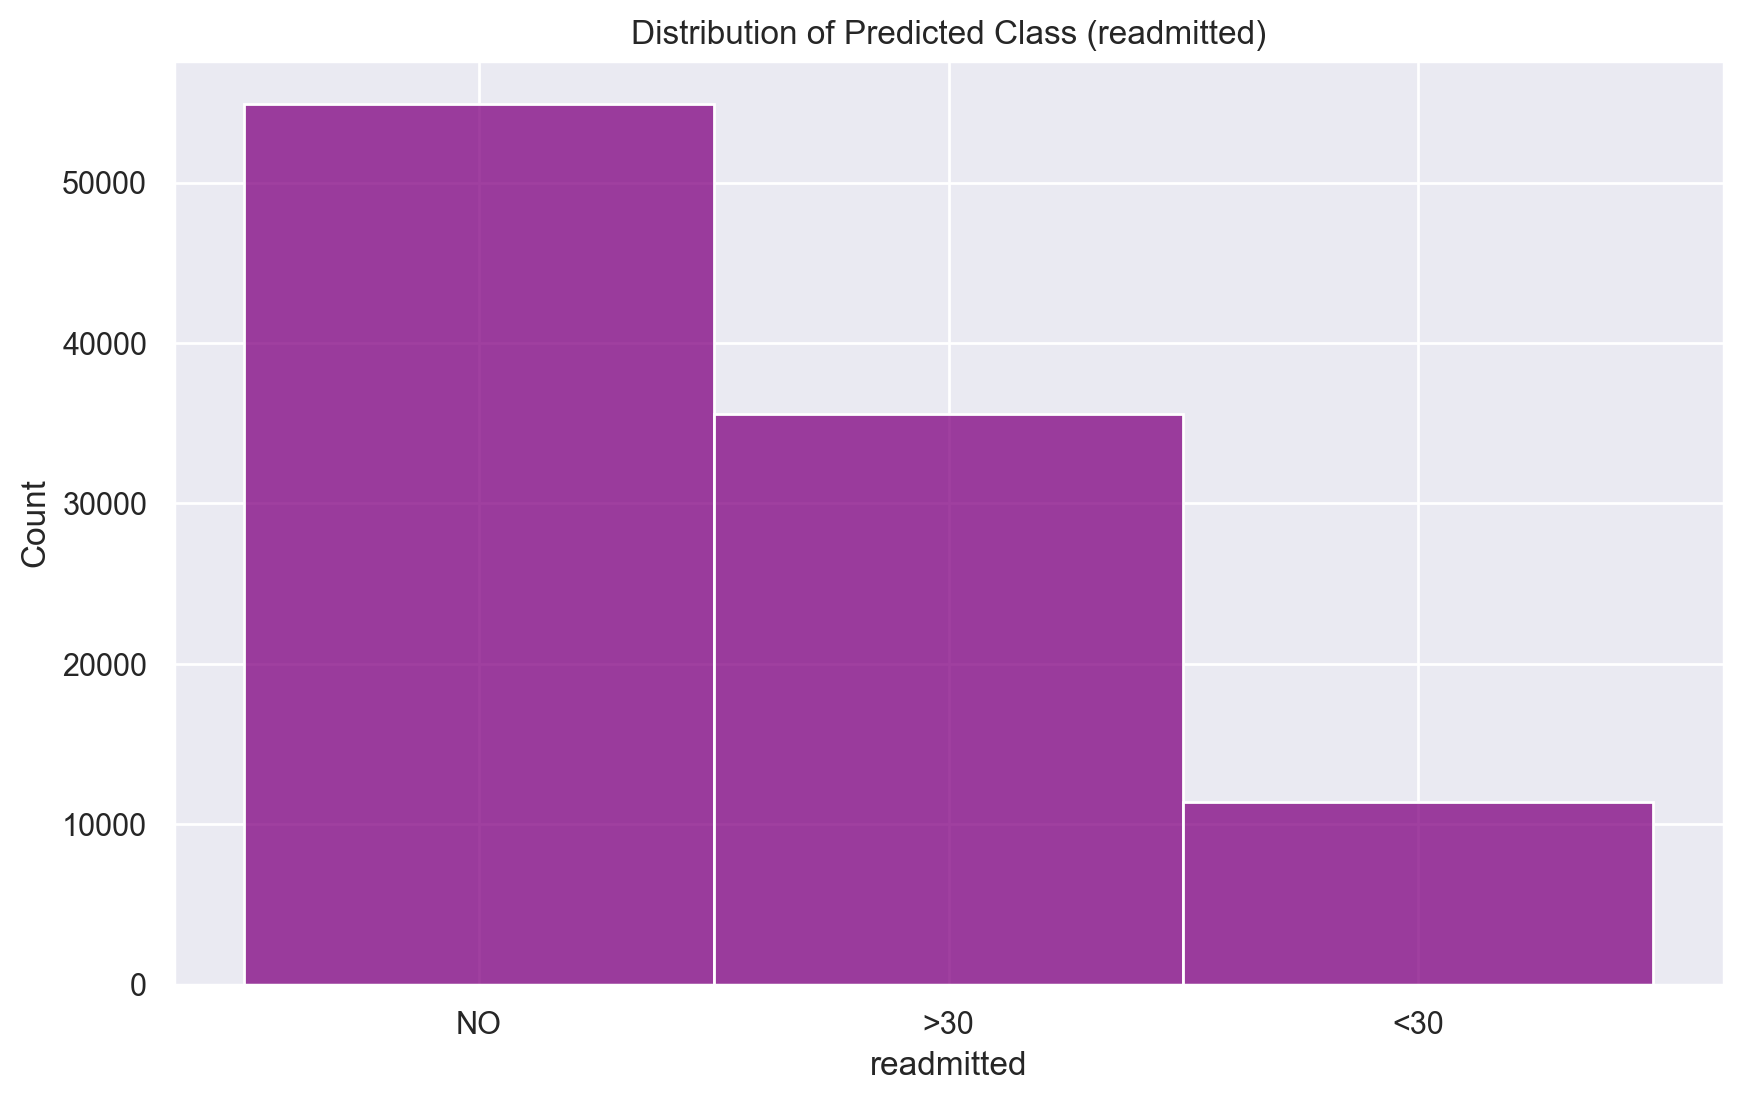

readmitted
0    54864
1    46902
Name: count, dtype: int64


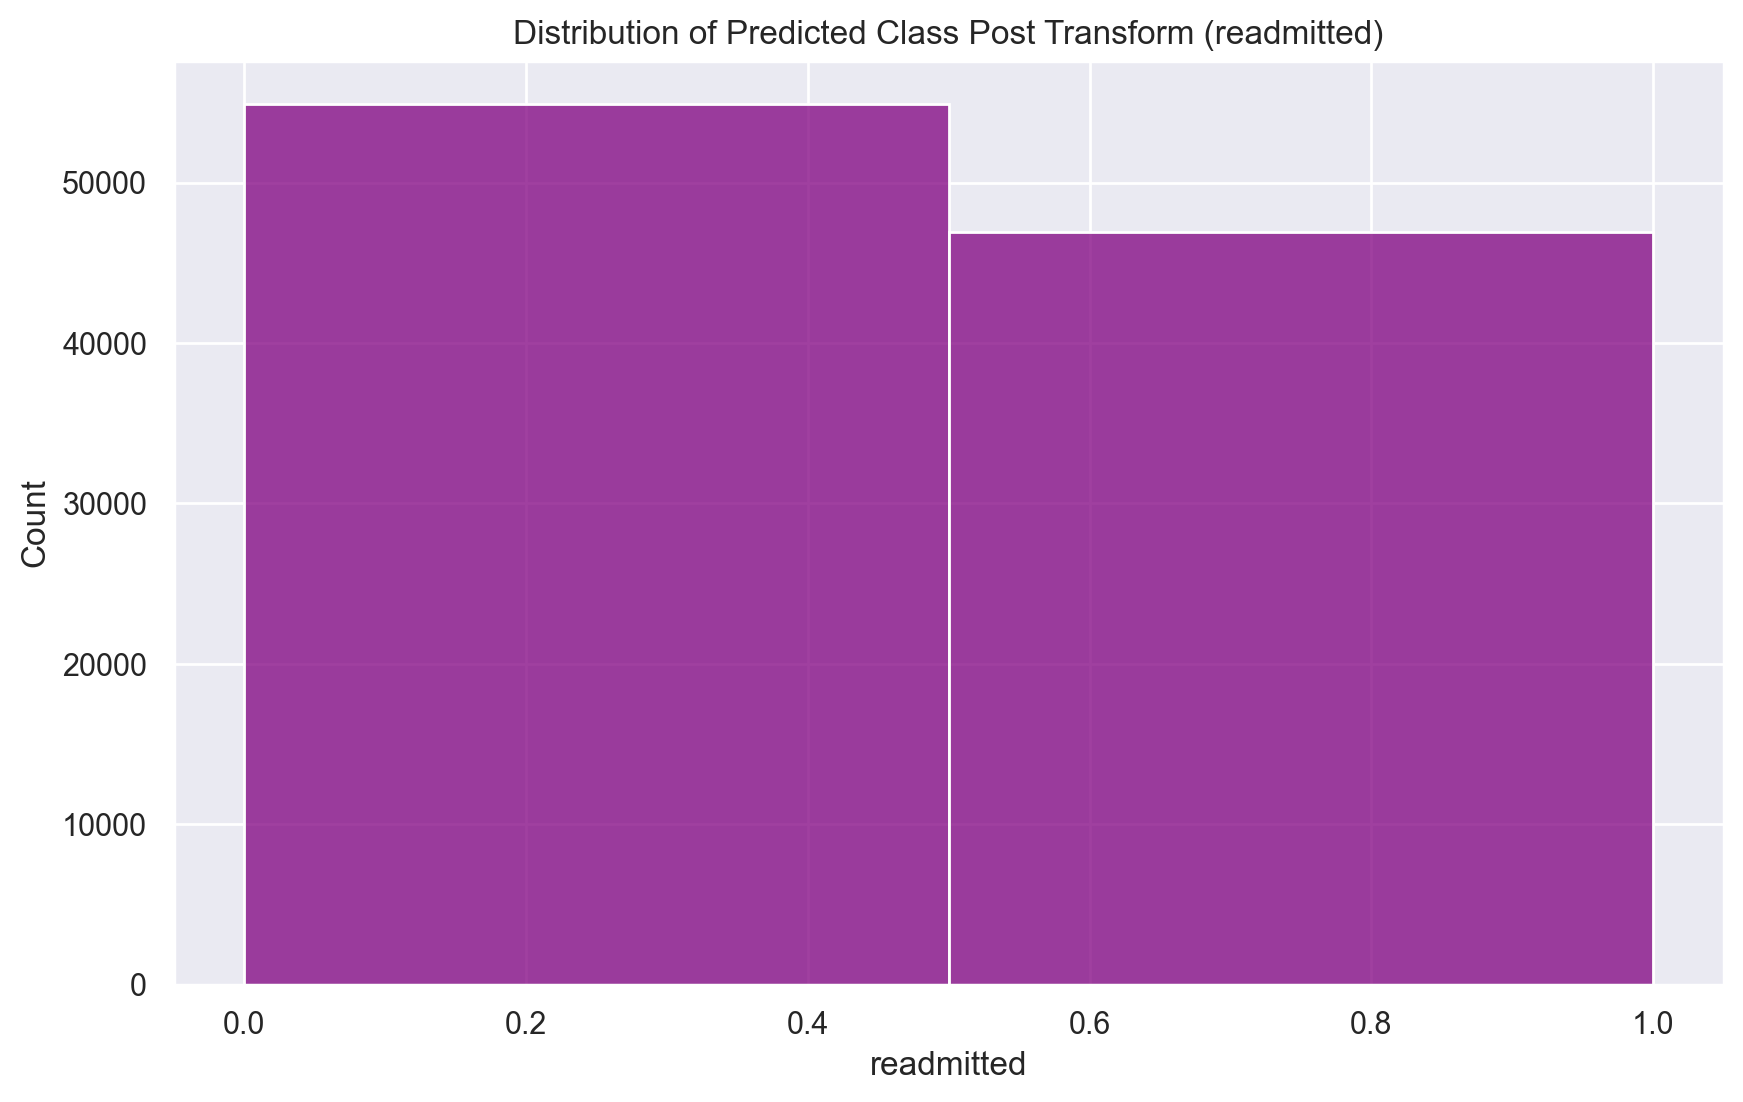

In [4]:
print(diabetes_df.readmitted.value_counts())
sns.histplot(diabetes_df['readmitted'], color='purple').set_title("Distribution of Predicted Class (readmitted)")
plt.show()

# diabetes_df['readmitted'] = diabetes_df.readmitted.apply(lambda x: 1 if x == '<30' else 0)
diabetes_df['readmitted'] = diabetes_df.readmitted.apply(lambda x: 1 if x in ['<30', '>30'] else 0)

print(diabetes_df.readmitted.value_counts())
sns.histplot(diabetes_df['readmitted'], color='purple', bins=2, fill=True).set_title("Distribution of Predicted Class Post Transform (readmitted)")
plt.show()


### Missing Values

C:\Users\Gugu\AppData\Local\Temp\ipykernel_114612\2637297158.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
C:\Users\Gugu\AppData\Local\Temp\ipykernel_114612\2637297158.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)


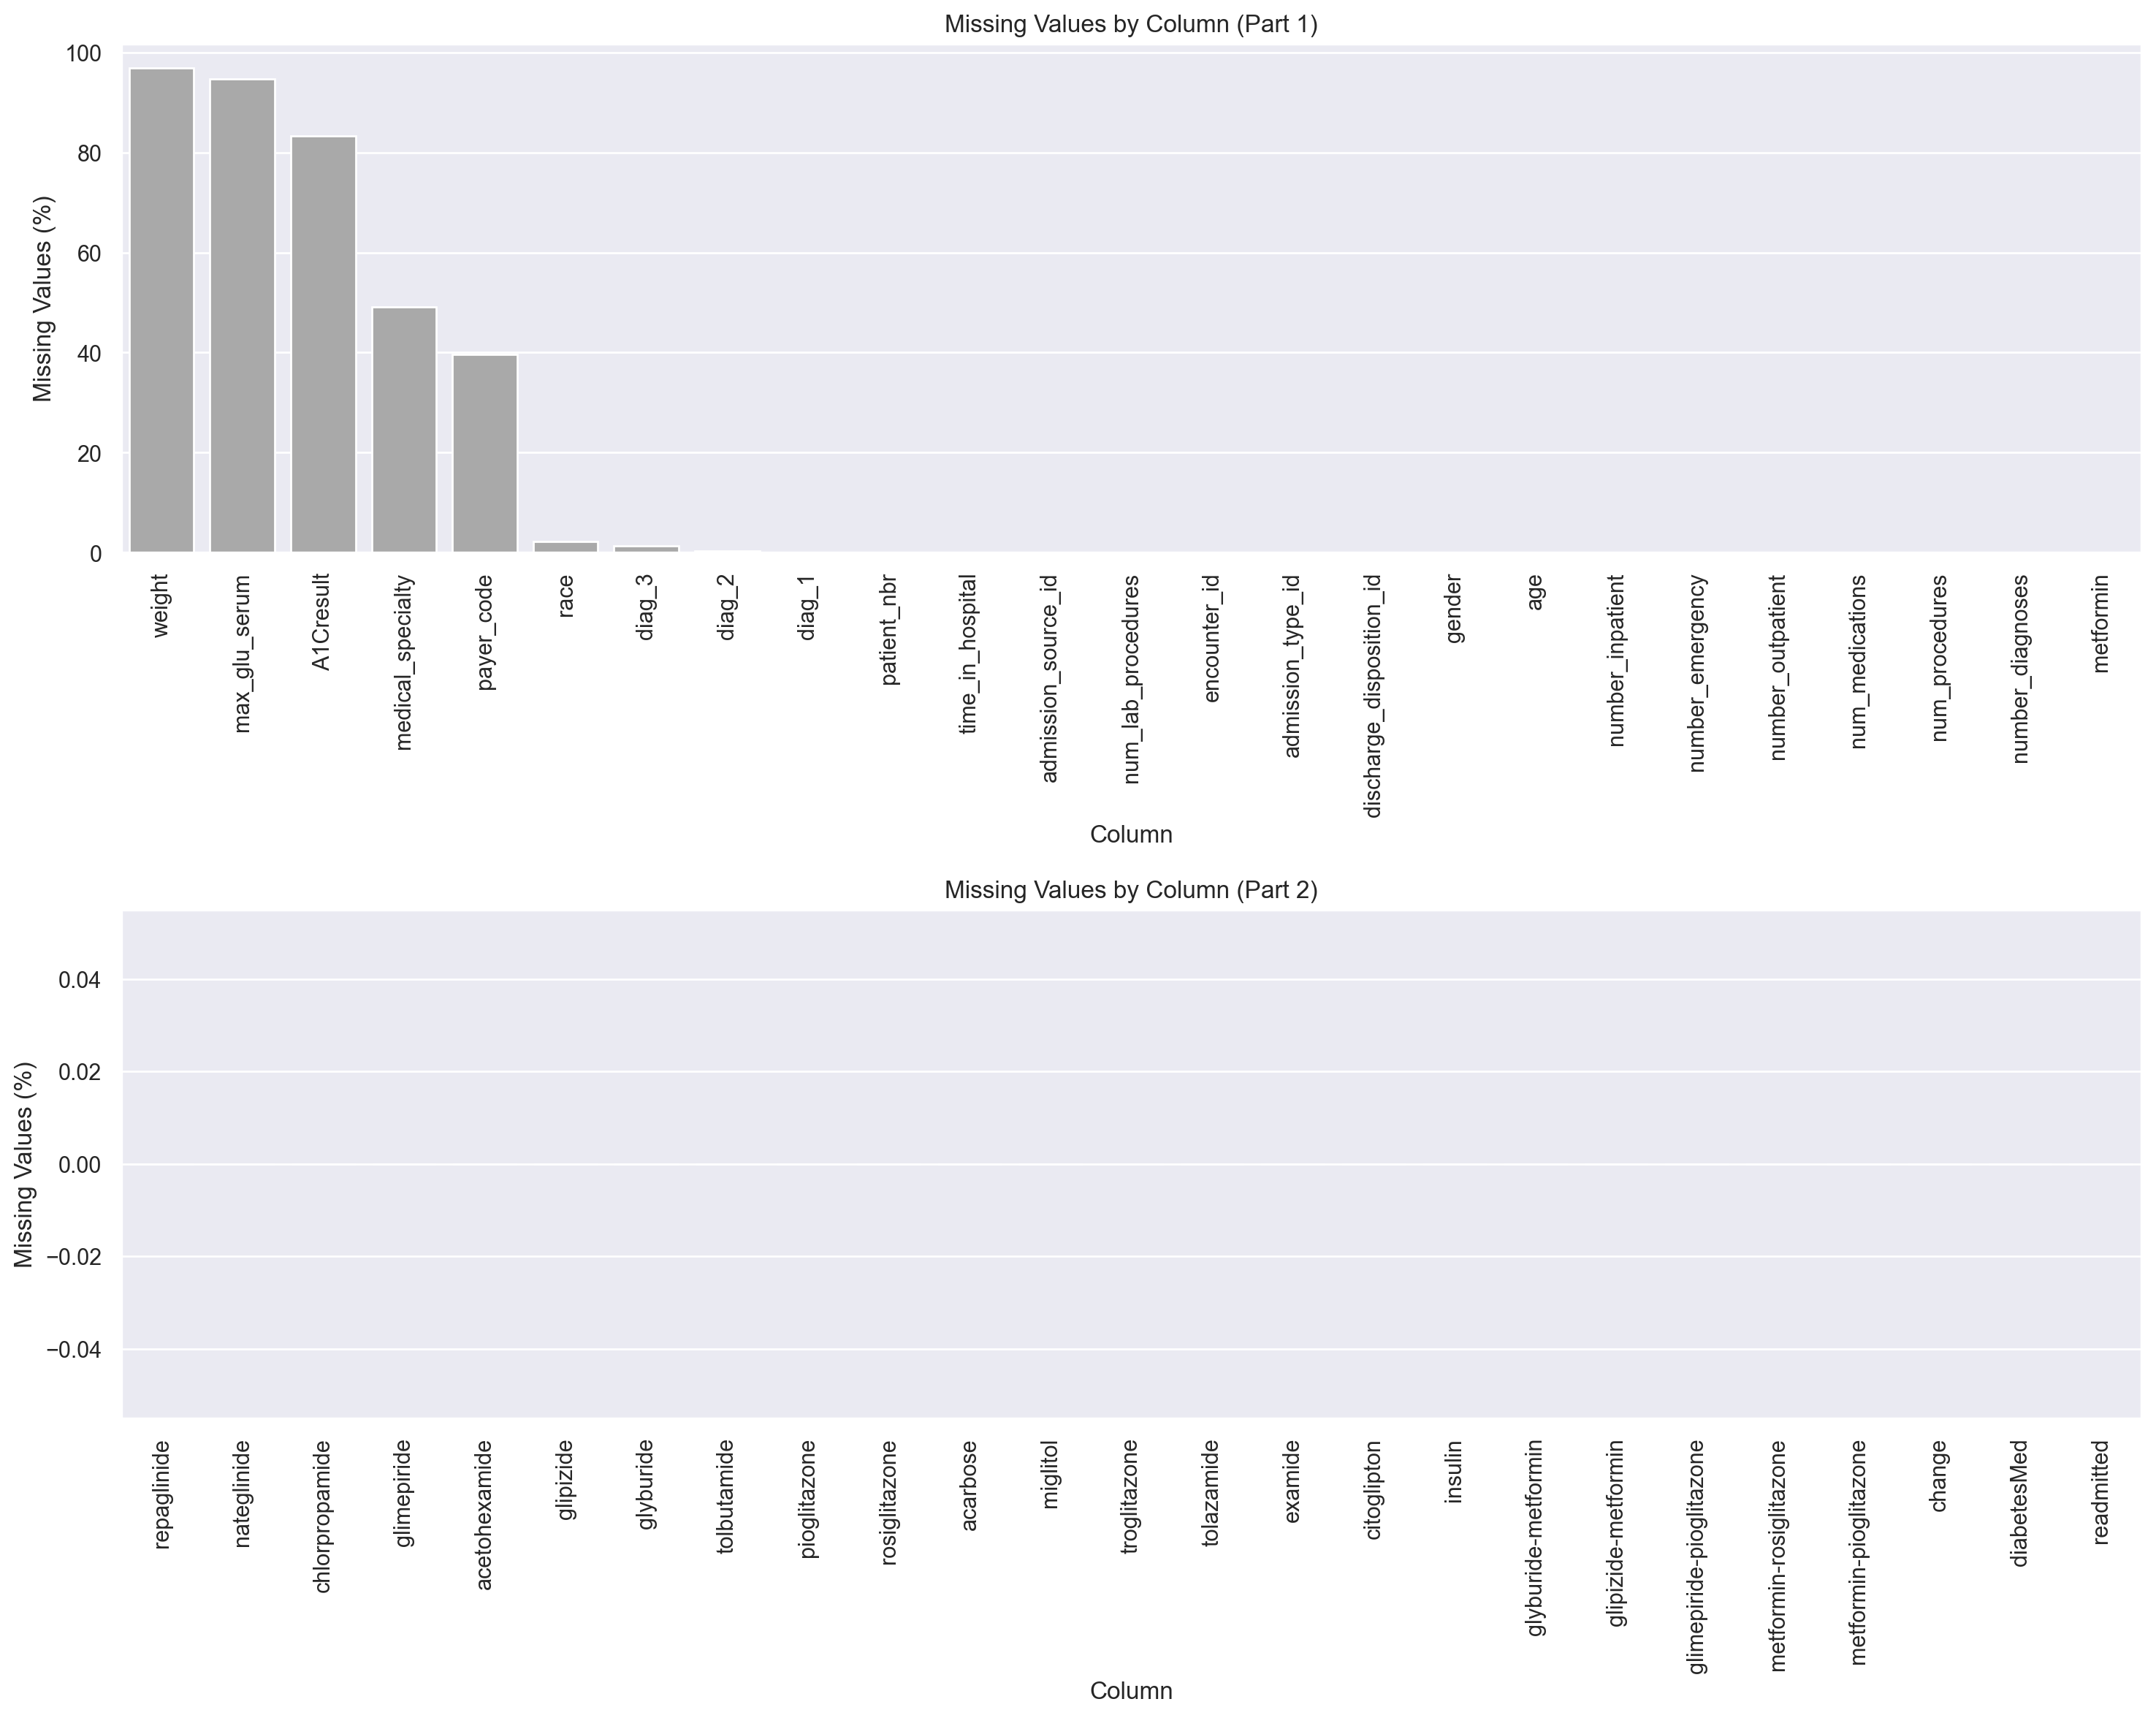

In [5]:

# Function to visualize missing values
def plot_missing_values(df):
    # Calculate missing values per column
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    
    # Create a DataFrame for plotting
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing Values': missing.values,
        'Percent': missing_percent.values
    })
    
    # Sort by missing values (descending)
    missing_df = missing_df.sort_values('Missing Values', ascending=False)
    
    # Divide columns into 2 groups for plotting
    n_columns = len(missing_df)
    half_point = n_columns // 2
    
    # Create figure with 2 subplots
    fig, axes = plt.subplots(2, 1, figsize=(15, 12))
    
    # First subplot - first half of columns
    sns.barplot(x='Column', y='Percent', data=missing_df.iloc[:half_point], ax=axes[0], color='darkgray')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
    axes[0].set_ylabel('Missing Values (%)')
    axes[0].set_title('Missing Values by Column (Part 1)')
    
    # Second subplot - second half of columns
    sns.barplot(x='Column', y='Percent', data=missing_df.iloc[half_point:], ax=axes[1], color='darkgray')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)
    axes[1].set_ylabel('Missing Values (%)')
    axes[1].set_title('Missing Values by Column (Part 2)')
    
    plt.tight_layout()
    plt.show()

# Call the function
plot_missing_values(diabetes_df)

In [6]:
def barplot_per_classes(df, attribute, groupby, title=None, ticks_rotation=0, topn=None, ax=None):
    """Draw barplot of attribute per class."""
    uniq_values = df[attribute].value_counts().head(topn).index
    df = df[df[attribute].isin(uniq_values)]
    data = df.groupby(groupby)[attribute].value_counts(normalize=True).rename('percentage').mul(100).reset_index()
    
    sns.barplot(x=attribute, y='percentage', hue=groupby, data=data, ax=ax, palette="Paired")
    
    if ax is None:
        plt.xticks(rotation=ticks_rotation)
        plt.title(title)
    # else:
        # # ax.set_xticklabels(ax.get_xticklabels(), rotation=ticks_rotation)
        # ax.
        # ax.set_title(title if title else f"{attribute} by {groupby}")


### Medications

The only medications worth keeping are insulin and perhaps metformin

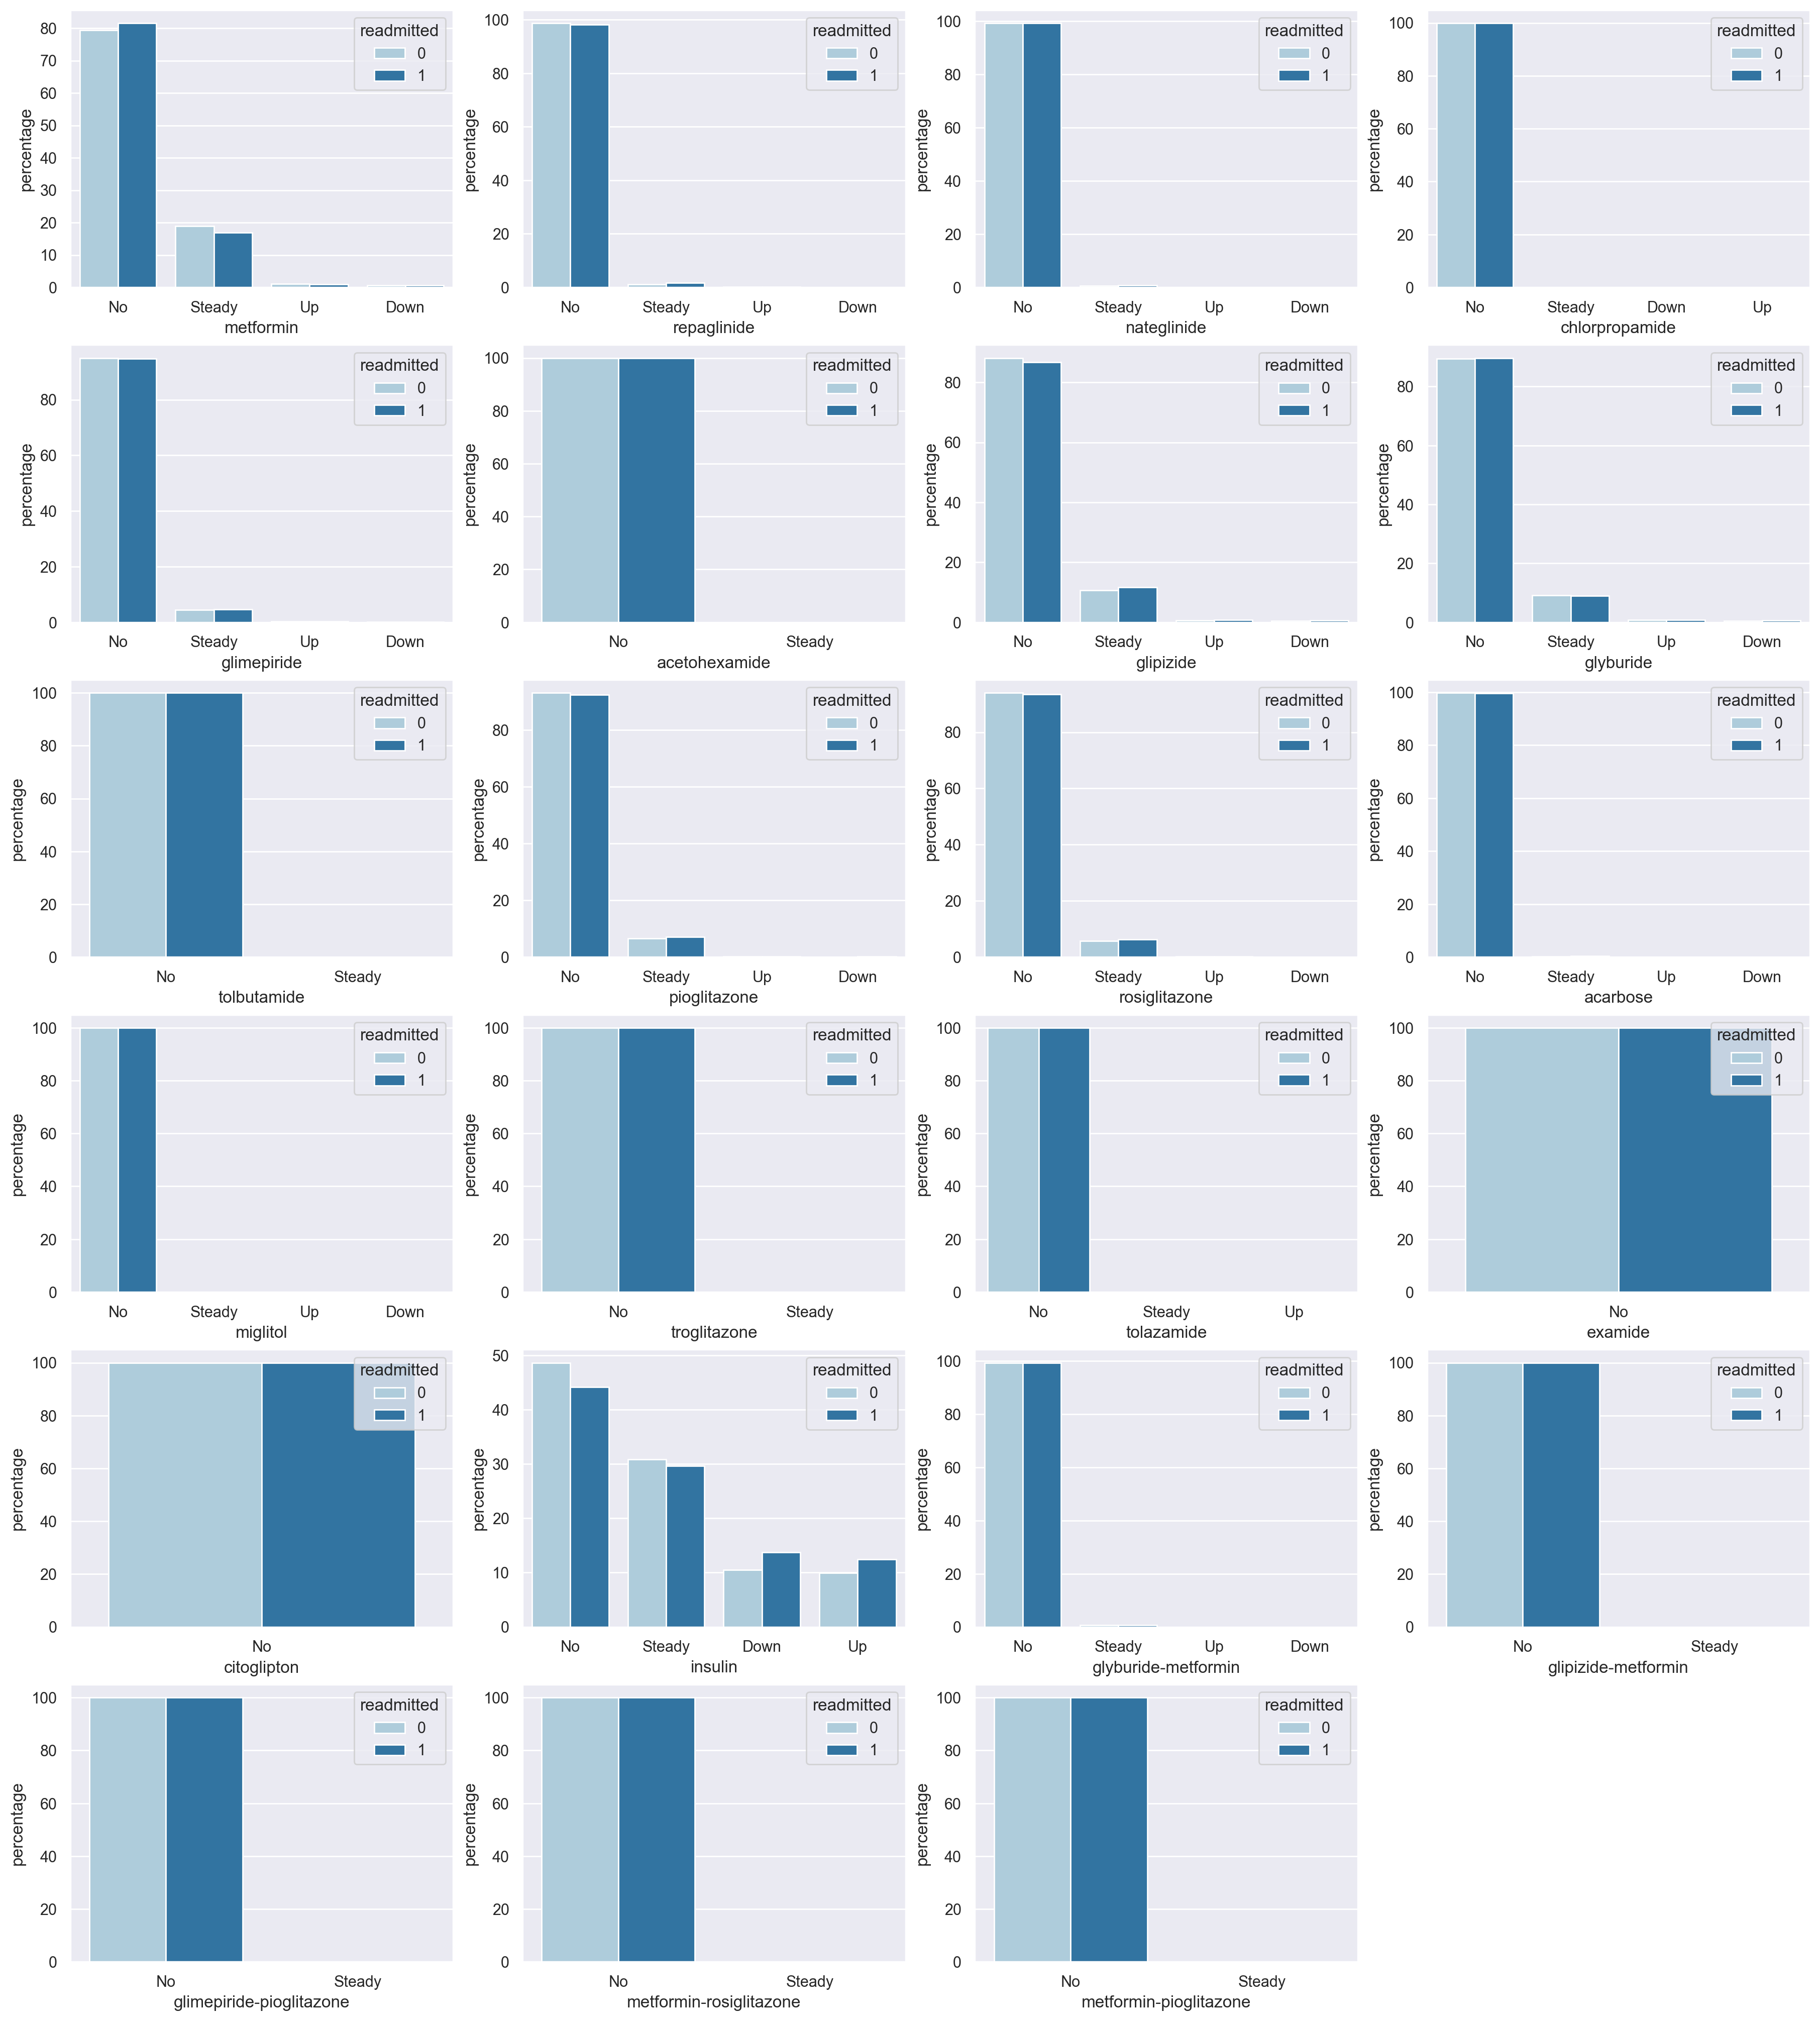

In [7]:
MEDICATION_COLS = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide','glimepiride', 
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin','glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

fig, axs = plt.subplots(nrows=6, ncols=4, constrained_layout=True)
fig.delaxes(axs[5,3])

fig.set_size_inches(18, 20)
for y in range(0,6):
    for x in range(0,4):
        if x + 4 * y == len(MEDICATION_COLS):
            break
        barplot_per_classes(diabetes_df, MEDICATION_COLS[x + 4 * y], 'readmitted', ax=axs[y][x])

### Diagnosis ICD-9 Codes

## 1.2 Dataset Challenges

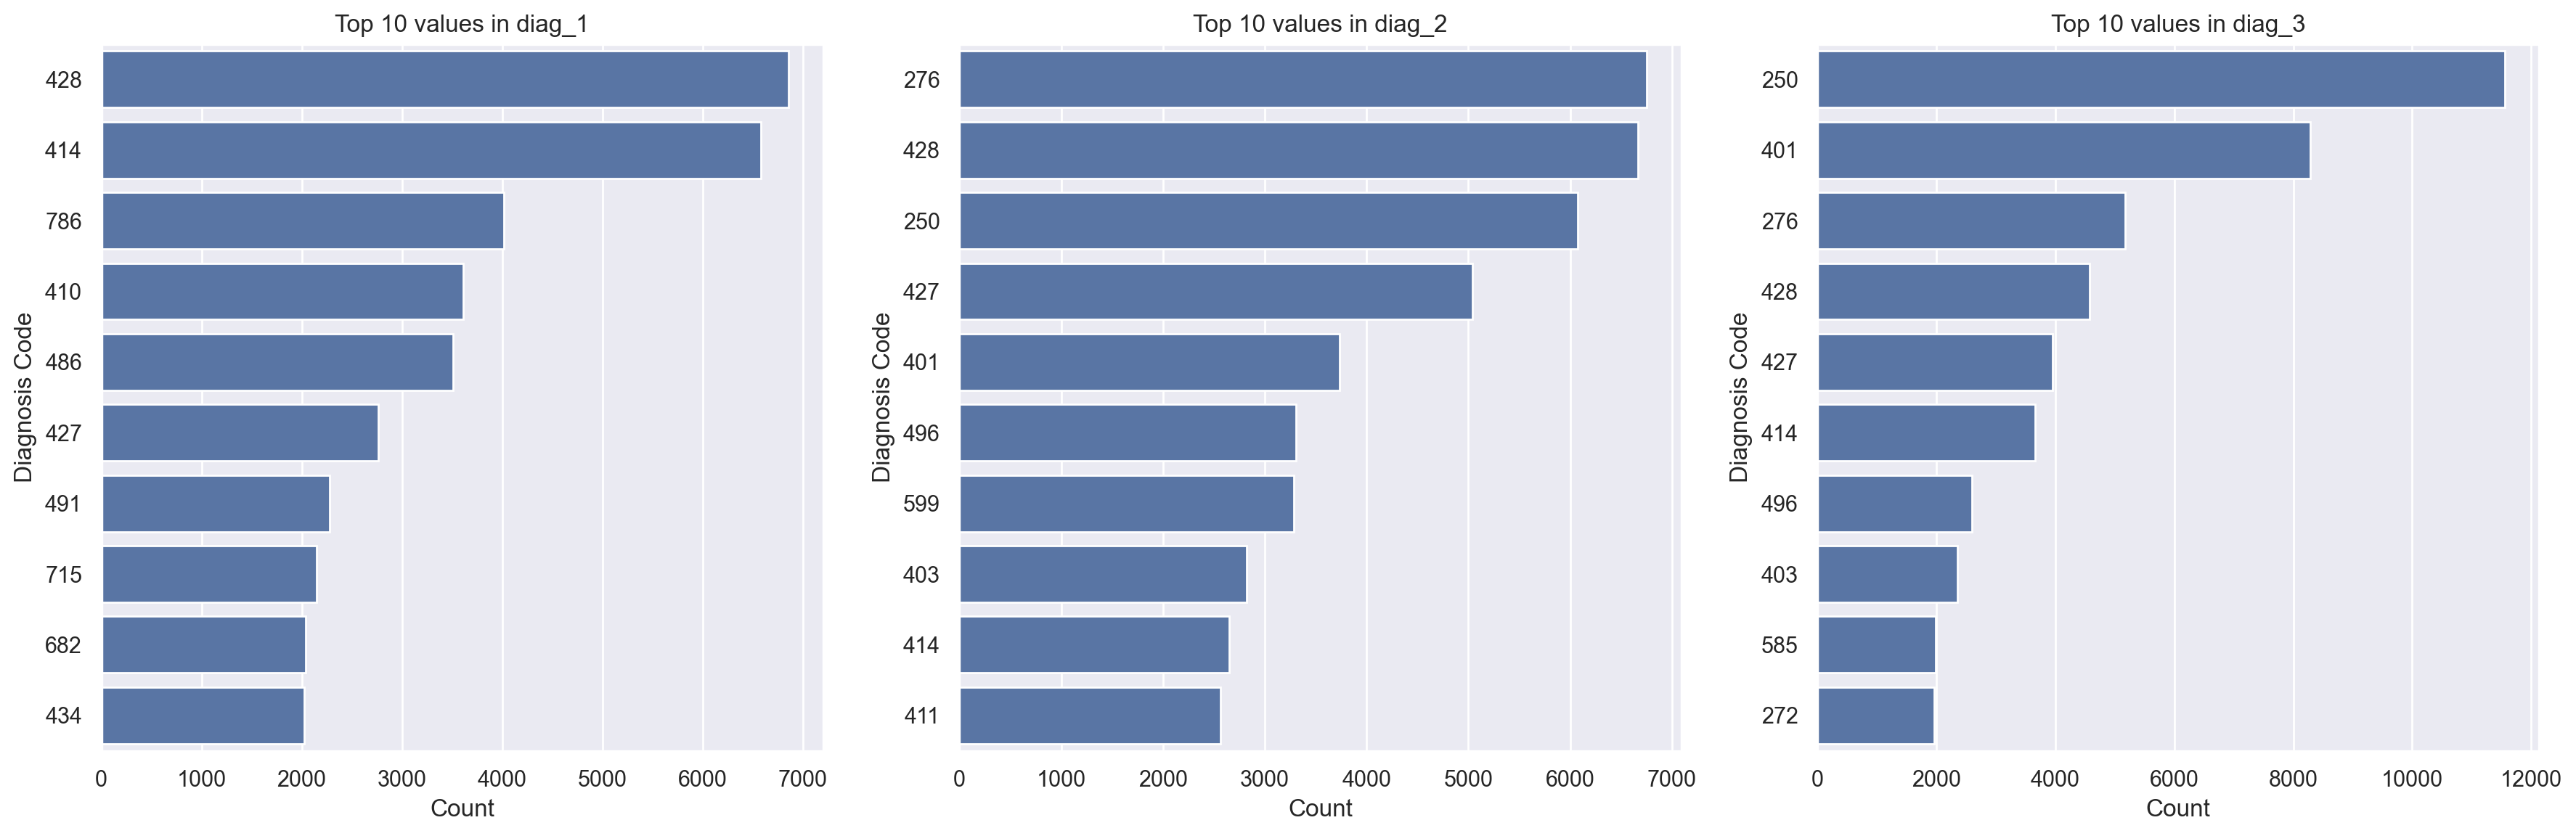

Number of unique values in diag_1: 716
Number of unique values in diag_2: 748
Number of unique values in diag_3: 789
Percentage of missing values ('?') in diag_1: 0.00%
Percentage of missing values ('?') in diag_2: 0.00%
Percentage of missing values ('?') in diag_3: 0.00%


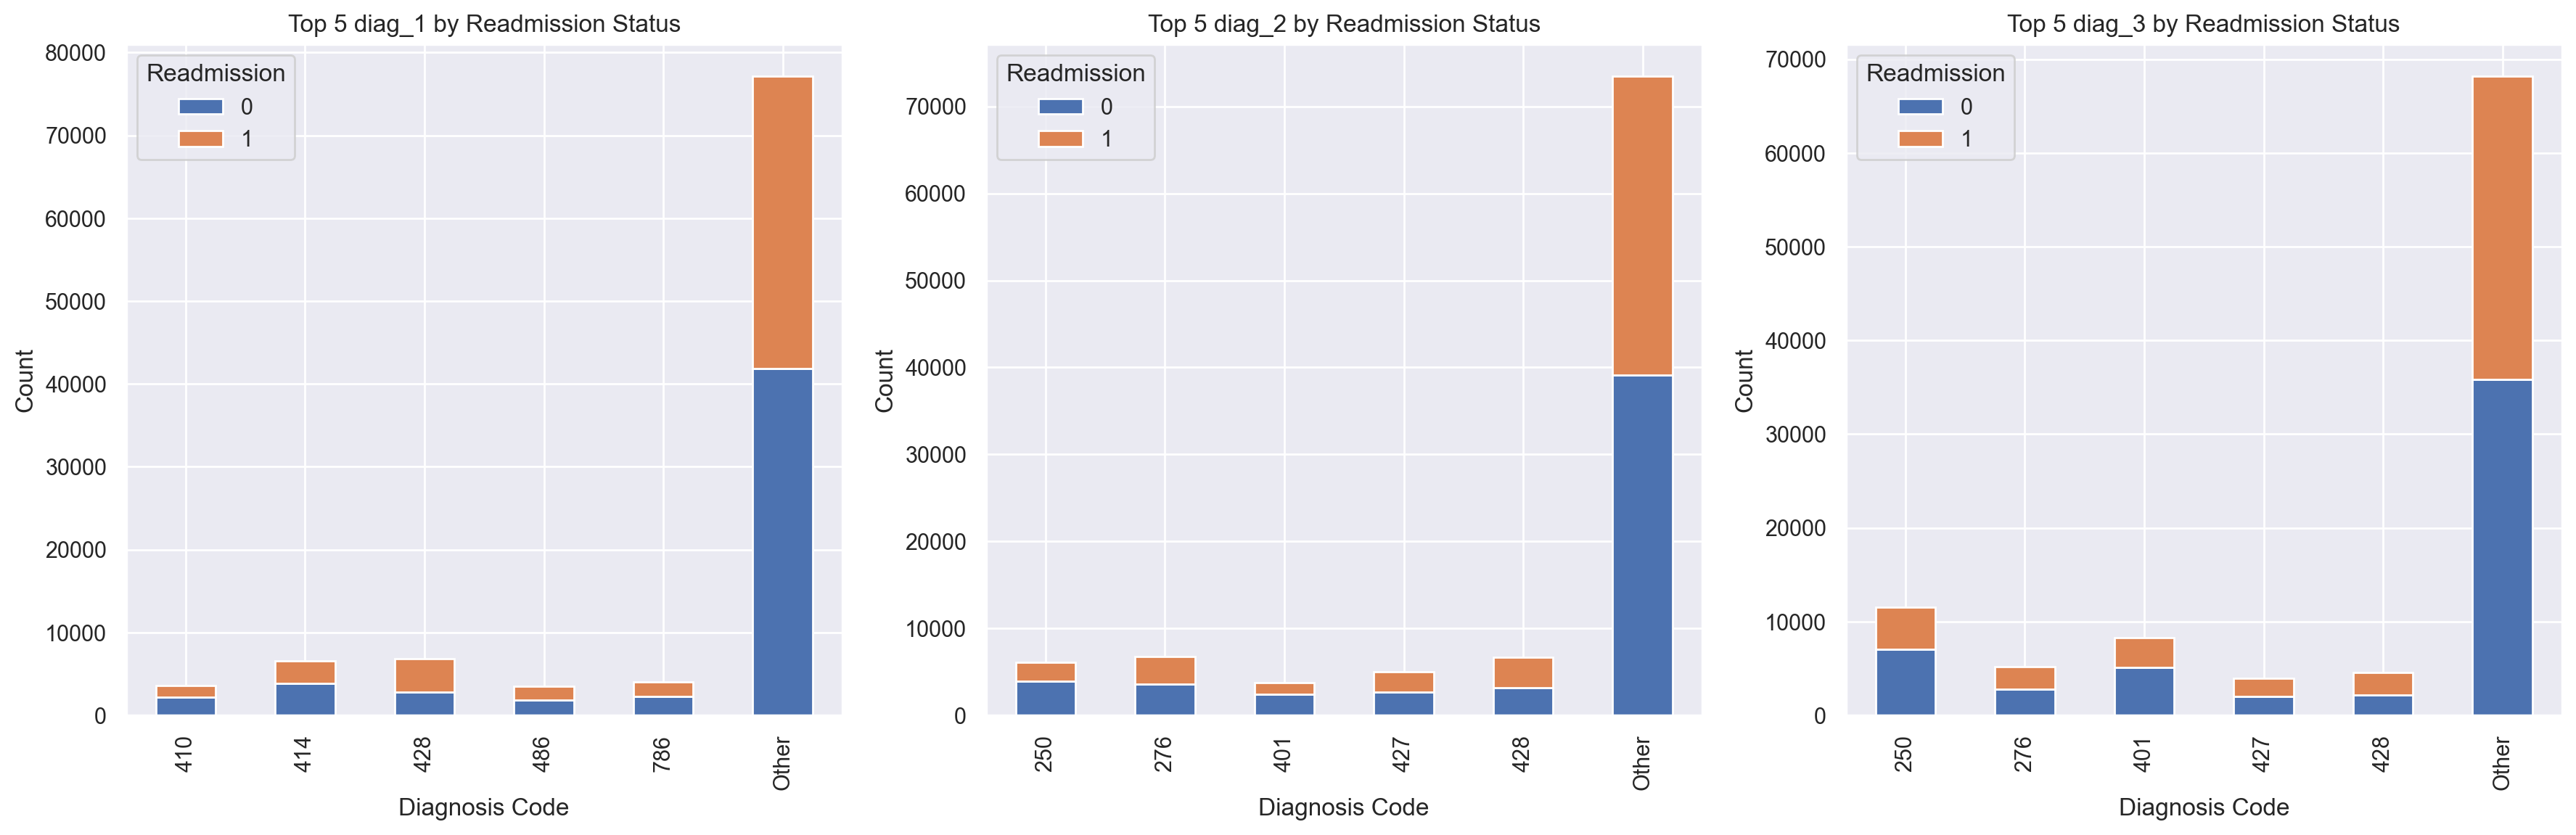

In [8]:

# Function to plot the top N diagnoses for a given column
def plot_top_diagnoses(df, column, n=10, ax=None):
    # Count frequency of each diagnosis code
    diag_counts = df[column].value_counts().reset_index()
    diag_counts.columns = [column, 'Count']
    
    # Get top N diagnoses (excluding '?' if present)
    if '?' in diag_counts[column].values:
        top_diags = diag_counts[diag_counts[column] != '?'].head(n)
        # Add the '?' count if it exists
        missing_count = diag_counts[diag_counts[column] == '?']
        if not missing_count.empty:
            top_diags = pd.concat([top_diags, missing_count])
    else:
        top_diags = diag_counts.head(n)
    
    # Plot
    sns.barplot(x='Count', y=column, data=top_diags, ax=ax)
    ax.set_title(f'Top {n} values in {column}')
    ax.set_xlabel('Count')
    ax.set_ylabel('Diagnosis Code')

# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot top diagnoses for each column
plot_top_diagnoses(diabetes_df, 'diag_1', n=10, ax=axes[0])
plot_top_diagnoses(diabetes_df, 'diag_2', n=10, ax=axes[1])
plot_top_diagnoses(diabetes_df, 'diag_3', n=10, ax=axes[2])

plt.tight_layout()
plt.show()

# Now let's see how many unique values exist in each diagnosis column
print(f"Number of unique values in diag_1: {diabetes_df['diag_1'].nunique()}")
print(f"Number of unique values in diag_2: {diabetes_df['diag_2'].nunique()}")
print(f"Number of unique values in diag_3: {diabetes_df['diag_3'].nunique()}")

# Let's also check the percentage of missing values ('?') in each column
missing_diag1 = (diabetes_df['diag_1'] == '?').mean() * 100
missing_diag2 = (diabetes_df['diag_2'] == '?').mean() * 100
missing_diag3 = (diabetes_df['diag_3'] == '?').mean() * 100

print(f"Percentage of missing values ('?') in diag_1: {missing_diag1:.2f}%")
print(f"Percentage of missing values ('?') in diag_2: {missing_diag2:.2f}%")
print(f"Percentage of missing values ('?') in diag_3: {missing_diag3:.2f}%")

# Let's create a visualization showing the distribution of diagnoses by readmission status
def plot_diag_by_readmission(df, column, top_n=5, ax=None):
    # Get top diagnoses (excluding '?')
    top_diags = df[df[column] != '?'][column].value_counts().head(top_n).index.tolist()
    
    # Create a subset with only top diagnoses and add 'Other' category for the rest
    subset = df.copy()
    subset[f'{column}_grouped'] = subset[column].apply(lambda x: x if x in top_diags else 'Other')
    
    # Count by diagnosis and readmission status
    cross_tab = pd.crosstab(subset[f'{column}_grouped'], subset['readmitted'])
    
    # Plot
    cross_tab.plot(kind='bar', stacked=True, ax=ax)
    ax.set_title(f'Top {top_n} {column} by Readmission Status')
    ax.set_xlabel('Diagnosis Code')
    ax.set_ylabel('Count')
    ax.legend(title='Readmission')

# Create a figure for readmission analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot diagnoses by readmission status
plot_diag_by_readmission(diabetes_df, 'diag_1', top_n=5, ax=axes[0])
plot_diag_by_readmission(diabetes_df, 'diag_2', top_n=5, ax=axes[1])
plot_diag_by_readmission(diabetes_df, 'diag_3', top_n=5, ax=axes[2])

plt.tight_layout()
plt.show()

   Column  Unique Values  Missing Values (?)  Missing Percentage
0  diag_1            716                   0                 0.0
1  diag_2            748                   0                 0.0
2  diag_3            789                   0                 0.0


C:\Users\Gugu\AppData\Local\Temp\ipykernel_114612\1827196768.py:132: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(title='Readmission Status')


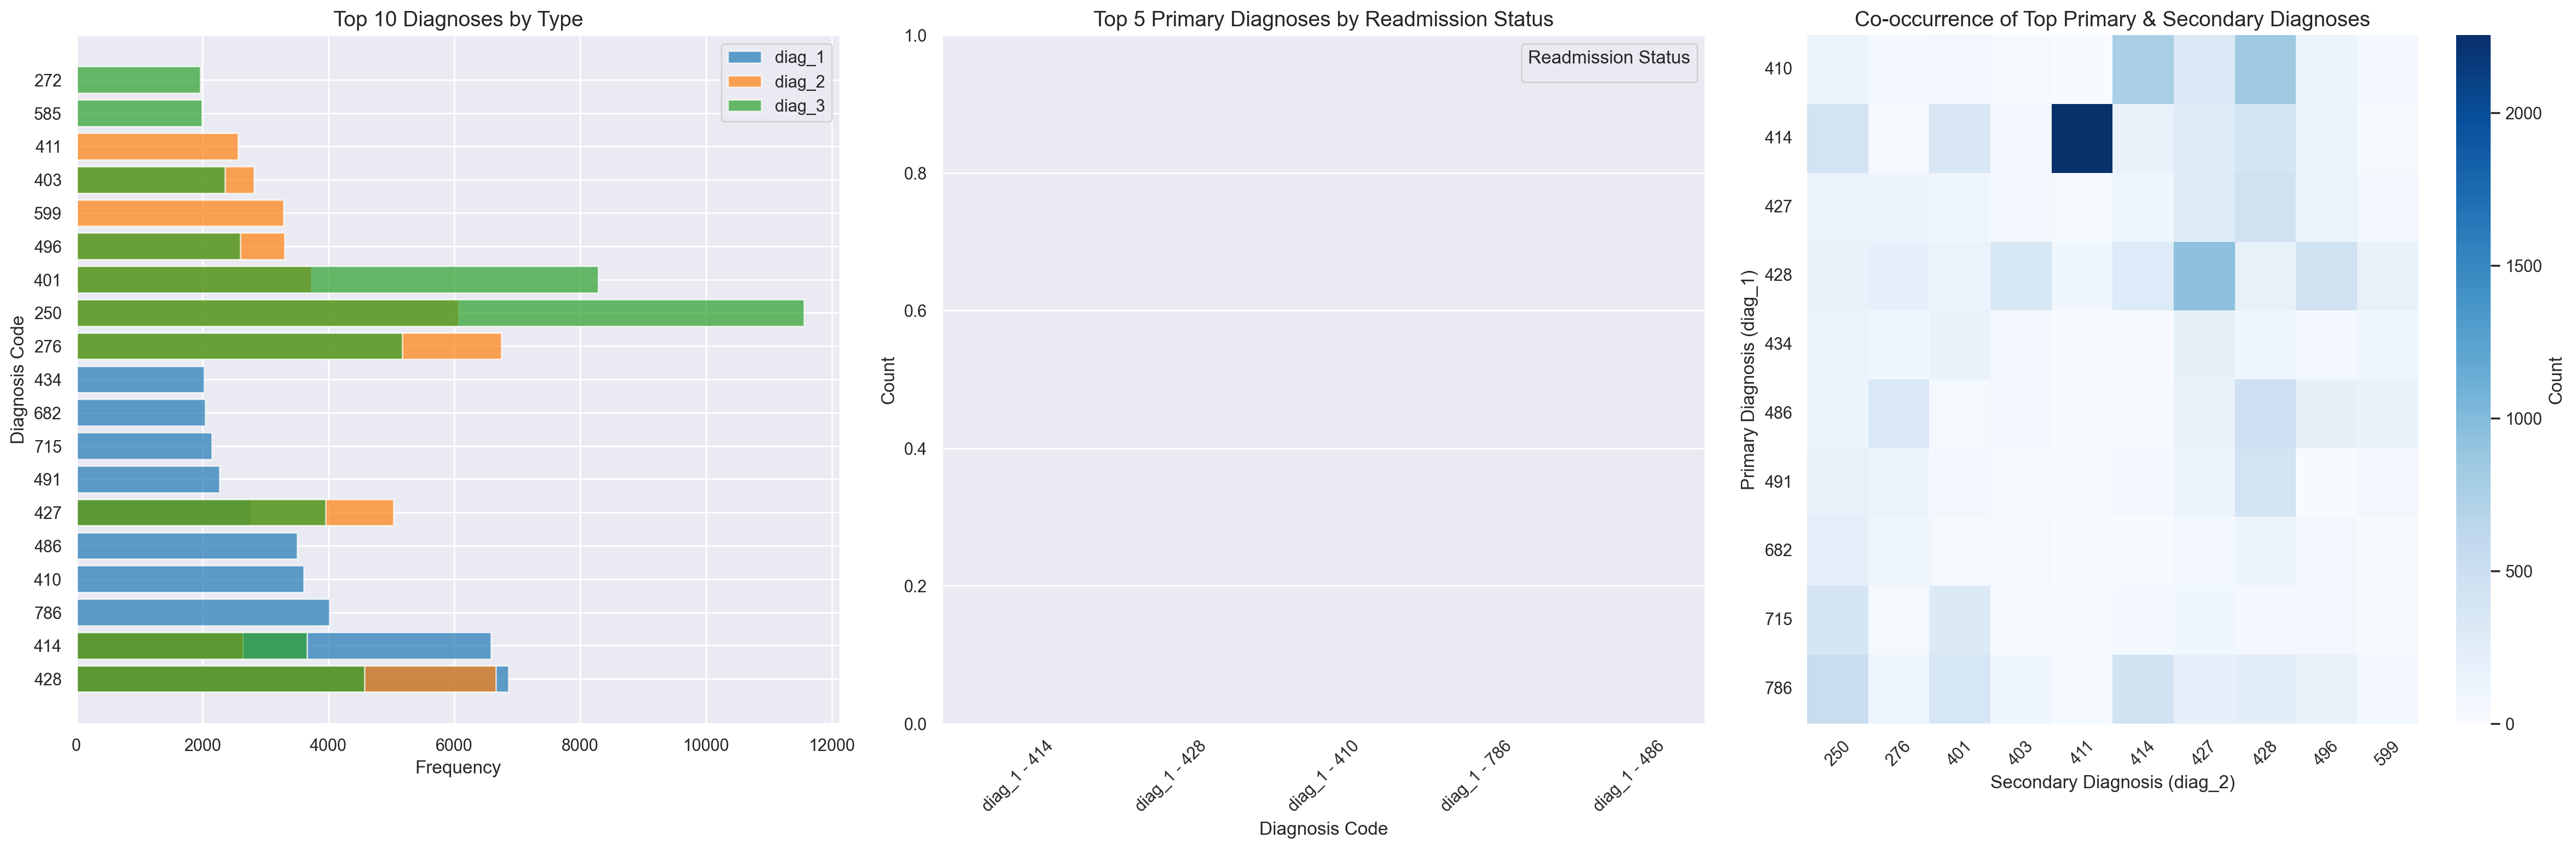

In [9]:
# Function to create a dataframe of top diagnoses
def get_top_diagnoses(df, column, n=10):
    # Count frequency of each diagnosis code
    diag_counts = df[column].value_counts().reset_index()
    diag_counts.columns = [column, 'Count']
    
    # Get top N diagnoses (excluding '?' if present)
    if '?' in diag_counts[column].values:
        top_diags = diag_counts[diag_counts[column] != '?'].head(n)
        # Add the '?' count if it exists
        missing_count = diag_counts[diag_counts[column] == '?']
        if not missing_count.empty:
            top_diags = pd.concat([top_diags, missing_count])
    else:
        top_diags = diag_counts.head(n)
    
    # Add a column to identify the diagnosis type
    top_diags = top_diags.copy()  # Create a copy to avoid SettingWithCopyWarning
    top_diags['diagnosis_type'] = column
    return top_diags

# Function to prepare diagnosis data by readmission status
def prepare_diag_readmission_data(df, column, top_n=5):
    # Get top diagnoses (excluding '?')
    top_diags = df[df[column] != '?'][column].value_counts().head(top_n).index.tolist()
    
    # Filter to only top diagnoses
    filtered_df = df[df[column].isin(top_diags)].copy()  # Create a copy to avoid warning
    
    # Add category column and readmit_status using .loc to avoid warning
    filtered_df.loc[:, 'category'] = f"{column} - " + filtered_df[column]
    filtered_df.loc[:, 'readmit_status'] = filtered_df['readmitted'].map({
        'NO': 'Not Readmitted',
        '<30': 'Readmitted <30 days',
        '>30': 'Readmitted >30 days'
    })
    filtered_df.loc[:, 'diagnosis_type'] = column
    
    return filtered_df

# Get top diagnoses for each column
top_diag1 = get_top_diagnoses(diabetes_df, 'diag_1')
top_diag2 = get_top_diagnoses(diabetes_df, 'diag_2')
top_diag3 = get_top_diagnoses(diabetes_df, 'diag_3')

# Combine into one dataframe for plotting
all_top_diags = pd.concat([top_diag1, top_diag2, top_diag3])

# Calculate unique counts and missing values for diagnoses
unique_counts = {
    'Column': ['diag_1', 'diag_2', 'diag_3'],
    'Unique Values': [
        diabetes_df['diag_1'].nunique(),
        diabetes_df['diag_2'].nunique(),
        diabetes_df['diag_3'].nunique()
    ],
    'Missing Values (?)': [
        (diabetes_df['diag_1'] == '?').sum(),
        (diabetes_df['diag_2'] == '?').sum(),
        (diabetes_df['diag_3'] == '?').sum()
    ],
    'Missing Percentage': [
        (diabetes_df['diag_1'] == '?').mean() * 100,
        (diabetes_df['diag_2'] == '?').mean() * 100,
        (diabetes_df['diag_3'] == '?').mean() * 100
    ]
}

unique_df = pd.DataFrame(unique_counts)
print(unique_df)

# Prepare data for all diagnosis columns for readmission analysis
diag1_readmit = prepare_diag_readmission_data(diabetes_df, 'diag_1')
diag2_readmit = prepare_diag_readmission_data(diabetes_df, 'diag_2')
diag3_readmit = prepare_diag_readmission_data(diabetes_df, 'diag_3')

# Combine data for readmission analysis
combined_readmit = pd.concat([diag1_readmit, diag2_readmit, diag3_readmit])

# Get top 10 diagnoses for co-occurrence analysis
top10_diag1 = diabetes_df[diabetes_df['diag_1'] != '?']['diag_1'].value_counts().head(10).index.tolist()
top10_diag2 = diabetes_df[diabetes_df['diag_2'] != '?']['diag_2'].value_counts().head(10).index.tolist()

# Create a cross-tabulation for diagnosis co-occurrence
cross_tab = pd.crosstab(
    diabetes_df[diabetes_df['diag_1'].isin(top10_diag1)]['diag_1'],
    diabetes_df[diabetes_df['diag_2'].isin(top10_diag2)]['diag_2']
)

# Fill NAs with 0
cross_tab = cross_tab.fillna(0)

# ----------------------
# Plotting Section Below
# ----------------------

# Create a figure with 3 subplots in one row
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Plot 1: Top 10 Diagnoses by Type
# Instead of barh, use sns.barplot with horizontal orientation
for diag_col, color in zip(['diag_1', 'diag_2', 'diag_3'], ['#1f77b4', '#ff7f0e', '#2ca02c']):
    subset = all_top_diags[all_top_diags['diagnosis_type'] == diag_col].sort_values('Count', ascending=False).head(10)
    # Use matplotlib's barh directly instead of seaborn
    axes[0].barh(
        y=subset[diag_col],
        width=subset['Count'],
        label=diag_col,
        color=color,
        alpha=0.7
    )

axes[0].set_title('Top 10 Diagnoses by Type', fontsize=14)
axes[0].set_xlabel('Frequency', fontsize=12)
axes[0].set_ylabel('Diagnosis Code', fontsize=12)
axes[0].legend()

# Plot 2: Top 5 Diagnoses by Readmission Status
# Use countplot for readmission status
subset_readmit = combined_readmit[combined_readmit['diagnosis_type'] == 'diag_1']  # Using only primary diagnoses for clarity
sns.countplot(
    x='category',
    hue='readmit_status',
    data=subset_readmit,
    ax=axes[1]
)

axes[1].set_title('Top 5 Primary Diagnoses by Readmission Status', fontsize=14)
axes[1].set_xlabel('Diagnosis Code', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Readmission Status')

# Plot 3: Co-occurrence of Top Diagnoses (Heatmap)
sns.heatmap(
    cross_tab,
    annot=False,
    cmap='Blues',
    ax=axes[2],
    cbar_kws={'label': 'Count'}
)

axes[2].set_title('Co-occurrence of Top Primary & Secondary Diagnoses', fontsize=14)
axes[2].set_xlabel('Secondary Diagnosis (diag_2)', fontsize=12)
axes[2].set_ylabel('Primary Diagnosis (diag_1)', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)
axes[2].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# 2. Data Pre-Processing

### 2.2 Data Cleaning

To keep things relatively simple, we first drop columns that we KNOW will provide no additional information. Then, a series of Dataframe mappings sets us up for One Hot Encoding by simplifying categorical labels, notable diagnosis.

In [10]:
diabetes_df['medical_specialty']

0         Pediatrics-Endocrinology
1                              NaN
2                              NaN
3                              NaN
4                              NaN
                    ...           
101761                         NaN
101762                         NaN
101763                         NaN
101764             Surgery-General
101765                         NaN
Name: medical_specialty, Length: 101766, dtype: object

In [11]:
### Data Cleaning Based on Alerts

# Drop constant columns and identifiers, and features with too many missing values
### Data Cleaning Based on Alerts

# Drop constant columns and identifiers, and features with too many missing values
# Updated cols_to_drop to match actual column names in dataset

from functools import reduce
import string

pp_df = diabetes_df.copy()

MISSING_VAL_OR_HIGH_CORR_COLS = ['weight', "max_glu_serum", "medical_specialty", "examide", 'citoglipton', 'encounter_id', "payer_code"] 
 
IMBALANCE_COLS = ["nateglinide", "chlorpropamide", "glimepiride", "pioglitazone", "rosiglitazone", 
                  "acarbose", "miglitol", "troglitazone", "tolazamide", "examide",
                  "citoglipton", "glyburide-metformin", "metformin-rosiglitazone", "metformin-pioglitazone"]

cols_to_drop = MISSING_VAL_OR_HIGH_CORR_COLS + IMBALANCE_COLS

# Make sure these column names exactly match the names in your dataset
existing_cols = diabetes_df.columns  # Get existing column names
cols_to_drop = [col for col in cols_to_drop if col in existing_cols]  # Keep only existing columns
print("\n COLS TO DROP: ", cols_to_drop )
pp_df.drop(columns=cols_to_drop, inplace=True)

print('Shape after dropping columns:', pp_df.shape)


def map_admission_type(admission_id):
    """Maps admission type IDs to simplified categories."""
    if pd.isna(admission_id):
        return np.nan
    elif admission_id in [2, 7]:
        return 1    # Emergency
    elif admission_id in [6, 8]:
        return 5    # Not Available
    else:
        return admission_id

def map_discharge(discharge_id):
    """Maps discharge disposition IDs to simplified categories."""
    if pd.isna(discharge_id):
        return np.nan
    elif discharge_id in [6, 8, 9, 13]:
        return 1    # Home
    elif discharge_id in [3, 4, 5, 14, 22, 23, 24]:
        return 2    # Other Facility
    elif discharge_id in [12, 15, 16, 17]:
        return 10   # Outpatient
    elif discharge_id in [25, 26]:
        return 18   # NULL/Unknown
    else:
        return discharge_id

def map_admission_source(source_id):
    """Maps admission source IDs to simplified categories."""
    if pd.isna(source_id):
        return np.nan
    elif source_id in [2, 3]:
        return 1    # Referral
    elif source_id in [5, 6, 10, 22, 25]:
        return 4    # Transfer
    elif source_id in [15, 17, 20, 21]:
        return 9    # Unknown
    elif source_id in [13, 14]:
        return 11   # Other
    else:
        return source_id

### Diagnosis Mapping

def diagnosis_mapping():
    """
    Create code to diagnosis mappings.
    """
    mapping = dict()
    mapping['circulatory'] = list(range(390, 460)) + [785]
    mapping['respiratory'] = list(range(460, 520)) + [786]
    mapping['digestive'] = list(range(520, 580)) + [787]
    mapping['diabetes'] = [250]
    mapping['injury'] = list(range(800, 1000))
    mapping['musculoskeletal'] = list(range(710, 740))
    mapping['genitourinary'] = list(range(580, 630)) + [788]
    mapping['neoplasm'] = list(range(140, 240))

    all_codes = reduce(lambda x, y: x + mapping[y], mapping.keys(), [])
    mapping['other'] = [x for x in range(1, 1000) if x not in all_codes]
    mapping['other'] = mapping['other'] + list(string.ascii_uppercase)

    # Convert all numbers to strings for comparison
    for key in mapping.keys():
        mapping[key] = [str(x) for x in mapping[key]]
    return mapping

def map_code_to_diagnose(code, mapping):
    """
    Map diagnosis code to diagnosis category.
    
    Parameters:
    -----------
    code : str
        Diagnosis code to map
    mapping : dict
        Dictionary with mappings from codes to diagnosis categories
        
    Returns:
    --------
    str
        Mapped diagnosis category
    """
    code = str(code)
    if not code or pd.isna(code) or code == '?':
        return None
        
    # Check for diabetes and other categories with string prefixes
    if any([code.startswith(x) for x in mapping['diabetes']]):
        return 'diabetes'
    elif any([code.startswith(x) for x in mapping['other']]):
        return 'other'
        
    # Check for exact matches in other categories
    for category, codes in mapping.items():
        if category not in ['diabetes', 'other']:
            if code in codes:
                return category
                
    # Default to 'other' if no match found
    return 'other'

def map_a1c_result(a1c):
    """Maps A1C result categories to match the target format."""
    if pd.isna(a1c):
        return 'None'
    elif a1c == '>8':
        return '>8'
    elif a1c == 'None':
        return 'None'
    else:
        # >7, Norm, etc. all map to 'other'
        return 'other'

def map_medication_status(status):
    """Maps medication status to binary values using a dictionary."""
    # Define the mapping dictionary
    status_mapping = {
        'No': "No",
        'Up': "Other",
        'Steady': "Other",
        'Down': "Other"
    }
    
    # Return the mapped value or the original if NaN
    if pd.isna(status):
        return status
    else:
        return status_mapping.get(status, status)  # Return the original value if not in mapping

def map_race(race):
    """Maps race categories to a simpler classification matching the target format."""
    if pd.isna(race):
        return np.nan
    elif race == 'AfricanAmerican':
        return 'AfricanAmerican'
    elif race == 'Caucasian':
        return 'Caucasian'
    else:
        # Asian, Hispanic, Other, etc. all map to 'other'
        return 'other'
  
pp_df['num_medication_change'] = 0
  
# For each medication column
for col in MEDICATION_COLS:
    if col in pp_df.columns:
        # Create a temporary column marking changes (1 for Up/Down, 0 for No/Steady)
        pp_df[f"{col}_temp"] = pp_df[col].apply(lambda x: 0 if (x == 'No' or x == 'Steady' or x == 'Other') else 1)
        
        # Add to the count of changes
        pp_df['num_medication_change'] += pp_df[f"{col}_temp"]
        
        # Drop the temporary column
        pp_df.drop(columns=f"{col}_temp", inplace=True)
  
# Apply diagnosis mapping
mapping = diagnosis_mapping()
pp_df['diag_1_category'] = pp_df['diag_1'].apply(lambda x: map_code_to_diagnose(x, mapping))
pp_df['diag_2_category'] = pp_df['diag_2'].apply(lambda x: map_code_to_diagnose(x, mapping))
pp_df['diag_3_category'] = pp_df['diag_3'].apply(lambda x: map_code_to_diagnose(x, mapping))

for col in MEDICATION_COLS:
    if col in pp_df.columns:
        pp_df[col] = pp_df[col].apply(map_medication_status)
        
pp_df['race'] = pp_df['race'].apply(map_race)
pp_df['A1Cresult'] = pp_df['A1Cresult'].apply(map_a1c_result)


pp_df['admission_type_id'] = pp_df['admission_type_id'].apply(map_admission_type)
pp_df['discharge_disposition_id'] = pp_df['discharge_disposition_id'].apply(map_discharge)
pp_df['admission_source_id'] = pp_df['admission_source_id'].apply(map_admission_source)

# Drop original diagnosis columns
pp_df.drop(columns=['diag_1', 'diag_2', 'diag_3'], inplace=True)

# Check for duplicate rows
duplicate_rows = pp_df[pp_df.duplicated()]

# Print the number of duplicate rows
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")


# Drop duplicate rows (if desired)
pp_df.drop_duplicates(inplace=True)

# Print the shape of the DataFrame after dropping duplicates
print(f"\nShape after dropping duplicates: {pp_df.shape}")

print('Shape after diagnosis mapping:', pp_df.shape)

cols_to_check = ['race', 'gender', 'admission_type_id', 'discharge_disposition_id', 'time_in_hospital', 'admission_source_id']
for col in cols_to_check:
    pp_df = pp_df[pp_df[col] != '?']  # Assuming '?' represents unknown values

# Reset index after dropping rows (optional)
pp_df.reset_index(drop=True, inplace=True) 

# Get null IDs for each column based on mapped values
null_admission_type_ids = [5]  # Since 6,8 map to 5 
null_discharge_disposition_ids = [18]  # Since 25,26 map to 18
null_admission_source_ids = [9]  # Since 15,17,20,21 map to 9

pp_df = pp_df.drop_duplicates(subset=['patient_nbr'], keep = 'first')
pp_df.drop(columns=['patient_nbr'], inplace=True)
# Remove rows from df corresponding to null IDs
pp_df = pp_df[~pp_df['admission_type_id'].isin(null_admission_type_ids)]
pp_df = pp_df[~pp_df['discharge_disposition_id'].isin(null_discharge_disposition_ids)]
pp_df = pp_df[~pp_df['admission_source_id'].isin(null_admission_source_ids)]
pp_df['visits_sum'] = pp_df['number_outpatient'] + pp_df['number_emergency'] + pp_df['number_inpatient']

# Reset index after dropping rows (optional)
pp_df.reset_index(drop=True, inplace=True)

print('Shape after dropping missing value rows', {pp_df.shape})

print('UnCleaned Shape', {diabetes_df.shape})
print('Final Cleaned Shape', {pp_df.shape})

pp_df.head()


 COLS TO DROP:  ['weight', 'max_glu_serum', 'medical_specialty', 'examide', 'citoglipton', 'encounter_id', 'payer_code', 'nateglinide', 'chlorpropamide', 'glimepiride', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'metformin-rosiglitazone', 'metformin-pioglitazone']
Shape after dropping columns: (101766, 31)
Number of duplicate rows: 0

Shape after dropping duplicates: (101766, 32)
Shape after diagnosis mapping: (101766, 32)
Shape after dropping missing value rows {(60170, 32)}
UnCleaned Shape {(101766, 50)}
Final Cleaned Shape {(60170, 32)}


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,A1Cresult,metformin,repaglinide,acetohexamide,glipizide,glyburide,tolbutamide,insulin,glipizide-metformin,glimepiride-pioglitazone,change,diabetesMed,readmitted,num_medication_change,diag_1_category,diag_2_category,diag_3_category,visits_sum
0,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,9,None,No,No,No,No,No,No,Other,No,No,Ch,Yes,1,1,other,diabetes,other,0
1,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,6,None,No,No,No,Other,No,No,No,No,No,No,Yes,0,0,other,diabetes,other,3
2,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,7,None,No,No,No,No,No,No,Other,No,No,Ch,Yes,0,1,other,diabetes,other,0
3,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,5,None,No,No,No,Other,No,No,Other,No,No,Ch,Yes,0,0,other,other,diabetes,0
4,Caucasian,Male,[50-60),1,1,1,3,31,6,16,0,0,0,9,None,No,No,No,No,No,No,Other,No,No,No,Yes,1,0,other,other,diabetes,0


In [12]:
# pp_profile = ProfileReport(pp_df, title="Profiling Report after Data Cleaning")
# pp_profile.to_notebook_iframe()

### Encoding Categorical Variables

In [13]:
from sklearn.preprocessing import OneHotEncoder

def encode_categorical_features(df):
    """
    Encode categorical features in the dataframe.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with mixed categorical and numerical features
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with encoded categorical features
    """
    encoded_df = df.copy()
    
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    print(f"Categorical columns to encode: {categorical_cols}")
    
    age_mapping = {
        '[0-10)': 5,
        '[10-20)': 15,
        '[20-30)': 25,
        '[30-40)': 35,
        '[40-50)': 45,
        '[50-60)': 55,
        '[60-70)': 65,
        '[70-80)': 75,
        '[80-90)': 85,
        '[90-100)': 95
    }
    
    
    encoded_df['age'] = encoded_df['age'].map(age_mapping)
    categorical_cols.remove('age')


    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore' ) #, drop='first'
    
    encoded_array = encoder.fit_transform(encoded_df[categorical_cols])
    
    feature_names = encoder.get_feature_names_out(categorical_cols)
    
    
    encoded_categories = pd.DataFrame(
        encoded_array, 
        columns=feature_names,
        index=encoded_df.index
    )
    
    encoded_df = encoded_df.drop(categorical_cols, axis=1)
    encoded_df = pd.concat([encoded_df, encoded_categories], axis=1)    
    
    return encoded_df

encoded_diabetes_df = encode_categorical_features(pp_df)
print(encoded_diabetes_df.columns)

print(f"Shape after encoding: {encoded_diabetes_df.shape}")
encoded_diabetes_df.head()


Categorical columns to encode: ['race', 'gender', 'age', 'A1Cresult', 'metformin', 'repaglinide', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'insulin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'change', 'diabetesMed', 'diag_1_category', 'diag_2_category', 'diag_3_category']
Index(['age', 'admission_type_id', 'discharge_disposition_id',
       'admission_source_id', 'time_in_hospital', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'number_diagnoses',
       'readmitted', 'num_medication_change', 'visits_sum',
       'race_AfricanAmerican', 'race_Caucasian', 'race_other', 'race_nan',
       'gender_Female', 'gender_Male', 'gender_Unknown/Invalid',
       'A1Cresult_>8', 'A1Cresult_None', 'A1Cresult_other', 'metformin_No',
       'metformin_Other', 'repaglinide_No', 'repaglinide_Other',
       'acetohexamide_No', 'acetohexamide_Other', 'glipizide_No',
       'glipizide_Other', 

,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted,num_medication_change,visits_sum,race_AfricanAmerican,race_Caucasian,race_other,race_nan,gender_Female,gender_Male,gender_Unknown/Invalid,A1Cresult_>8,A1Cresult_None,A1Cresult_other,metformin_No,metformin_Other,repaglinide_No,repaglinide_Other,acetohexamide_No,acetohexamide_Other,glipizide_No,glipizide_Other,glyburide_No,glyburide_Other,tolbutamide_No,tolbutamide_Other,insulin_No,insulin_Other,glipizide-metformin_No,glipizide-metformin_Other,glimepiride-pioglitazone_No,change_Ch,change_No,diabetesMed_No,diabetesMed_Yes,diag_1_category_diabetes,diag_1_category_other,diag_2_category_diabetes,diag_2_category_other,diag_3_category_diabetes,diag_3_category_other
0,15,1,1,7,3,59,0,18,0,0,0,9,1,1,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
1,25,1,1,7,2,11,5,13,2,0,1,6,0,0,3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
2,35,1,1,7,2,44,1,16,0,0,0,7,0,1,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
3,45,1,1,7,1,51,0,8,0,0,0,5,0,0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
4,55,1,1,1,3,31,6,16,0,0,0,9,1,0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0


In [14]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split

X = encoded_diabetes_df.drop('readmitted', axis=1)
y = encoded_diabetes_df['readmitted']
# test splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, random_state=42, stratify=y
)
X_train

,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,num_medication_change,visits_sum,race_AfricanAmerican,race_Caucasian,race_other,race_nan,gender_Female,gender_Male,gender_Unknown/Invalid,A1Cresult_>8,A1Cresult_None,A1Cresult_other,metformin_No,metformin_Other,repaglinide_No,repaglinide_Other,acetohexamide_No,acetohexamide_Other,glipizide_No,glipizide_Other,glyburide_No,glyburide_Other,tolbutamide_No,tolbutamide_Other,insulin_No,insulin_Other,glipizide-metformin_No,glipizide-metformin_Other,glimepiride-pioglitazone_No,change_Ch,change_No,diabetesMed_No,diabetesMed_Yes,diag_1_category_diabetes,diag_1_category_other,diag_2_category_diabetes,diag_2_category_other,diag_3_category_diabetes,diag_3_category_other
39706,75,1,2,7,5,51,1,20,0,0,1,9,0,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
35293,65,3,1,1,1,17,3,20,0,0,0,9,0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
12077,85,1,1,1,4,34,0,16,0,0,0,5,0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
30215,75,3,2,1,5,42,5,12,0,0,0,7,0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
33849,65,1,1,1,3,46,0,23,0,0,0,9,1,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37372,55,3,1,1,1,26,1,22,0,0,0,8,1,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
7549,55,1,1,7,2,73,2,15,0,0,3,7,1,3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
12914,55,3,2,1,4,26,1,37,0,0,0,6,1,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
6515,45,1,1,7,4,54,3,5,2,0,3,6,0,5,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [15]:
y_train

39706    1
35293    0
12077    0
30215    1
33849    1
        ..
37372    0
7549     1
12914    0
6515     0
28640    0
Name: readmitted, Length: 48136, dtype: int64

# 3.1 Performance Metrics

In [16]:
"""specificity, precision, recall, """
from sklearn.metrics import (ConfusionMatrixDisplay, precision_score, recall_score, f1_score, 
                            roc_auc_score, precision_recall_curve, auc, 
                            roc_curve, confusion_matrix, balanced_accuracy_score)

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score

def calculate_best_model_metrics(y_true, y_pred, y_proba_test, model_name):
    """Calculate and display comprehensive performance metrics for classification models."""
    
    # Calculate confusion matrix elements
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate class-specific metrics
    class_precision = precision_score(y_true, y_pred, average=None)
    class_recall = recall_score(y_true, y_pred, average=None)
    class_f1 = f1_score(y_true, y_pred, average=None)
    
    # Calculate overall metrics
    accuracy = accuracy_score(y_true, y_pred)
    macro_precision = precision_score(y_true, y_pred, average='macro')
    macro_recall = recall_score(y_true, y_pred, average='macro')
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    
    weighted_precision = precision_score(y_true, y_pred, average='weighted')
    weighted_recall = recall_score(y_true, y_pred, average='weighted')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_proba_test)

    # Calculate support for each class
    support = np.bincount(y_true)
    
    # Display metrics in a similar format
    print(f"{'':>12} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}")
    print(f"{'':-<50}")
    
    for i in range(len(class_precision)):
        print(f"{i:>12} {class_precision[i]:>10.2f} {class_recall[i]:>10.2f} {class_f1[i]:>10.2f} {support[i]:>10}")
    
    print(f"{'':-<50}")
    print(f"{'accuracy':>12} {'':<10} {'':<10} {accuracy:>10.2f} {sum(support):>10}")
    print(f"{'macro avg':>12} {macro_precision:>10.2f} {macro_recall:>10.2f} {macro_f1:>10.2f} {sum(support):>10}")
    print(f"{'weighted avg':>12} {weighted_precision:>10.2f} {weighted_recall:>10.2f} {weighted_f1:>10.2f} {sum(support):>10}")
    print(f"roc_auc_score {roc_auc:.2f}")
    
    plt.figure(figsize=(3, 3))  # You can adjust these values as needed
    disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm,)
    disp_svm.plot(cmap='Purples')
    plt.title(f"Confusion Matrix - {model_name} ")
    plt.grid(False)
    plt.show()
    # Also return the metrics as a dictionary for further use
    return {
        'Accuracy': accuracy,
        'Class Precision': class_precision,
        'Class Recall': class_recall,
        'Class F1': class_f1,
        'Macro Precision': macro_precision,
        'Macro Recall': macro_recall,
        'Macro F1': macro_f1,
        'Weighted Precision': weighted_precision,
        'Weighted Recall': weighted_recall,
        'Weighted F1': weighted_f1,
        'Support': support,
        'Confusion Matrix': cm
    }


### 3.2 Linear SVM

Linear SVC, Random Forrest Classifier and Gradient Boosting

(48136, 51) (12034, 51)

Training Linear SVM...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
              precision     recall   f1-score    support
--------------------------------------------------
           0       0.69       0.57       0.62       7295
           1       0.48       0.61       0.53       4739
--------------------------------------------------
    accuracy                             0.58      12034
   macro avg       0.58       0.59       0.58      12034
weighted avg       0.60       0.58       0.59      12034
roc_auc_score 0.63


<Figure size 300x300 with 0 Axes>

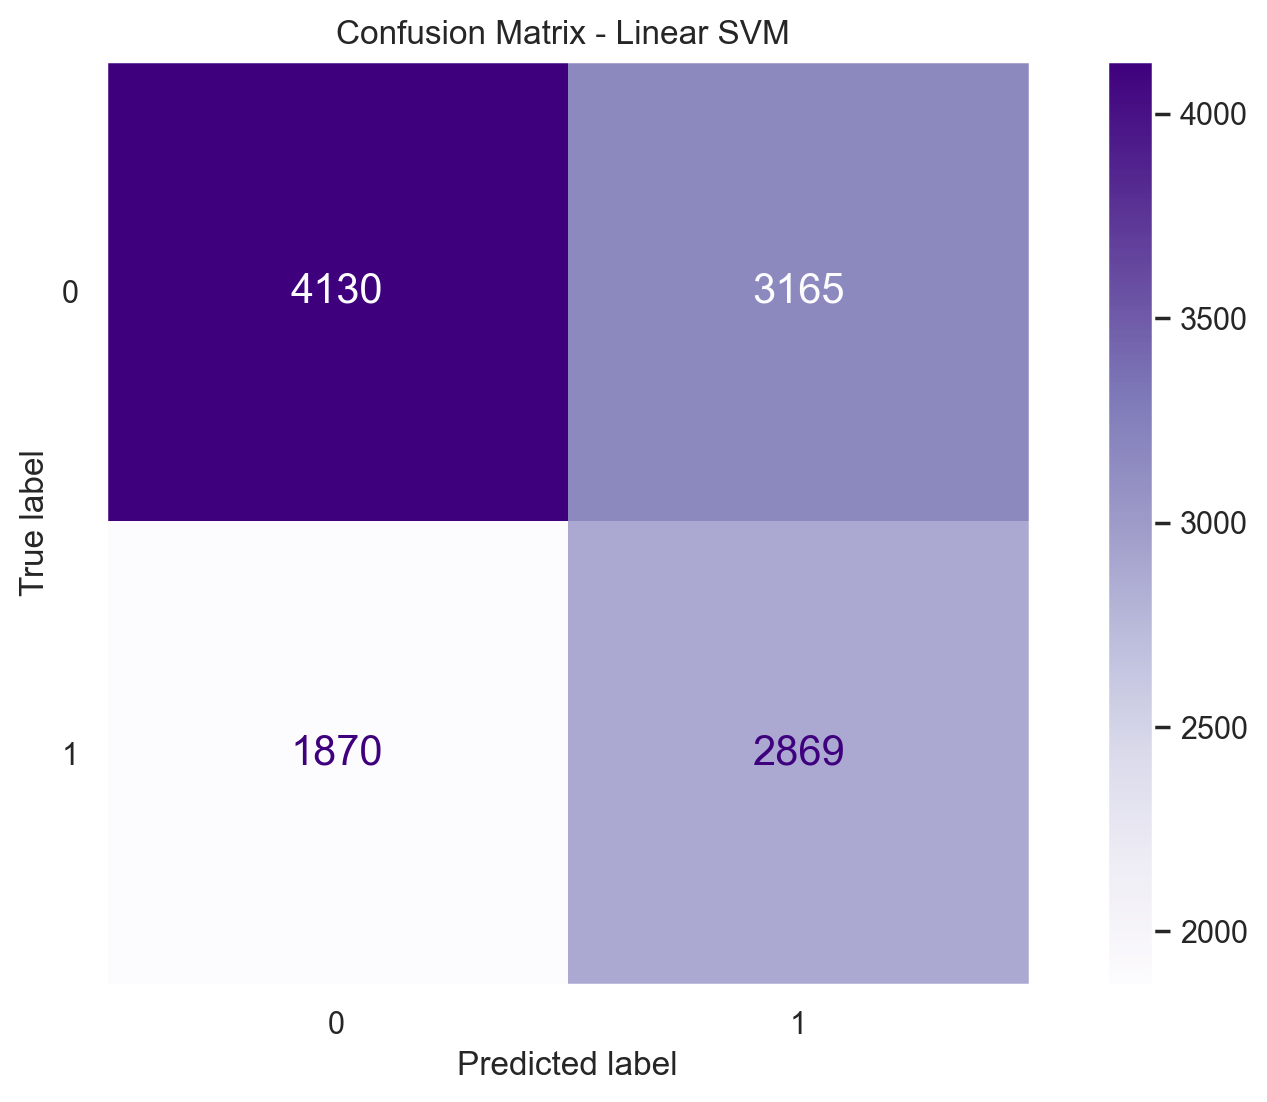

Linear SVM - Best Parameters: {'classifier__C': 0.01}
Linear SVM - Cross-validation Score: 0.5427 ± 0.0026

Training Random Forest...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
              precision     recall   f1-score    support
--------------------------------------------------
           0       0.70       0.63       0.66       7295
           1       0.50       0.58       0.54       4739
--------------------------------------------------
    accuracy                             0.61      12034
   macro avg       0.60       0.60       0.60      12034
weighted avg       0.62       0.61       0.61      12034
roc_auc_score 0.65


<Figure size 300x300 with 0 Axes>

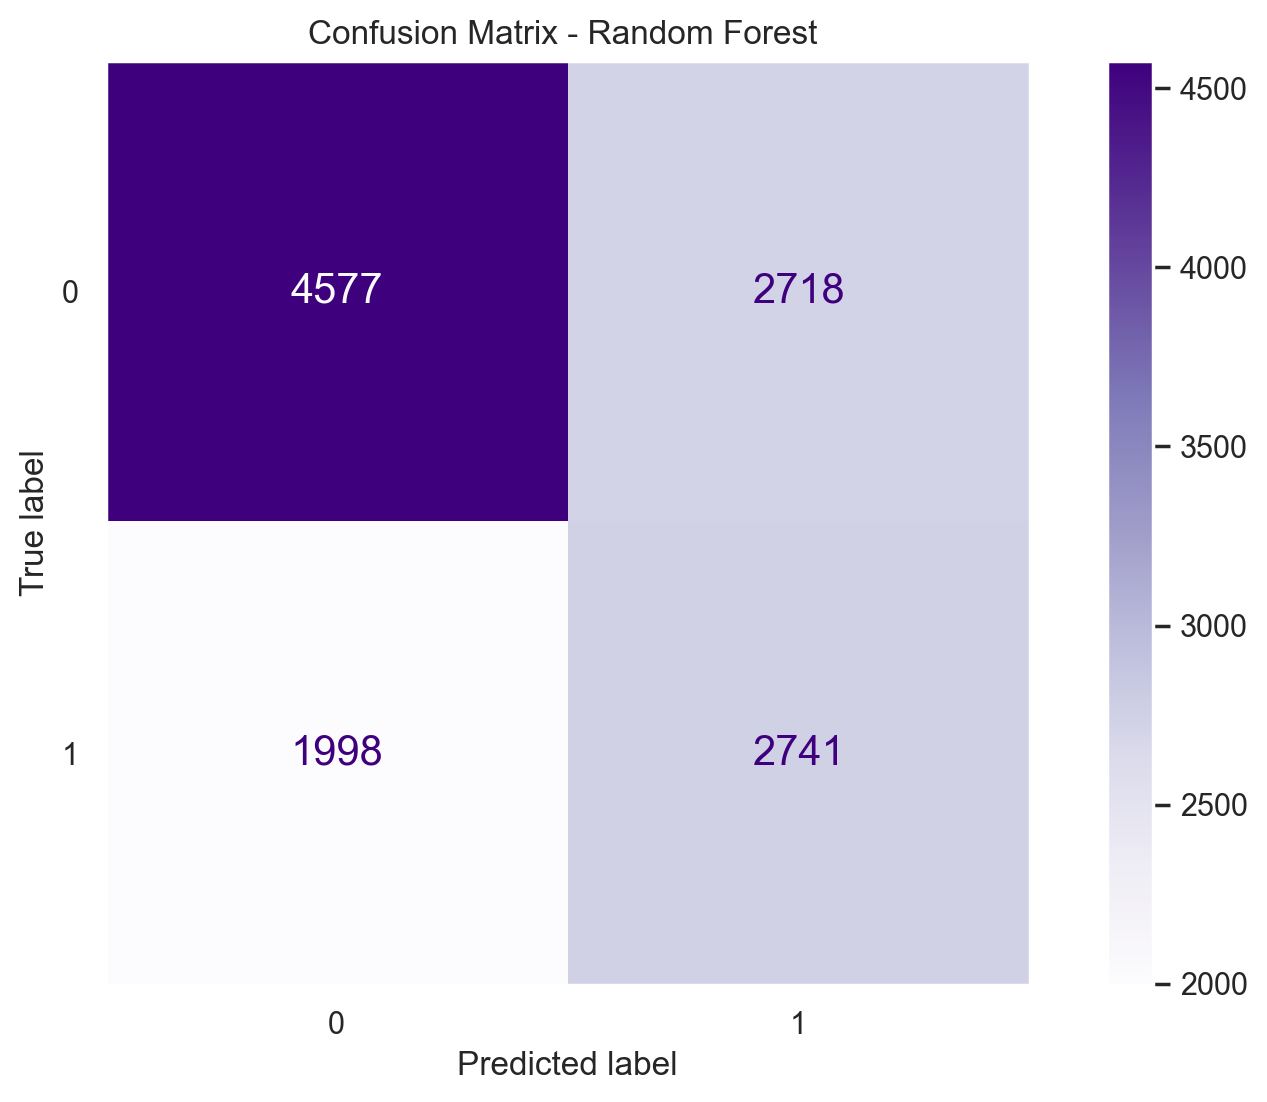

Random Forest - Best Parameters: {'classifier__max_depth': 10}
Random Forest - Cross-validation Score: 0.5390 ± 0.0066

Training Gradient Boosting...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
              precision     recall   f1-score    support
--------------------------------------------------
           0       0.65       0.78       0.71       7295
           1       0.52       0.37       0.43       4739
--------------------------------------------------
    accuracy                             0.62      12034
   macro avg       0.59       0.57       0.57      12034
weighted avg       0.60       0.62       0.60      12034
roc_auc_score 0.62


<Figure size 300x300 with 0 Axes>

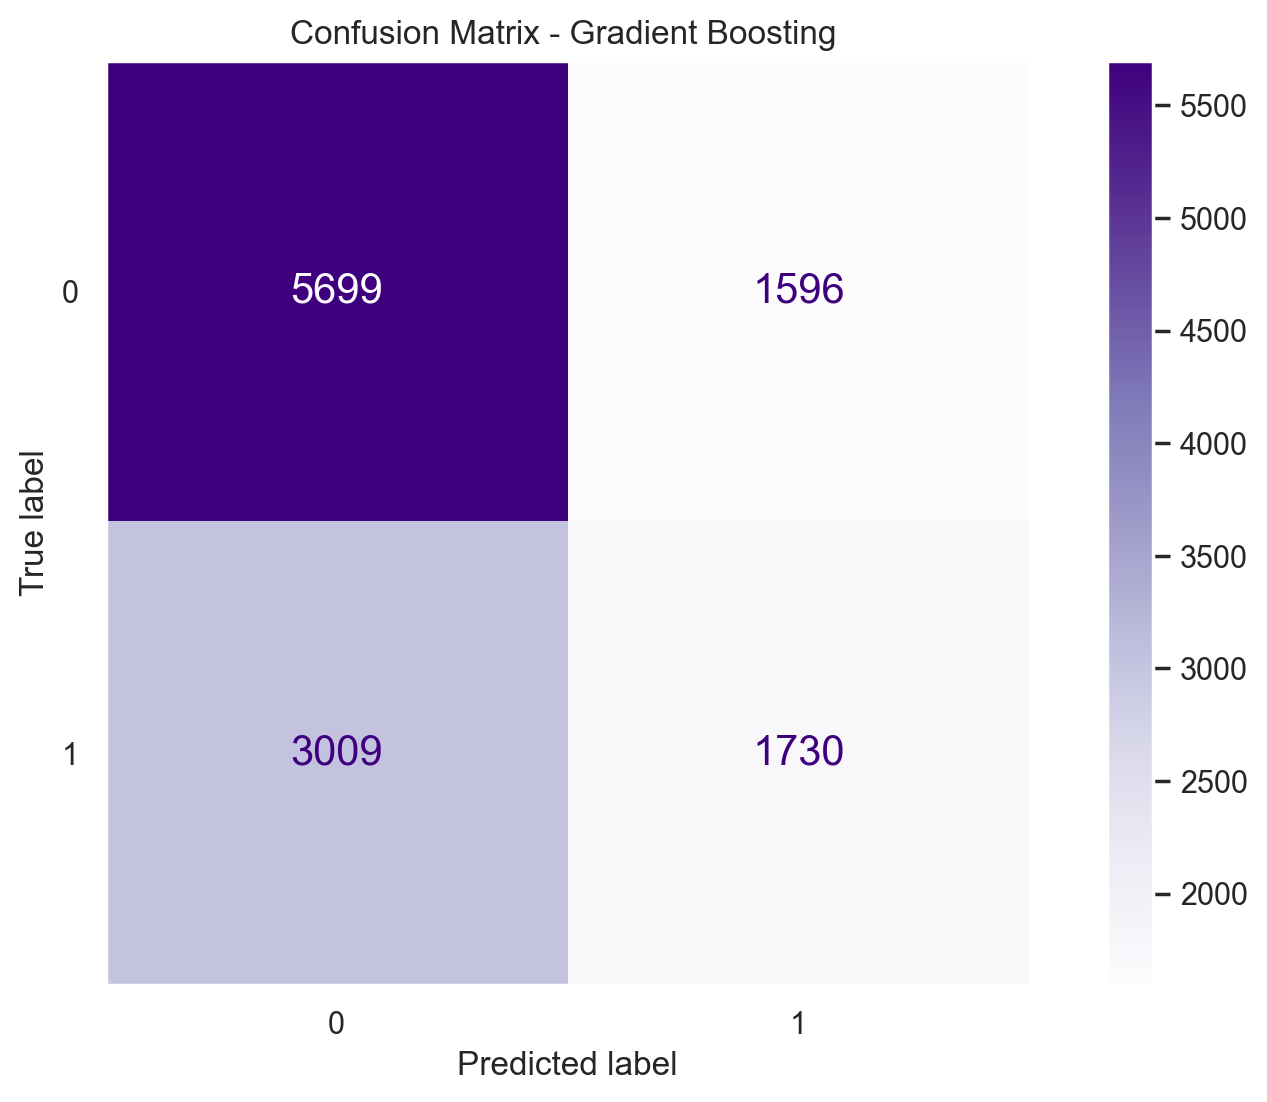

Gradient Boosting - Best Parameters: {'classifier__learning_rate': 1, 'classifier__n_estimators': 500}
Gradient Boosting - Cross-validation Score: 0.4273 ± 0.0066


In [36]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from utils import evaluate_model

def setup_models(X, y, random_state=42, n_jobs=-1):
    """
    Returns:
    --------
    dict
        Dictionary containing configured models with hyperparameter grids
    # """
    # Identify numerical and categorical columns
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Create preprocessing pipelines
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])
    
    # 1. Linear SVM (baseline)
    svm = LinearSVC(loss='hinge', random_state=random_state, dual=True,  max_iter=10000, class_weight='balanced')
    
    svm_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', svm)
    ])
    
    svm_param_grid = {
        'classifier__C': [0.0001, 0.001, 0.01, 0.1,],
    }
    
    # 2. Random Forest
    rf = RandomForestClassifier(random_state=random_state, n_jobs=n_jobs, class_weight="balanced")
    
    rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', rf)
    ])
    
    rf_param_grid = {
        'classifier__max_depth': [5, 10, 20, 50],
    }
    
    # 3. Gradient Boosting
    gb = GradientBoostingClassifier(random_state=random_state)
    
    gb_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', gb)
    ])
    
    gb_param_grid = {
        'classifier__n_estimators': [300, 400, 500],
        'classifier__learning_rate': [0.01, 0.1, 1],
    }
    
    # Return models with their parameter grids
    models = {
        'Linear SVM': (svm_pipeline, svm_param_grid),
        'Random Forest': (rf_pipeline, rf_param_grid),
        'Gradient Boosting': (gb_pipeline, gb_param_grid)
    }
    
    return models

def train_and_evaluate_models(X, y, models, cv=5, test_size=0.2, random_state=42):
    """
    Train and evaluate multiple machine learning models using cross-validation.
    
    Returns:
    --------
    tuple
        (best_models, cv_results, plot_data, test_results)
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    print(X_train.shape, X_test.shape) 
    
    # Set up cross-validation strategy
    stratified_cv = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    
    best_models = {}
    cv_results = {}
    test_results = {}
    all_model_results_dfs = {} 
    
    
    for model_name, (pipeline, param_grid) in models.items():
        print(f"\nTraining {model_name}...")
        
        grid_search = GridSearchCV(
            pipeline, 
            param_grid, 
            cv=stratified_cv,
            scoring="f1",
            n_jobs=-1,
            verbose=1
        )
        
        # Fit model
        grid_search.fit(X_train, y_train)
        
        # Store best model
        best_models[model_name] = grid_search.best_estimator_
        
        # Store original CV results
        cv_results[model_name] = grid_search.cv_results_
        
        # Create a DataFrame for easy plotting
        model_results_df = pd.DataFrame()
        
        # Add scores and standard deviations
        model_results_df['mean_score'] = grid_search.cv_results_['mean_test_score']
        model_results_df['std_score'] = grid_search.cv_results_['std_test_score']
        
        # Add hyperparameter values as separate columns
        for i, params in enumerate(grid_search.cv_results_['params']):
            for param_name, param_value in params.items():
                # Clean parameter name for better display
                clean_name = param_name.replace('classifier__', '')
                model_results_df.loc[i, clean_name] = param_value
        
        # Store the DataFrame in plot_data
        all_model_results_dfs[model_name] = model_results_df
        
        # Evaluate on test set
        y_pred = grid_search.best_estimator_.predict(X_test)
        if model_name == 'Linear SVM':
            y_proba_test = grid_search.best_estimator_.decision_function(X_test)
        else:
            y_proba_test = grid_search.best_estimator_.predict_proba(X_test)[:, 1]
        # Calculate metrics
        test_results[model_name] = calculate_best_model_metrics(y_test, y_pred, y_proba_test, model_name)
        
        print(f"{model_name} - Best Parameters: {grid_search.best_params_}")
        print(f"{model_name} - Cross-validation Score: {grid_search.best_score_:.4f} ± {grid_search.cv_results_['std_test_score'][grid_search.best_index_]:.4f}")
        # print(f"{model_name} - Test F1 Score: {test_results[model_name]['F1-Score']:.4f}")
    
    return best_models, cv_results, all_model_results_dfs, test_results

# Example usage:
# Prepare your data
X = encoded_diabetes_df.drop('readmitted', axis=1)
y = encoded_diabetes_df['readmitted']

# Set up models
models = setup_models(X, y)

# Train and evaluate models
best_models, cv_results, all_model_results_dfs, test_results = train_and_evaluate_models(X, y, models, cv=5)

In [44]:
test_results['Gradient Boosting']['Class F1'][1]

np.float64(0.42901425914445135)

In [37]:
all_model_results_dfs['Linear SVM']

,mean_score,std_score,C
0,0.531575,0.004312,0.0001
1,0.542092,0.002767,0.0010
2,0.542701,0.002622,0.0100
3,0.542690,0.002932,0.1000


In [45]:
def plot_hyperparameter_performance(plot_data, model_name):
    """
    Create plots showing model performance across hyperparameter values.
    
    Parameters:
    -----------
    plot_data : dict
        Dictionary containing DataFrames with CV results for each model
    model_name : str
        Name of the model to plot
    """
    if model_name not in plot_data:
        print(f"No data found for model: {model_name}")
        return
    
    df = plot_data[model_name]
    
    # Get hyperparameter columns
    param_cols = [col for col in df.columns if col not in ['mean_score', 'std_score']]
    
    # For SVM with C and class_weight, create a line plot instead
    if 'C' in param_cols and 'class_weight' in param_cols:
        plt.figure(figsize=(10, 6))
        
        # Plot separately for each class_weight value
        for weight in df['class_weight'].unique():
            subset = df[df['class_weight'] == weight].sort_values('C')
            plt.plot(subset['C'], subset['mean_score'], 
                     marker='o', label=f'class_weight={weight}')
            
            # Add error bands
            plt.fill_between(
                subset['C'],
                subset['mean_score'] - subset['std_score'],
                subset['mean_score'] + subset['std_score'],
                alpha=0.2
            )
        
        plt.xscale('log')  # Log scale for C parameter
        plt.title(f"{model_name}: Performance by C for different class weights")
        plt.xlabel('C parameter (log scale)')
        plt.ylabel('Mean CV Score')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        
        # Also create a different view - group by class_weight with separate lines for C values
        plt.figure(figsize=(8, 6))
        
        # Create grouped bar plot
        sns.barplot(x='class_weight', y='mean_score', hue='C', data=df)
        
        plt.title(f"{model_name}: Performance by class_weight for different C values")
        plt.xlabel('class_weight')
        plt.ylabel('Mean CV Score')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        
    # If only C parameter exists
    elif 'C' in param_cols and len(param_cols) == 1:
        plt.figure(figsize=(10, 6))
        sorted_df = df.sort_values('C')
        
        # Create line plot
        plt.plot(sorted_df['C'], sorted_df['mean_score'], marker='o')
        
        # Add error bands
        plt.fill_between(
            sorted_df['C'],
            sorted_df['mean_score'] - sorted_df['std_score'],
            sorted_df['mean_score'] + sorted_df['std_score'],
            alpha=0.2
        )
        
        plt.xscale('log')
        plt.title(f"{model_name}: Performance by C parameter")
        plt.xlabel('C parameter (log scale)')
        plt.ylabel('Mean CV Score')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        
    # For other parameter combinations
    else:
        # Default case: create a pairplot of parameters
        if len(param_cols) >= 2:
            # For each pair of parameters
            for i, param1 in enumerate(param_cols):
                for param2 in param_cols[i+1:]:
                    plt.figure(figsize=(10, 6))
                    
                    # If both parameters are numeric
                    if pd.api.types.is_numeric_dtype(df[param1]) and pd.api.types.is_numeric_dtype(df[param2]):
                        # Create a heatmap if there are multiple values for each parameter
                        if len(df[param1].unique()) > 1 and len(df[param2].unique()) > 1:
                            pivot = df.pivot_table(
                                index=param1, columns=param2, values='mean_score'
                            )
                            sns.heatmap(pivot, annot=True, cmap='viridis')
                            plt.title(f"{model_name}: {param1} vs {param2}")
                            
                    # If one parameter is categorical
                    else:
                        # Decide which one is categorical
                        if pd.api.types.is_numeric_dtype(df[param1]):
                            cat_param, num_param = param2, param1
                        else:
                            cat_param, num_param = param1, param2
                            
                        # Create line plots for each category
                        for cat in df[cat_param].unique():
                            subset = df[df[cat_param] == cat].sort_values(num_param)
                            plt.plot(subset[num_param], subset['mean_score'], 
                                    marker='o', label=f"{cat_param}={cat}")
                            
                        if num_param in ['C', 'learning_rate', 'alpha']:
                            plt.xscale('log')
                            
                        plt.xlabel(num_param)
                        plt.ylabel('Mean CV Score')
                        plt.legend()
                        plt.title(f"{model_name}: Performance by {num_param} for different {cat_param} values")
                    
                    plt.tight_layout()
                    plt.show()
        
        # If only one parameter
        else:
            param = param_cols[0]
            plt.figure(figsize=(10, 6))
            
            if pd.api.types.is_numeric_dtype(df[param]):
                # Sort by parameter value
                sorted_df = df.sort_values(param)
                
                # Line plot for numeric parameter
                plt.plot(sorted_df[param], sorted_df['mean_score'], marker='o')
                
                # Add error bands
                plt.fill_between(
                    sorted_df[param],
                    sorted_df['mean_score'] - sorted_df['std_score'],
                    sorted_df['mean_score'] + sorted_df['std_score'],
                    alpha=0.2
                )
                
                if param in ['C', 'learning_rate', 'alpha']:
                    plt.xscale('log')
            else:
                # Bar plot for categorical parameter
                sns.barplot(x=param, y='mean_score', data=df)
                
                # Add error bars
                plt.errorbar(
                    x=range(len(df)),
                    y=df['mean_score'],
                    yerr=df['std_score'],
                    fmt='none',
                    c='black',
                    capsize=5
                )
            
            plt.title(f"{model_name}: Performance by {param}")
            plt.xlabel(param)
            plt.ylabel('Mean CV Score')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()

def plot_all_models_comparison(plot_data, test_results):
    """
    Create a comparison plot showing the best CV score and test scores for each model.
    
    Parameters:
    -----------
    plot_data : dict
        Dictionary containing DataFrames with CV results for each model
    test_results : dict
        Dictionary containing test results for each model
        
    Returns:
    --------
    None (displays plot)
    """
    # Extract best score for each model
    models = []
    cv_scores = []
    cv_std_scores = []
    test_scores = []
    
    for model_name, df in plot_data.items():
        best_idx = df['mean_score'].idxmax()
        models.append(model_name)
        cv_scores.append(df.loc[best_idx, 'mean_score'])
        cv_std_scores.append(df.loc[best_idx, 'std_score'])
        test_scores.append(test_results[model_name]['Class F1'][1])  # Extract test F1 score
    
    # Create figure and axis
    plt.figure(figsize=(12, 6))
    
    # Set width of bars
    bar_width = 0.35
    
    # Set positions of bars on X axis
    r1 = np.arange(len(models))
    r2 = [x + bar_width for x in r1]
    
    # Create bars
    plt.bar(r1, cv_scores, width=bar_width, label='CV Score', color='royalblue', yerr=cv_std_scores, capsize=5)
    plt.bar(r2, test_scores, width=bar_width, label='Test Score', color='lightcoral')
    
    # Add value labels on top of bars
    for i, score in enumerate(cv_scores):
        plt.text(r1[i], score + 0.01, f'{score:.4f}', ha='center', va='bottom')
    
    for i, score in enumerate(test_scores):
        plt.text(r2[i], score + 0.01, f'{score:.4f}', ha='center', va='bottom')
    
    # Add xticks on the middle of the group bars
    plt.xlabel('Model')
    plt.ylabel('F1 Score')
    plt.title('Comparison of CV and Test F1 Scores Across Models')
    plt.xticks([r + bar_width/2 for r in range(len(models))], models)
    
    # Create legend & show graphic
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

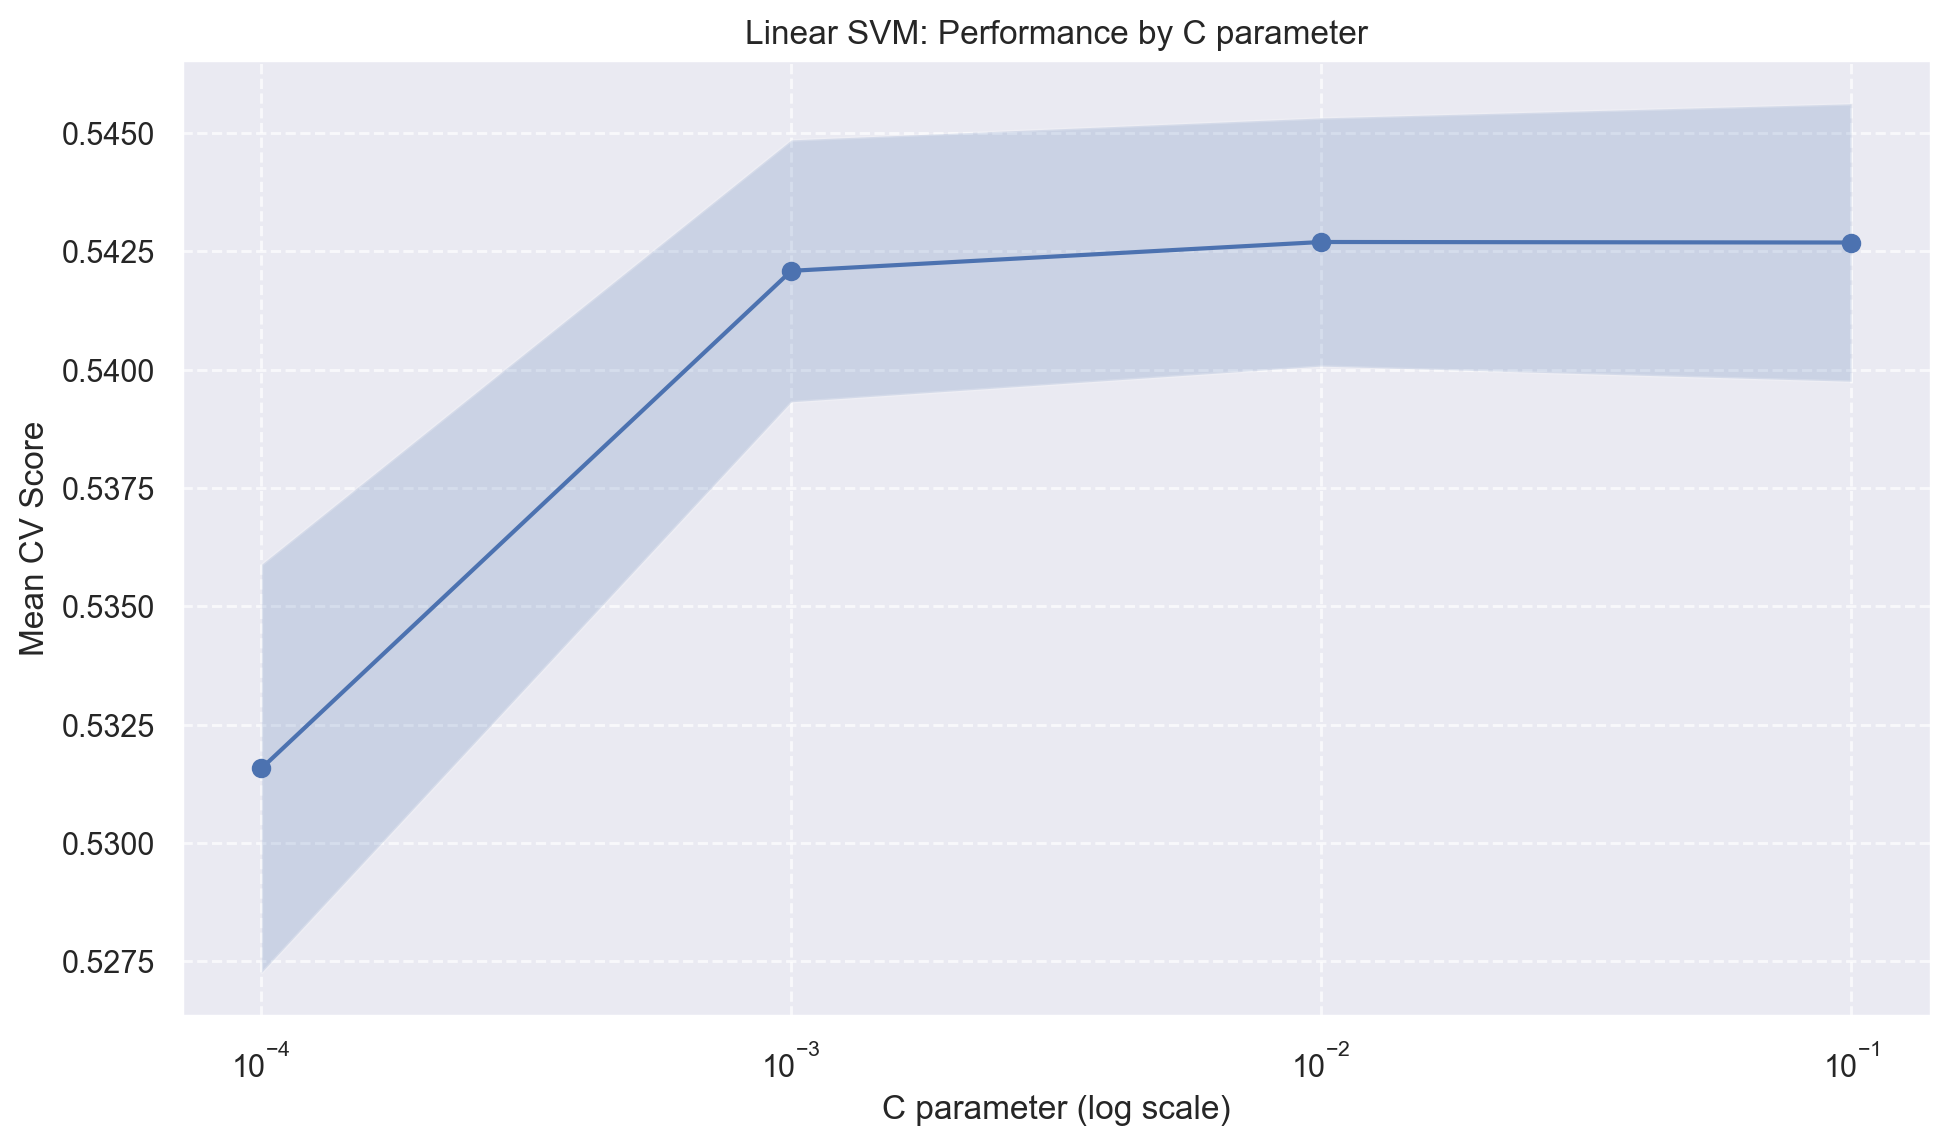

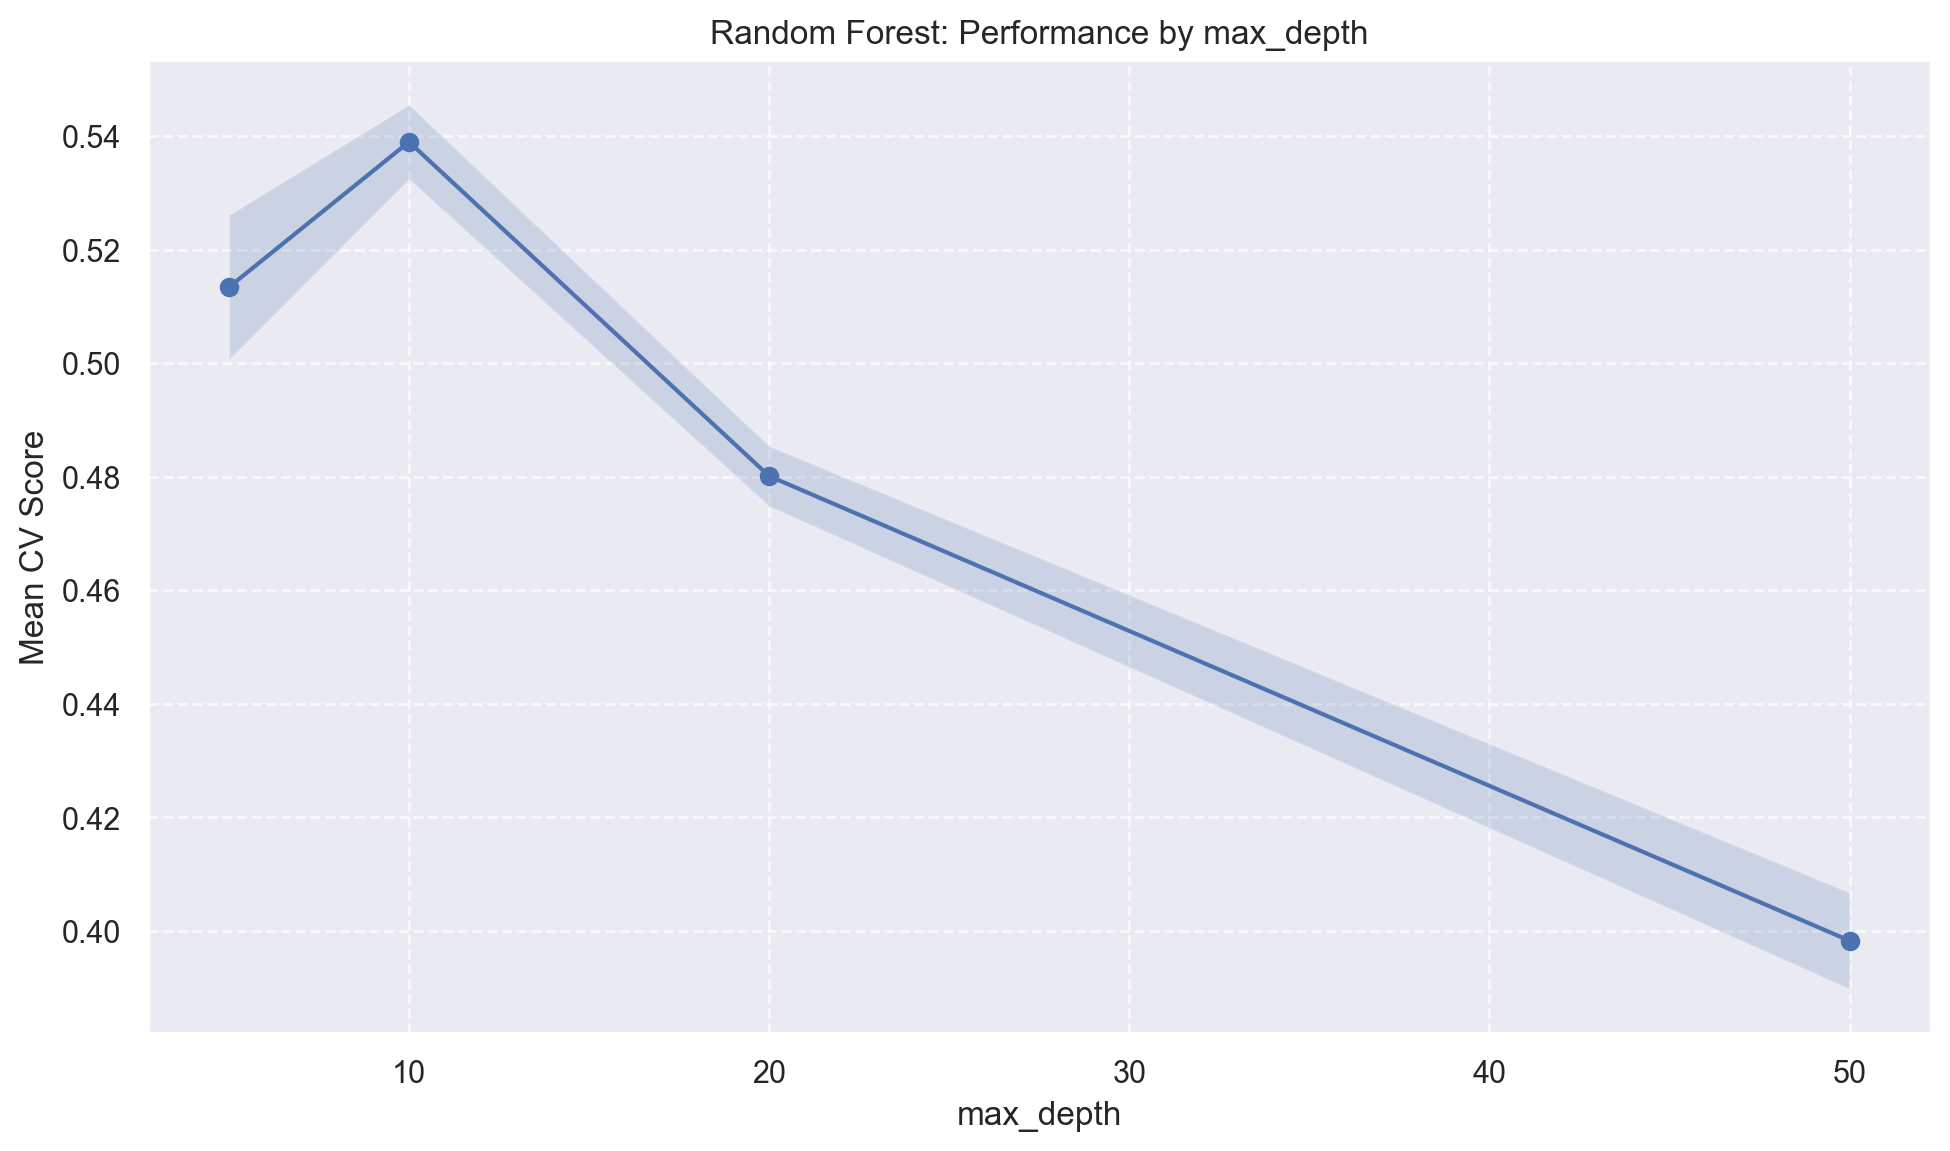

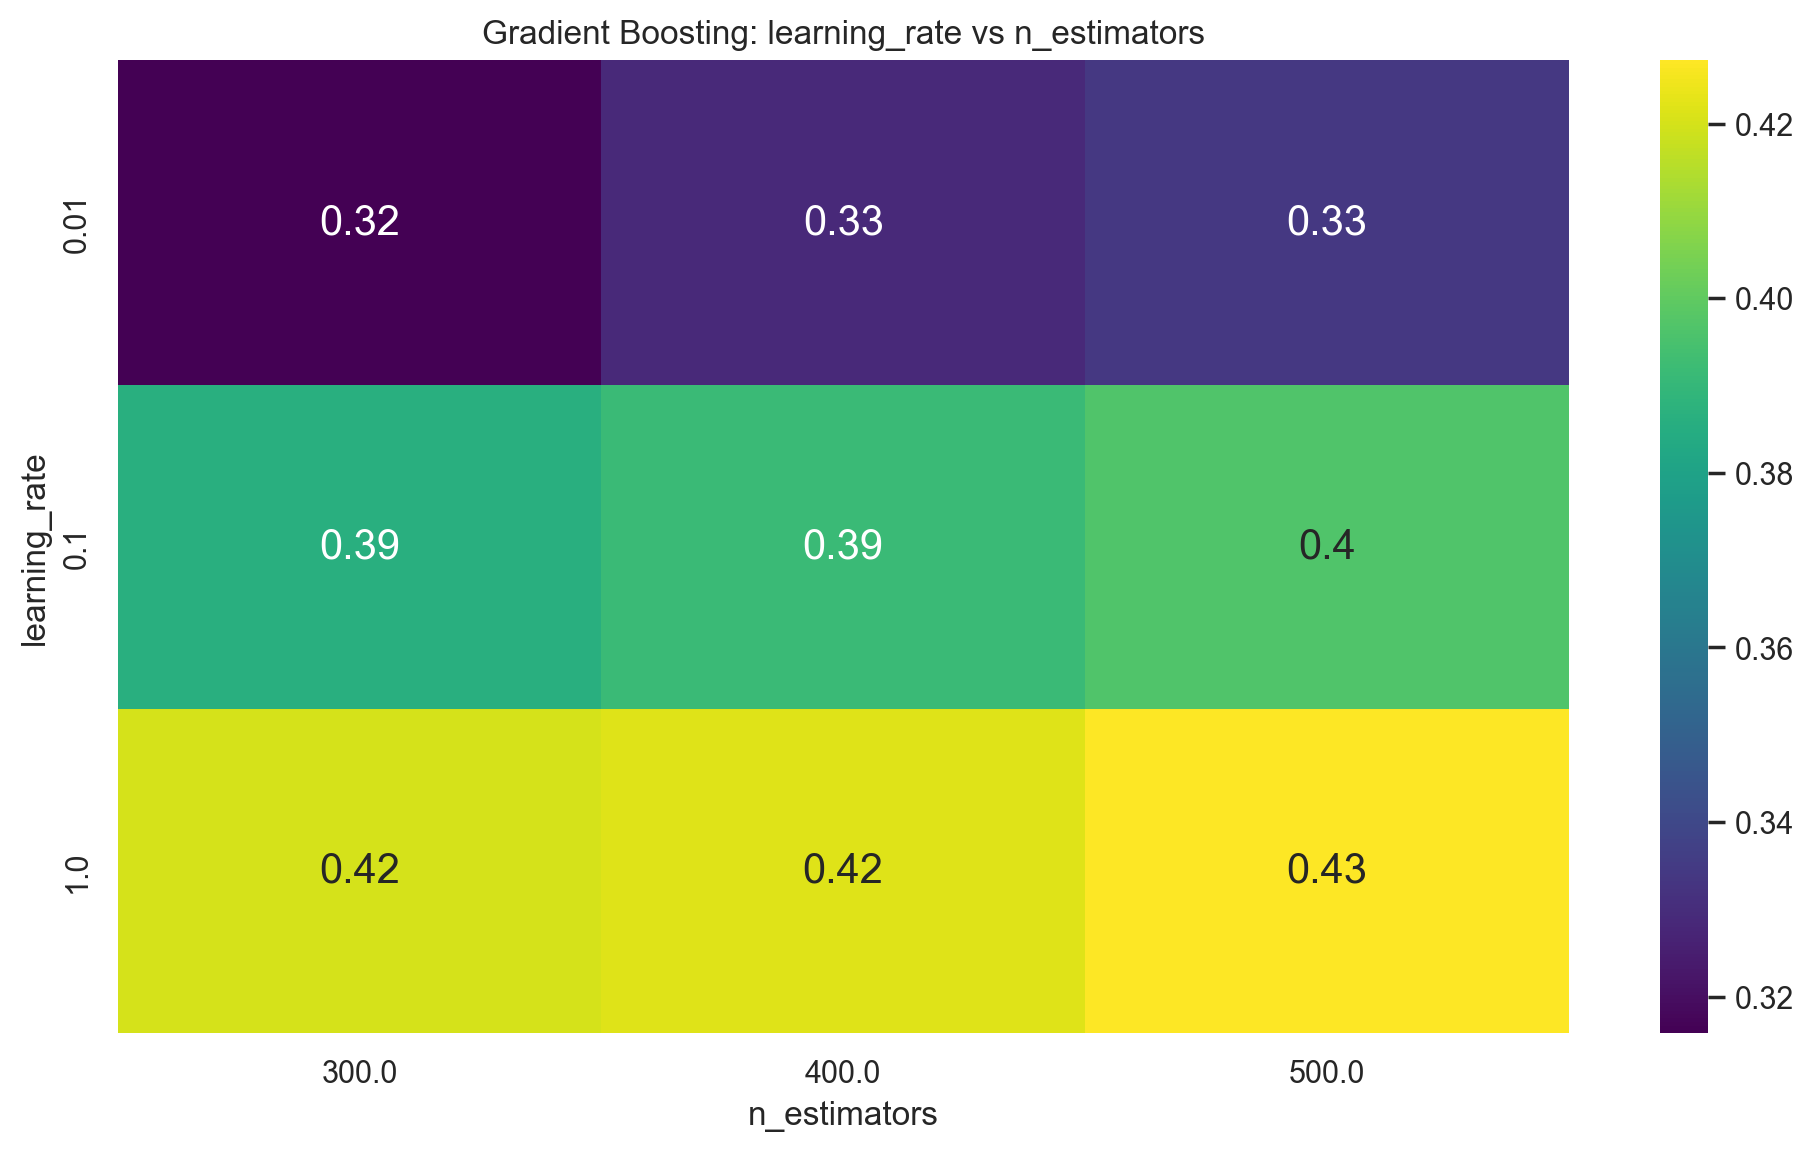

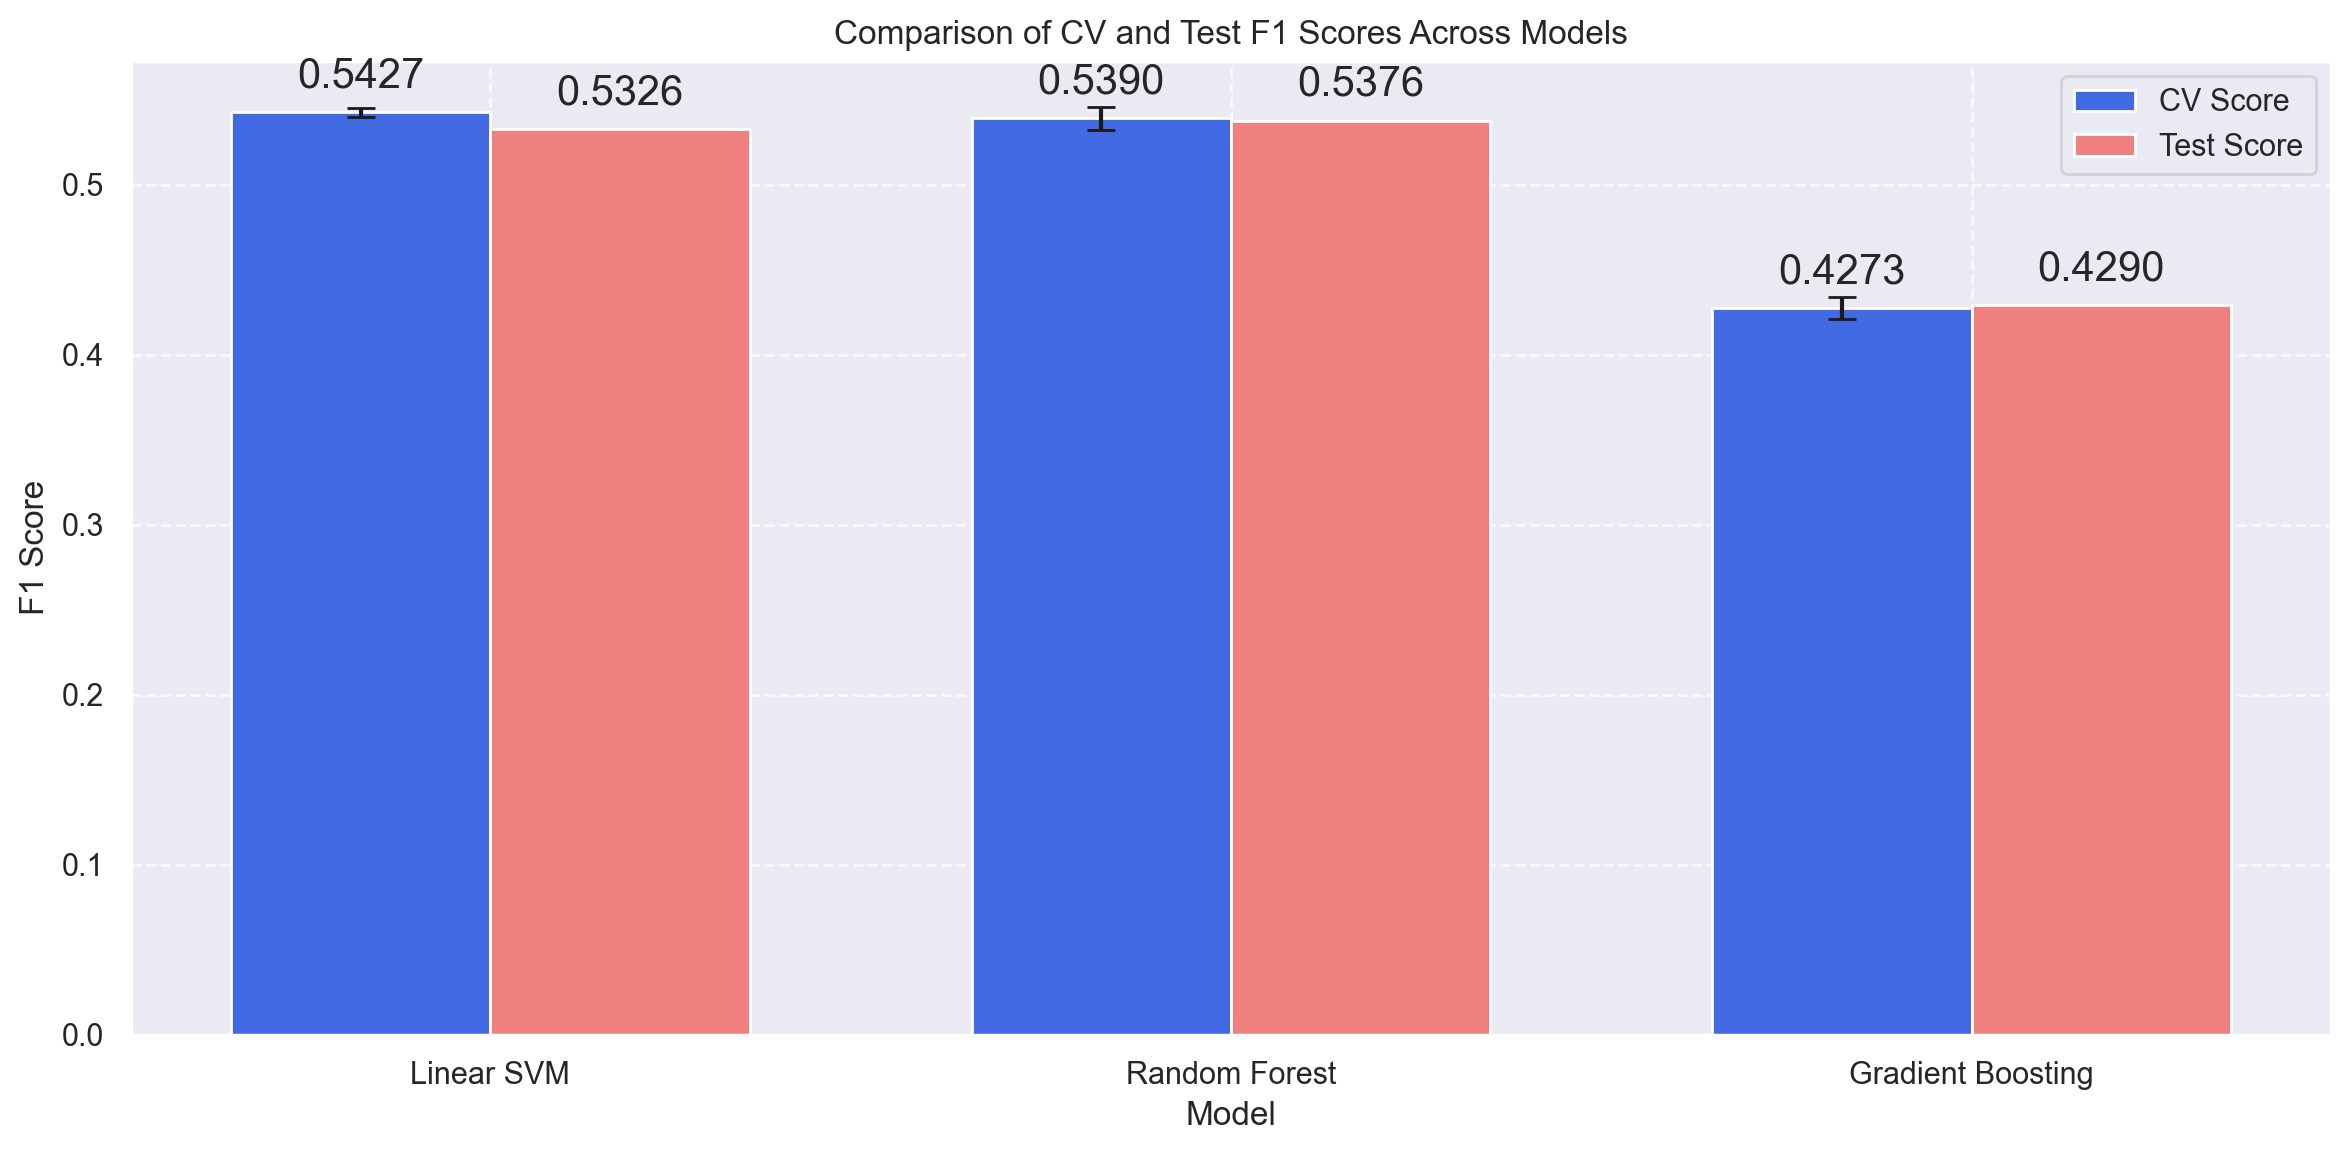

In [46]:
plot_hyperparameter_performance(all_model_results_dfs, 'Linear SVM')

plot_hyperparameter_performance(all_model_results_dfs, 'Random Forest')

plot_hyperparameter_performance(all_model_results_dfs, 'Gradient Boosting')

plot_all_models_comparison(all_model_results_dfs, test_results)

## 4. Model Interpretation

C:\Users\Gugu\AppData\Local\Temp\ipykernel_114612\498281950.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


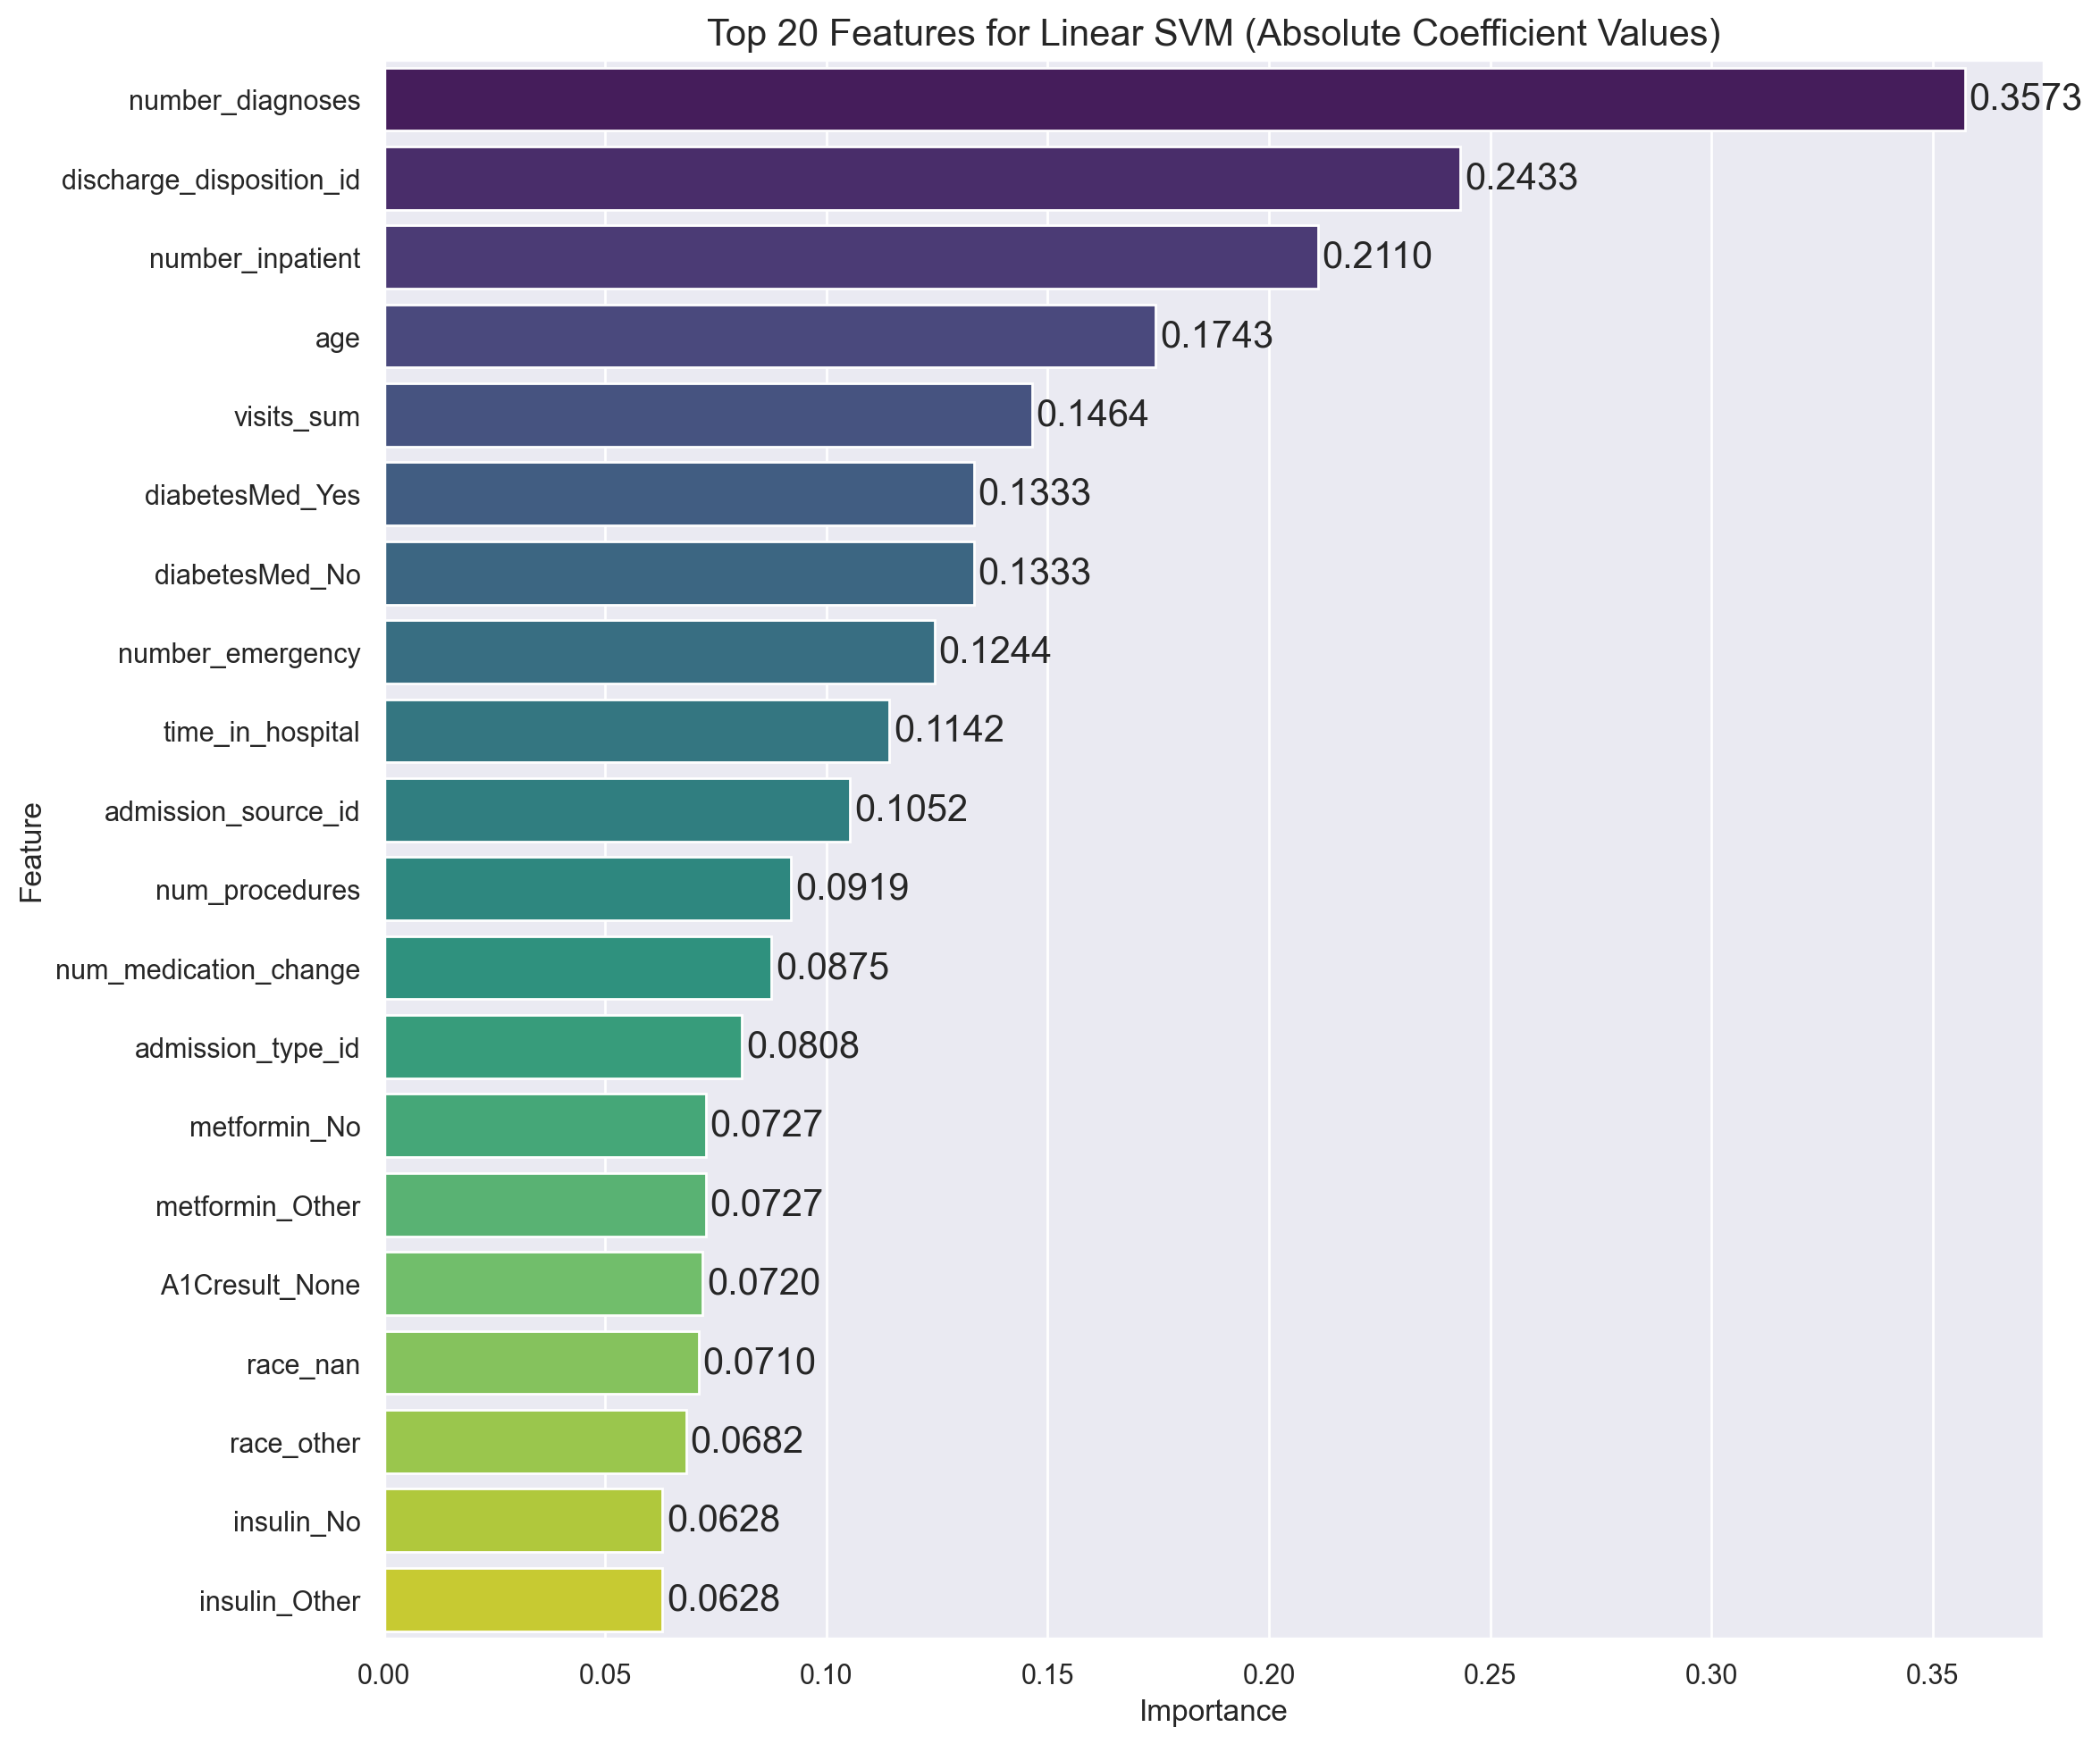

C:\Users\Gugu\AppData\Local\Temp\ipykernel_114612\498281950.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Coefficient', y='Feature', data=top_coef, palette=colors)


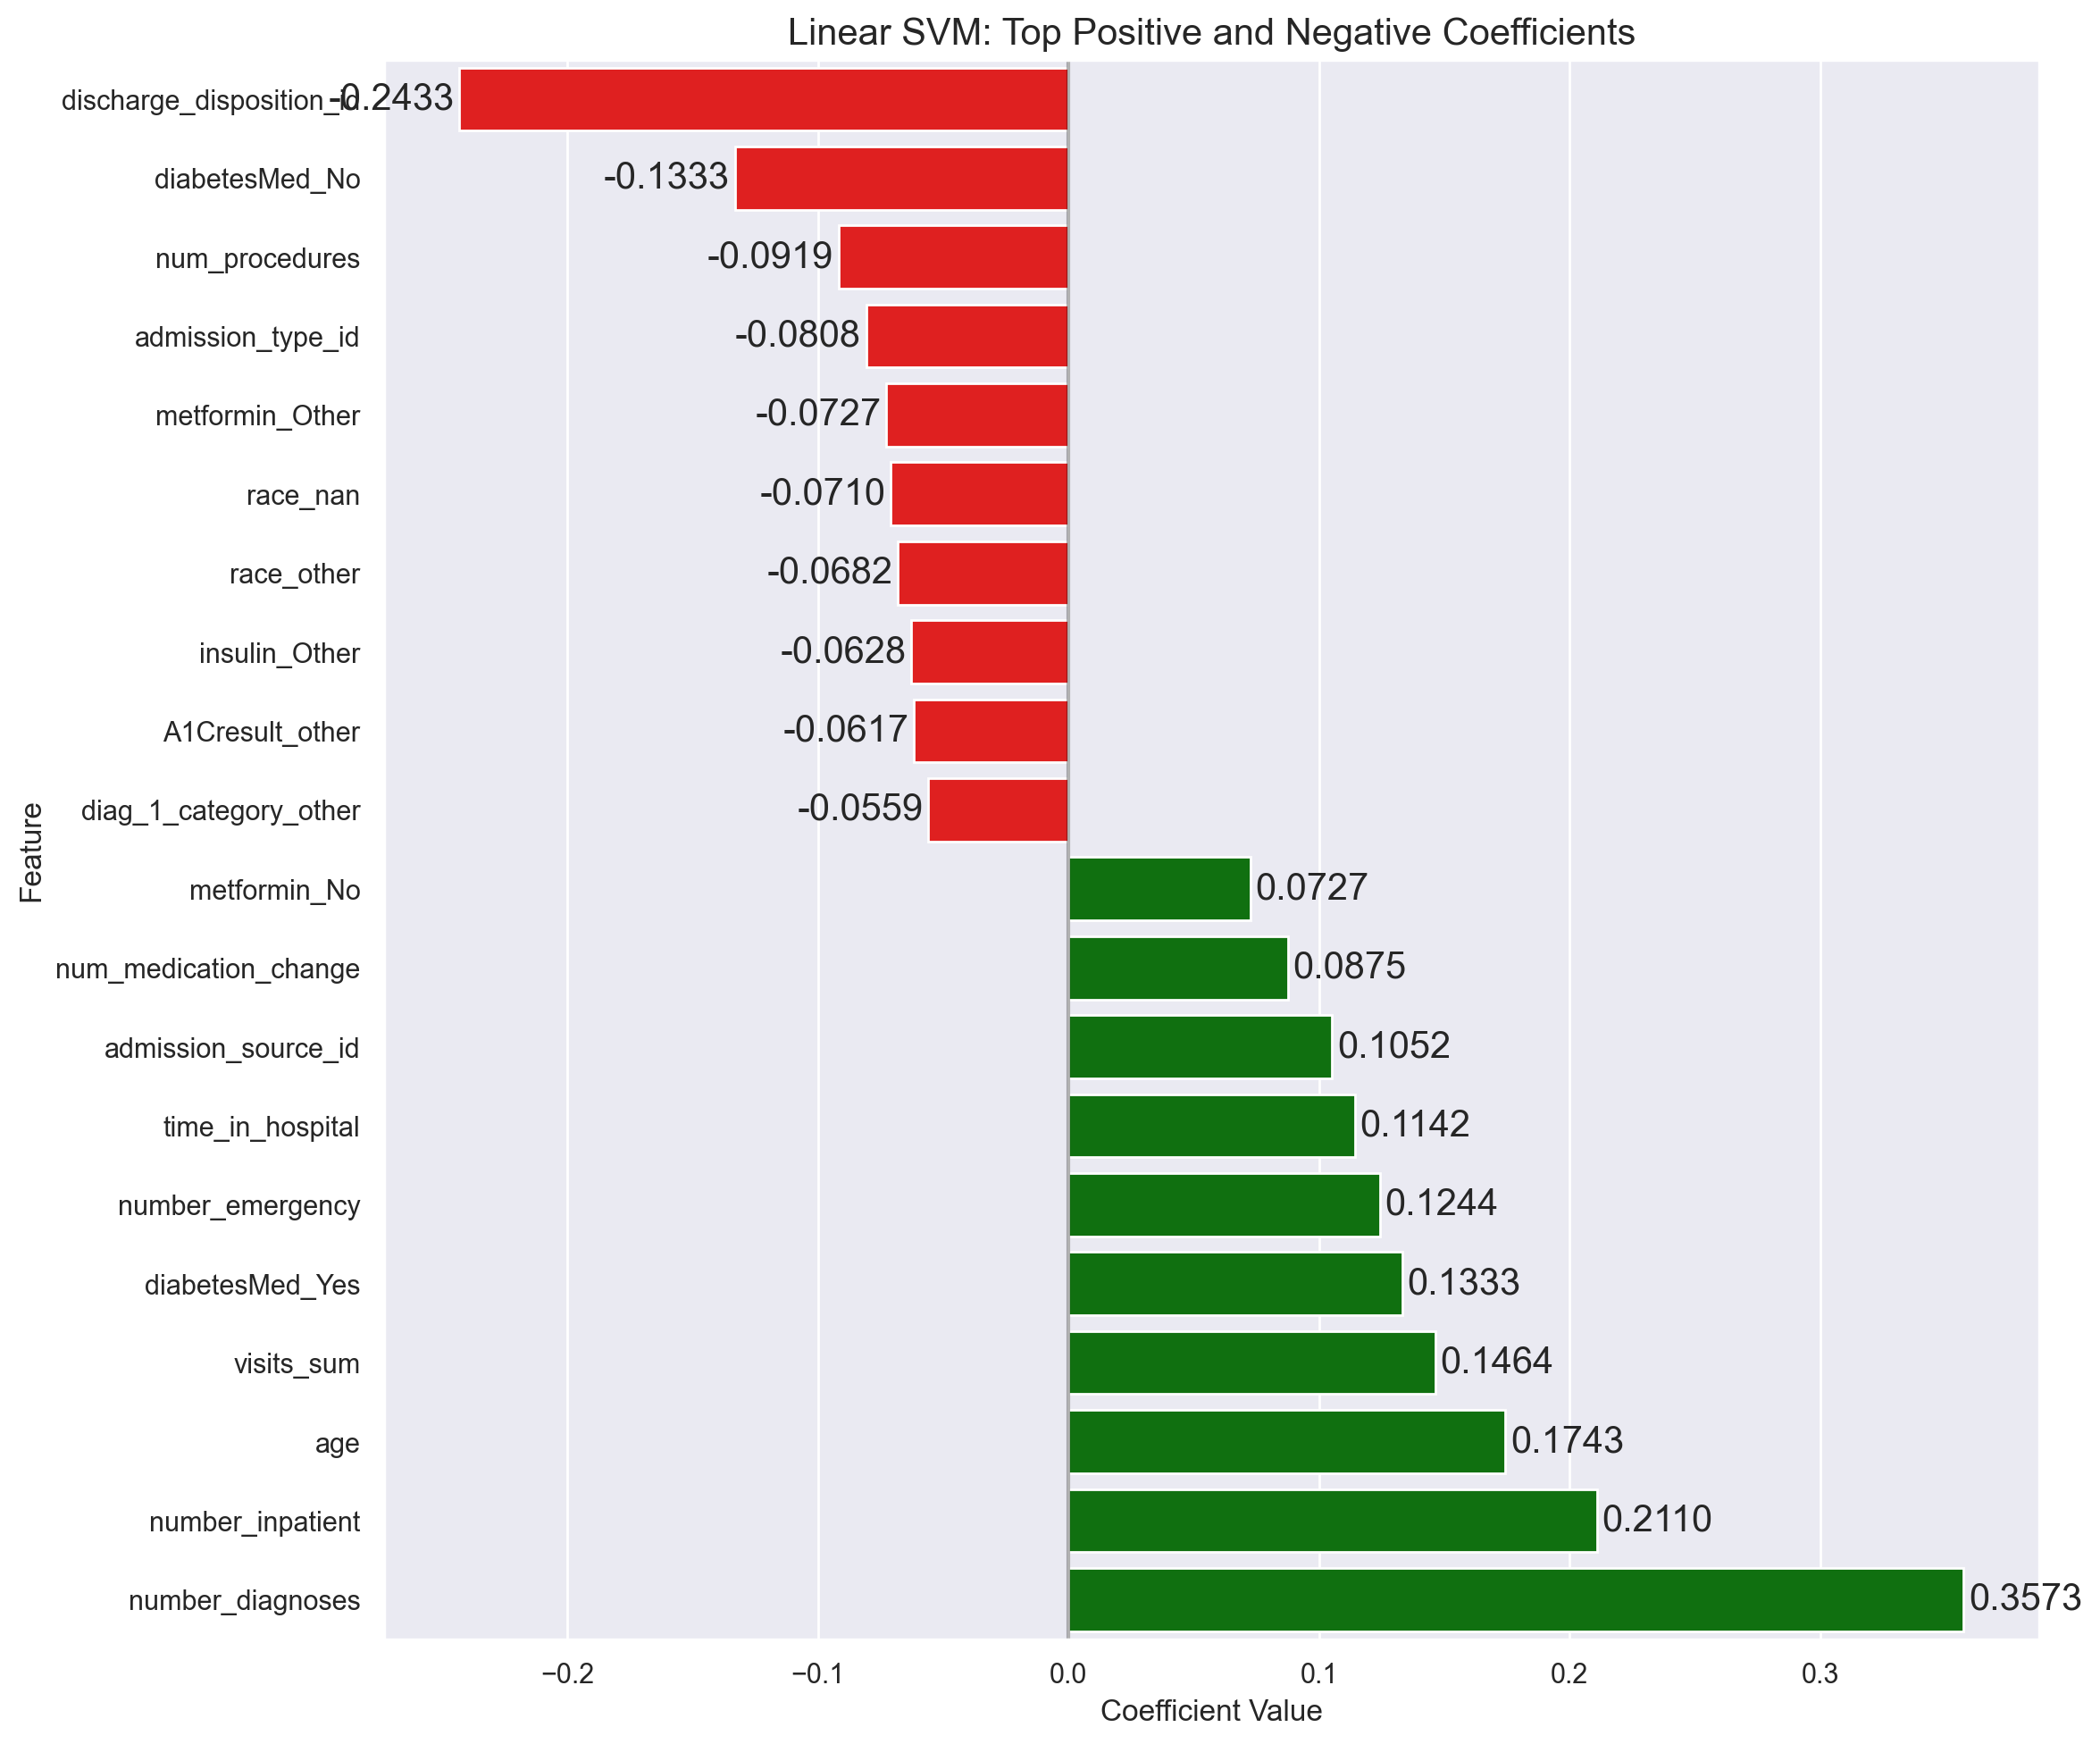

C:\Users\Gugu\AppData\Local\Temp\ipykernel_114612\498281950.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


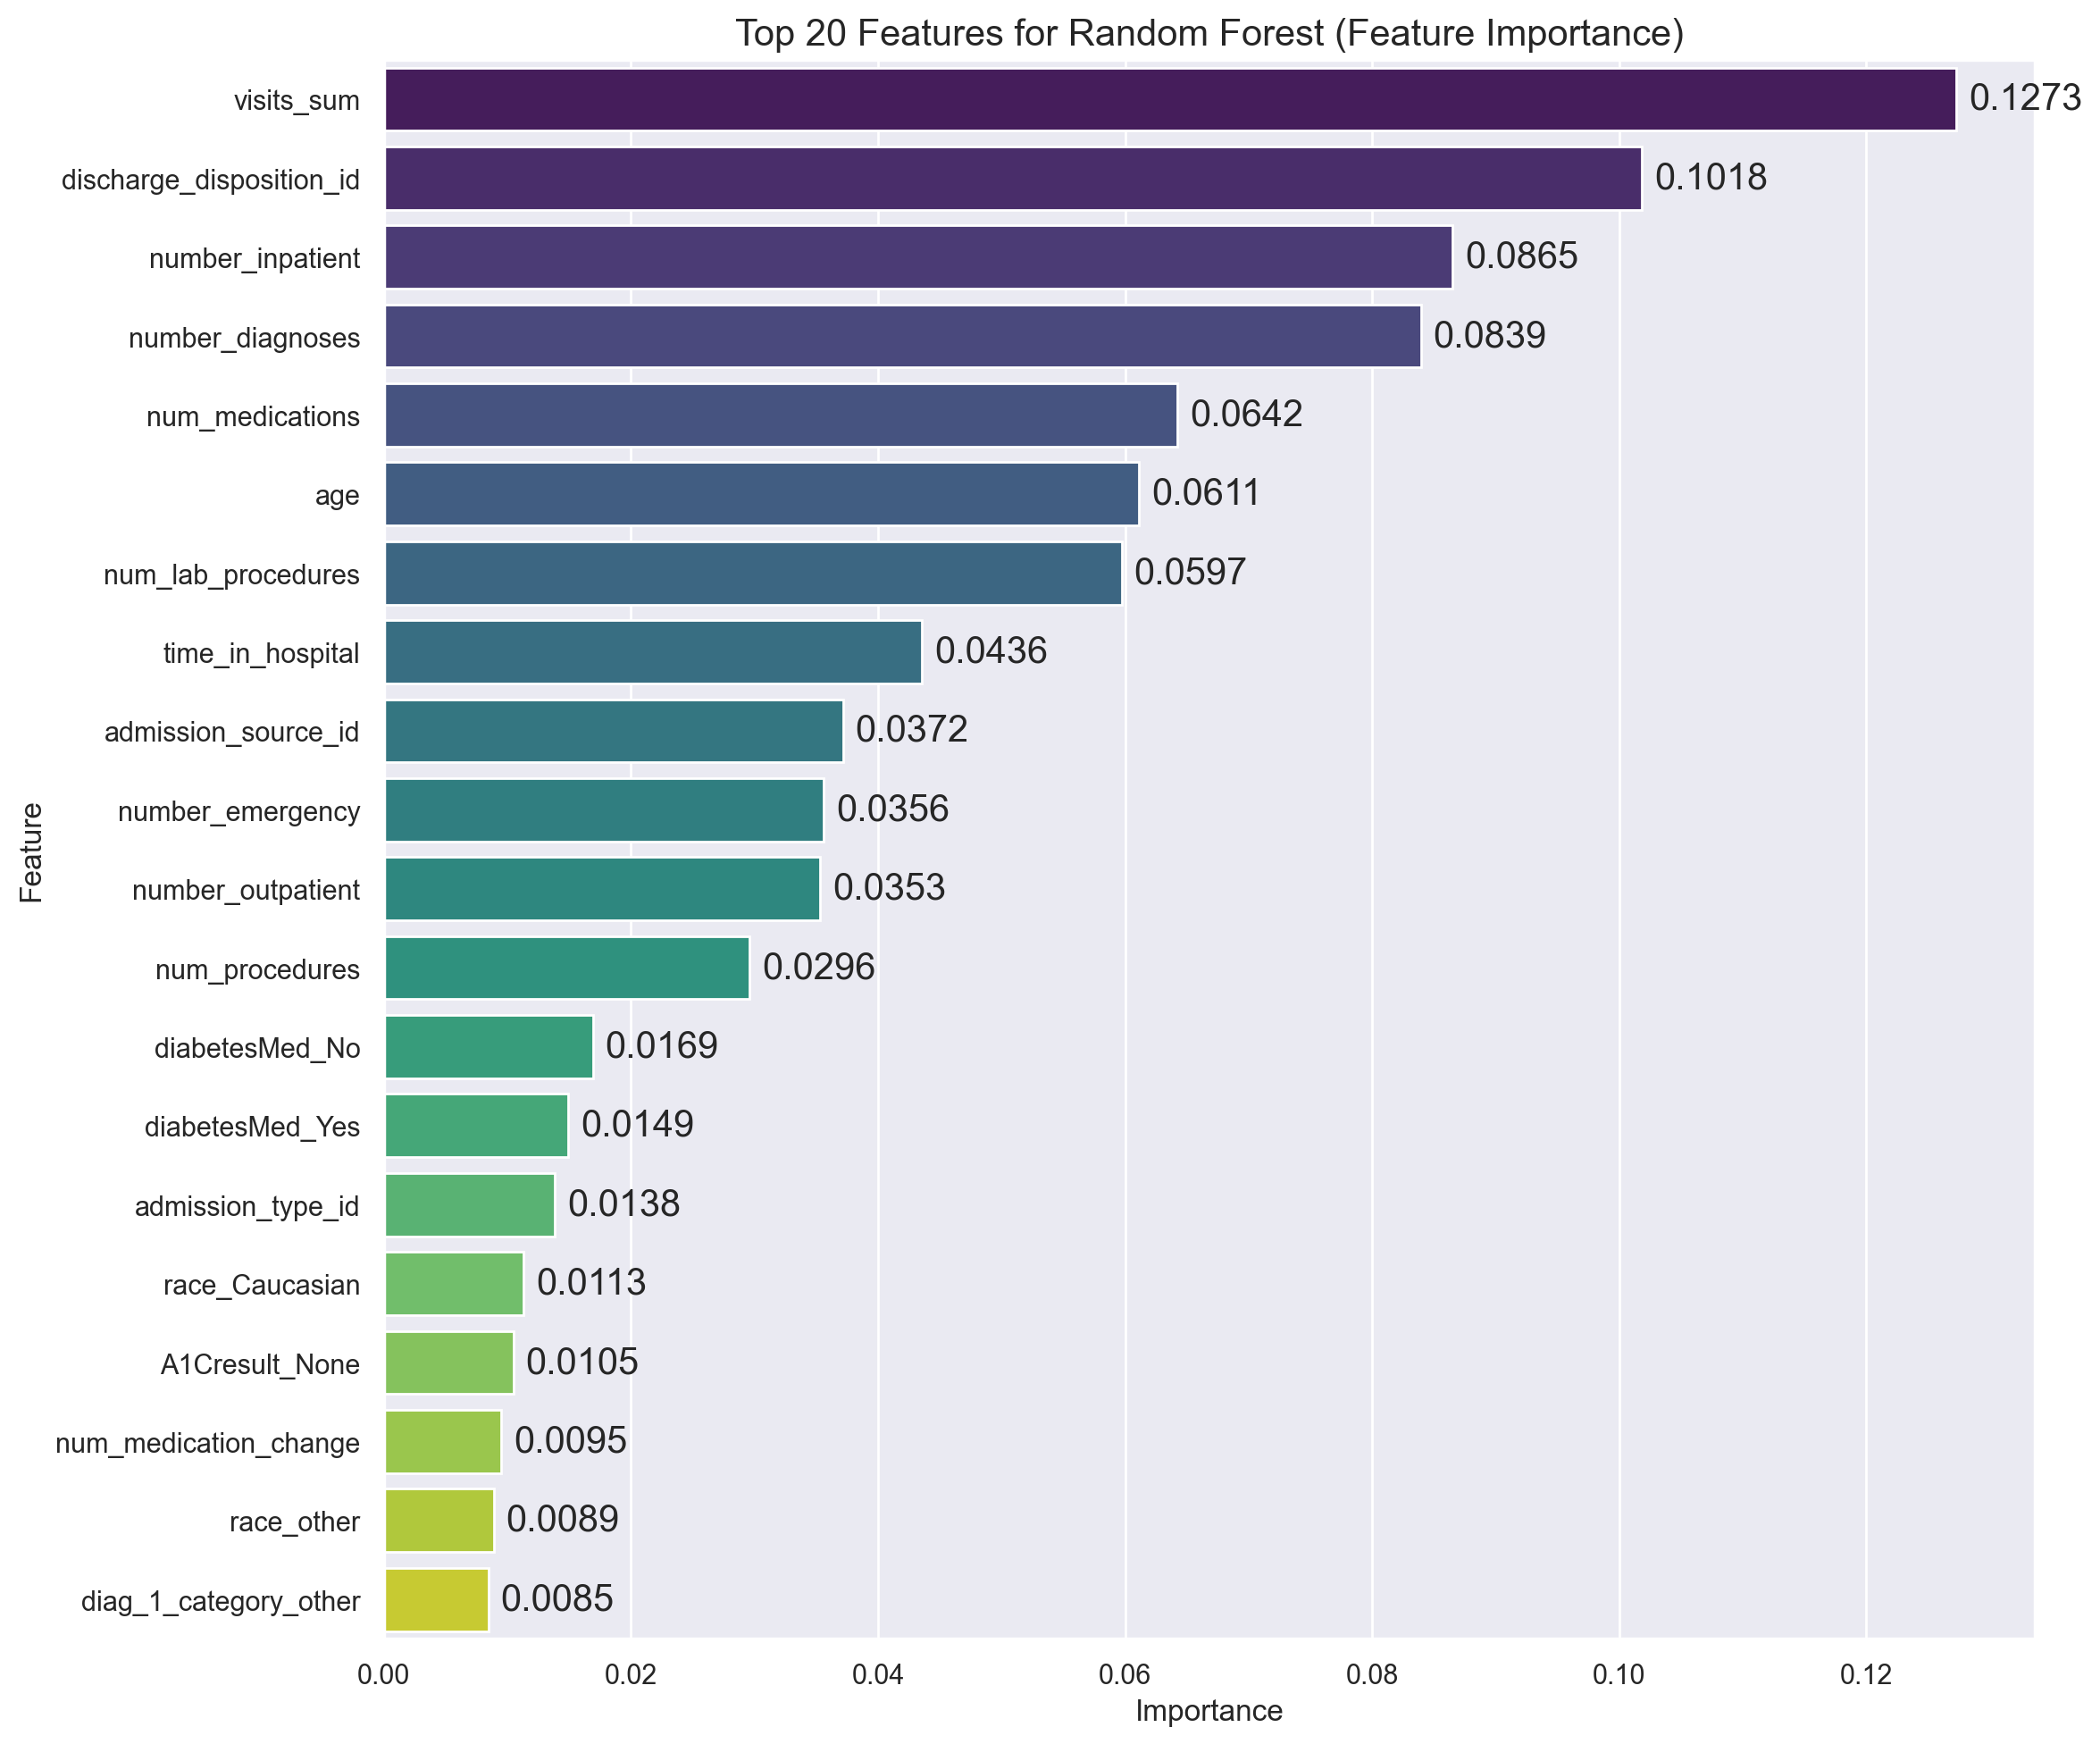

C:\Users\Gugu\AppData\Local\Temp\ipykernel_114612\498281950.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


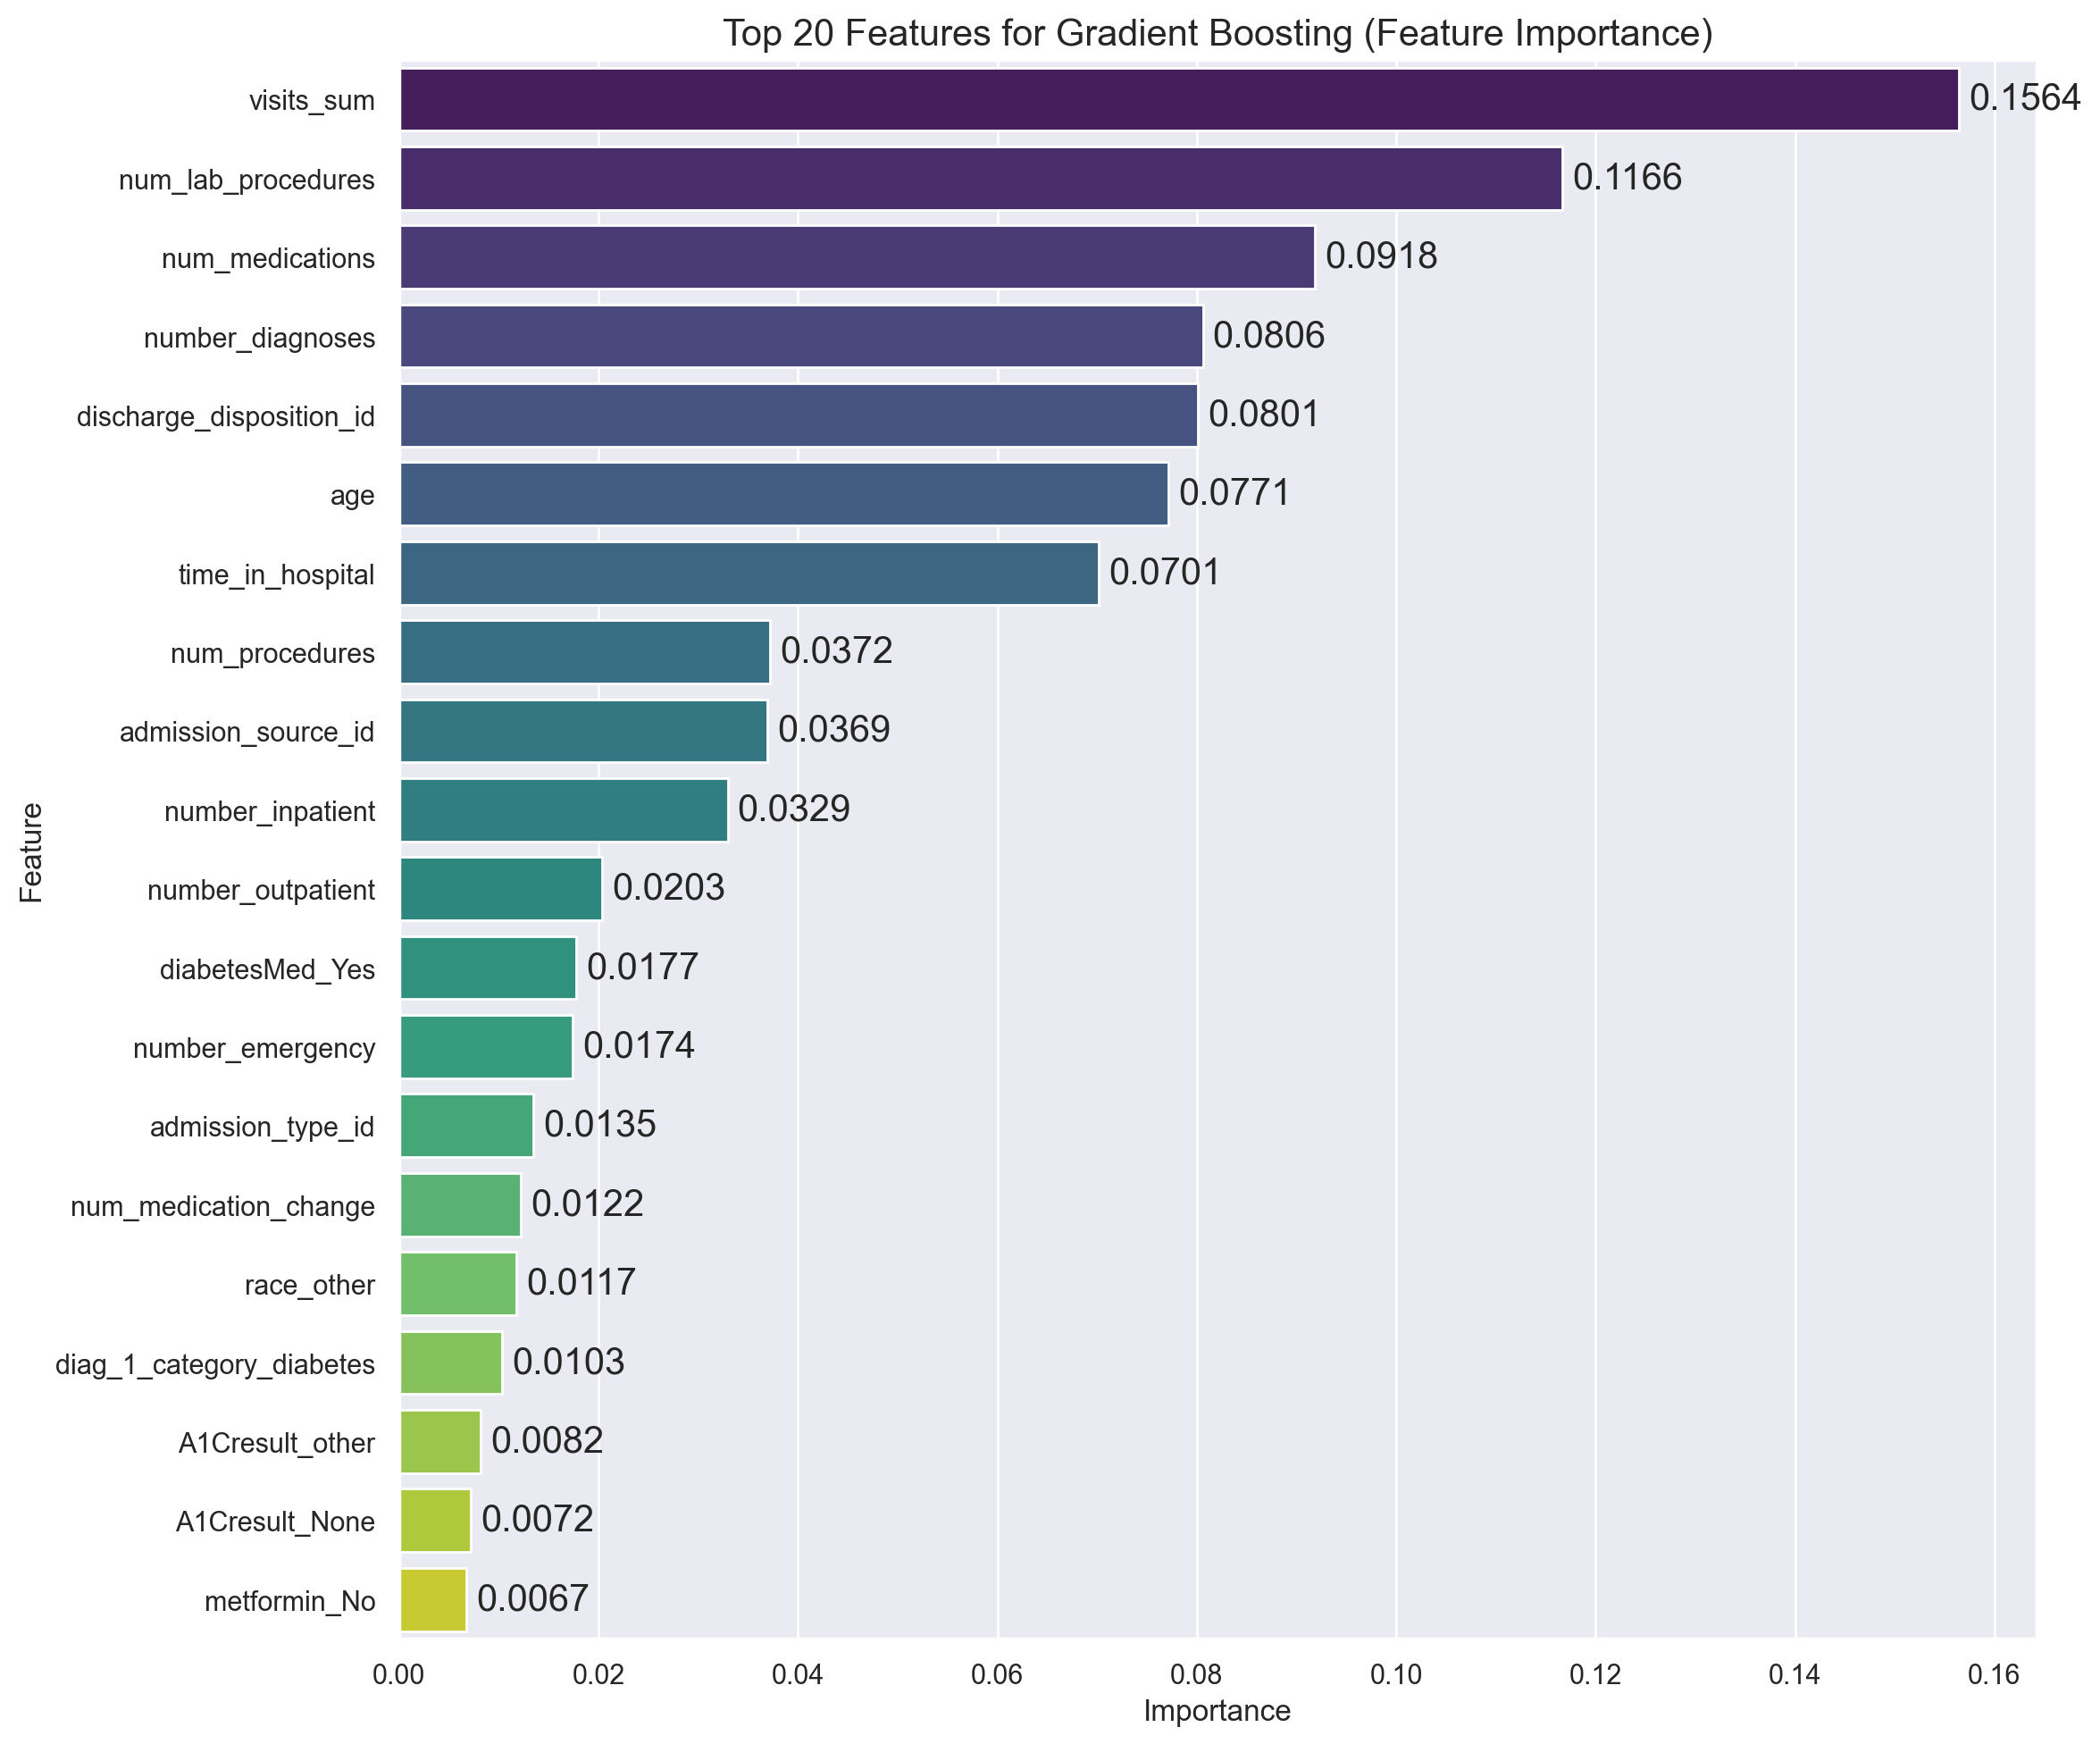

C:\Users\Gugu\AppData\Local\Temp\ipykernel_114612\498281950.py:175: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features,
C:\Users\Gugu\AppData\Local\Temp\ipykernel_114612\498281950.py:175: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features,
C:\Users\Gugu\AppData\Local\Temp\ipykernel_114612\498281950.py:175: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features,


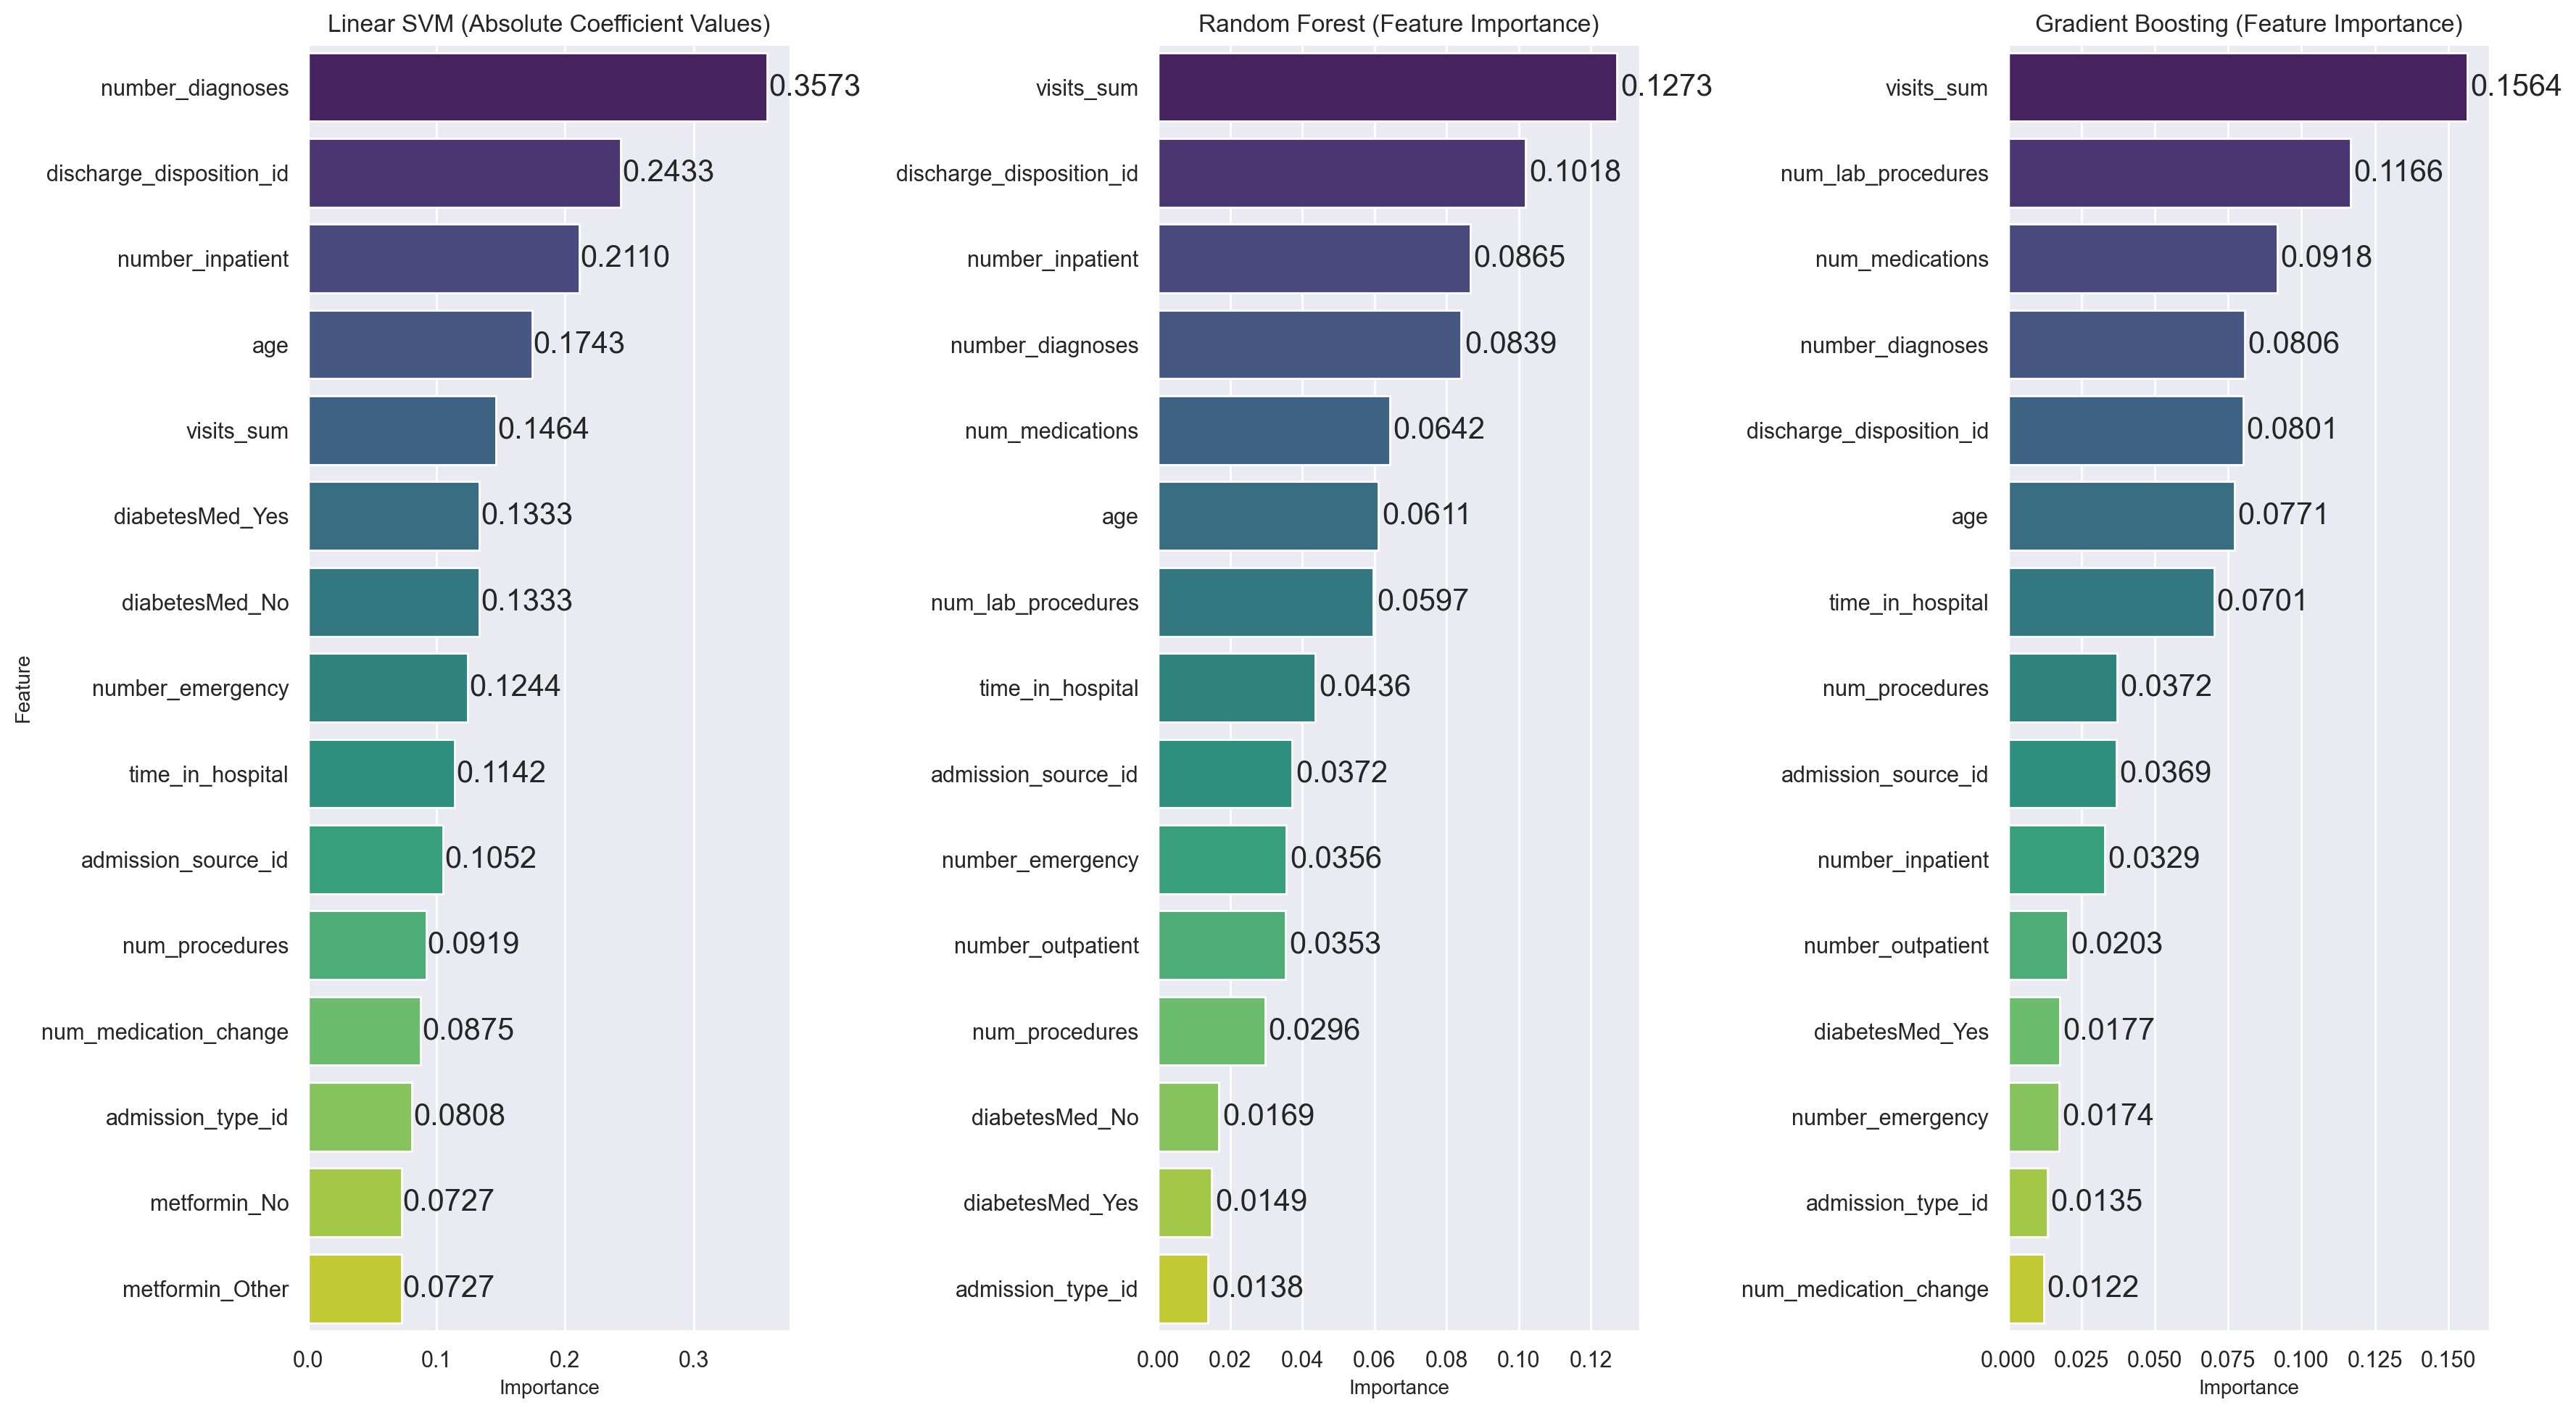

In [47]:
def plot_feature_importance(model, model_name, feature_names, top_n=20, figsize=(12, 10)):
    """
    Plot feature importance for a given model using seaborn."""
    plt.figure(figsize=figsize)
    
    # Extract feature importance based on model type
    if model_name == 'Linear SVM':
        # For Linear SVM, use coefficients as feature importance
        if hasattr(model.named_steps['classifier'], 'coef_'):
            importance = model.named_steps['classifier'].coef_[0]
        else:
            print("Model doesn't have coefficients to plot.")
            return
            
    elif model_name == 'Random Forest' or model_name == 'Gradient Boosting':
        # For tree-based models, use feature_importances_
        if hasattr(model.named_steps['classifier'], 'feature_importances_'):
            importance = model.named_steps['classifier'].feature_importances_
        else:
            print("Model doesn't have feature_importances_ attribute.")
            return
    else:
        print(f"Feature importance visualization not supported for {model_name}")
        return
    
    # If the number of features doesn't match the importance array length,
    # it could be due to preprocessing (e.g., OneHotEncoder creating new features)
    if len(feature_names) != len(importance):
        print(f"Warning: Number of feature names ({len(feature_names)}) doesn't match "
              f"importance array length ({len(importance)}).")
        
        # Create generic feature names
        feature_names = [f"Feature {i}" for i in range(len(importance))]
    
    # Create DataFrame with feature names and importance
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })
    
    # Take absolute values for SVM coefficients (direction matters, but magnitude is what we're plotting)
    if model_name == 'Linear SVM':
        feature_importance['Importance'] = np.abs(feature_importance['Importance'])
        title_suffix = "(Absolute Coefficient Values)"
    else:
        title_suffix = "(Feature Importance)"
    
    # Sort by importance and get top features
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    top_features = feature_importance.head(top_n)
    
    # Create the plot
    ax = sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
    
    # Add value labels to the bars
    for i, v in enumerate(top_features['Importance']):
        ax.text(v + 0.001, i, f"{v:.4f}", va='center')
    
    # Set plot title and labels
    plt.title(f"Top {top_n} Features for {model_name} {title_suffix}", fontsize=15)
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # If it's an SVM, also show features with negative coefficients
    if model_name == 'Linear SVM':
        # Get original coefficients (with sign)
        original_coef = model.named_steps['classifier'].coef_[0]
        
        # Create DataFrame with feature names and coefficients
        feature_coef = pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': original_coef
        })
        
        # Sort by coefficient value
        feature_coef = feature_coef.sort_values('Coefficient')
        
        # Plot top positive and negative coefficients
        plt.figure(figsize=figsize)
        
        # Get top negative and positive coefficients
        top_negative = feature_coef.head(top_n // 2)
        top_positive = feature_coef.tail(top_n // 2)
        
        # Combine them
        top_coef = pd.concat([top_negative, top_positive])
        
        # Create a diverging color palette based on coefficient sign
        colors = ['red' if c < 0 else 'green' for c in top_coef['Coefficient']]
        
        # Create the plot
        ax = sns.barplot(x='Coefficient', y='Feature', data=top_coef, palette=colors)
        
        # Add value labels to the bars
        for i, v in enumerate(top_coef['Coefficient']):
            # Adjust text position based on coefficient sign
            if v < 0:
                ax.text(v - 0.002, i, f"{v:.4f}", va='center', ha='right')
            else:
                ax.text(v + 0.002, i, f"{v:.4f}", va='center')
        
        # Add a vertical line at x=0
        plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        
        # Set plot title and labels
        plt.title(f"{model_name}: Top Positive and Negative Coefficients", fontsize=15)
        plt.xlabel('Coefficient Value', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.tight_layout()
        plt.show()

def plot_all_models_feature_importance(best_models, feature_names, top_n=15):
    """Plot feature importance for all models in a single figure."""
    # Determine number of models
    n_models = len(best_models)
    
    if n_models == 0:
        print("No models to plot")
        return
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 10))
    
    # If only one model, convert axes to array for consistent indexing
    if n_models == 1:
        axes = np.array([axes])
    
    # Process each model
    for i, (model_name, model) in enumerate(best_models.items()):
        # Extract feature importance based on model type
        if model_name == 'Linear SVM':
            # For Linear SVM, use coefficients as feature importance
            if hasattr(model.named_steps['classifier'], 'coef_'):
                importance = np.abs(model.named_steps['classifier'].coef_[0])
                title_suffix = "(Absolute Coefficient Values)"
            else:
                print(f"Model {model_name} doesn't have coefficients to plot.")
                continue
                
        elif model_name == 'Random Forest' or model_name == 'Gradient Boosting':
            # For tree-based models, use feature_importances_
            if hasattr(model.named_steps['classifier'], 'feature_importances_'):
                importance = model.named_steps['classifier'].feature_importances_
                title_suffix = "(Feature Importance)"
            else:
                print(f"Model {model_name} doesn't have feature_importances_ attribute.")
                continue
        else:
            print(f"Feature importance visualization not supported for {model_name}")
            continue
        
        # Handle feature name mismatch
        if len(feature_names) != len(importance):
            print(f"Warning: Number of feature names ({len(feature_names)}) doesn't match "
                  f"importance array length ({len(importance)}) for {model_name}.")
            
            # Create generic feature names
            model_feature_names = [f"Feature {j}" for j in range(len(importance))]
        else:
            model_feature_names = feature_names
        
        # Create DataFrame with feature names and importance
        feature_importance = pd.DataFrame({
            'Feature': model_feature_names,
            'Importance': importance
        })
        
        # Sort by importance and get top features
        feature_importance = feature_importance.sort_values('Importance', ascending=False)
        top_features = feature_importance.head(top_n)
        
        # Create the plot for this model
        sns.barplot(x='Importance', y='Feature', data=top_features, 
                   ax=axes[i], palette='viridis')
        
        # Add value labels to the bars
        for j, v in enumerate(top_features['Importance']):
            axes[i].text(v + 0.001, j, f"{v:.4f}", va='center')
        
        # Set subplot title and labels
        axes[i].set_title(f"{model_name} {title_suffix}", fontsize=12)
        axes[i].set_xlabel('Importance', fontsize=10)
        
        # Only show y-label on the leftmost subplot
        if i == 0:
            axes[i].set_ylabel('Feature', fontsize=10)
        else:
            axes[i].set_ylabel('')
    
    plt.tight_layout()
    plt.show()
    
# Get feature names from original dataset
feature_names = X.columns.tolist()

# Plot individual feature importance for each model
for model_name, model in best_models.items():
    plot_feature_importance(model, model_name, feature_names, top_n=20)

# Plot feature importance for all models in a single figure for comparison
plot_all_models_feature_importance(best_models, feature_names, top_n=15)    

## 5. Alternative ML Pipeline

In [22]:
best_models

{'Linear SVM': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['age', 'admission_type_id',
                                                    'discharge_disposition_id',
                                                    'admission_source_id',
                                                    'time_in_hospital',
                                                    'num_lab_procedures',
                                                    'num_procedures',
                                                    'num_medications',
                       

In [23]:
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.model_selection import cross_val_score

def create_feature_selection_pipeline(best_model, X, y, selection_method='selectfrommodel', 
                                      n_features_to_select=None, cv=5, random_state=42):
    """Create and evaluate a pipeline with feature selection using the best model."""
    # Extract the preprocessor and classifier from the best model
    preprocessor = best_model.named_steps['preprocessor']
    classifier = best_model.named_steps['classifier']
    
    # Create a temporary pipeline with just the preprocessor
    prep_pipeline = Pipeline([('preprocessor', preprocessor)])
    
    # Fit the preprocessor on the data to transform it
    X_transformed = prep_pipeline.fit_transform(X)
    
    # Create feature selection step based on the method
    if selection_method.lower() == 'selectfrommodel':
        # Use classifier's feature importance for selection
        selector = SelectFromModel(
            estimator=classifier,
            threshold='mean',  # Use mean feature importance as threshold
            prefit=False
        )
    elif selection_method.lower() == 'rfe':
        # Use Recursive Feature Elimination
        if n_features_to_select is None:
            n_features_to_select = X_transformed.shape[1] // 2  # Default to half
        
        selector = RFE(
            estimator=classifier,
            n_features_to_select=n_features_to_select,
            step=1,
            verbose=1
        )
    else:
        raise ValueError(f"Unknown selection method: {selection_method}")
    
    # Create new pipeline with feature selection
    pipeline_with_selection = Pipeline([
        ('preprocessor', preprocessor),
        ('feature_selection', selector),
        ('classifier', classifier)
    ])
    
    # Evaluate pipeline with cross-validation
    cv_scores = cross_val_score(
        pipeline_with_selection, 
        X, y, 
        cv=cv, 
        scoring='f1_macro',
        n_jobs=-1
    )
    
    # Fit the pipeline on all data to get selected features
    pipeline_with_selection.fit(X, y)
    
    # Get indices of selected features
    if selection_method.lower() == 'selectfrommodel':
        selected_indices = pipeline_with_selection.named_steps['feature_selection'].get_support(indices=True)
    else:  # RFE
        selected_indices = pipeline_with_selection.named_steps['feature_selection'].get_support(indices=True)
    
    return pipeline_with_selection, selected_indices, cv_scores

def evaluate_with_selected_features(best_model, X, y, selected_indices, cv=5, test_size=0.2, random_state=42):
    """Evaluate model performance using only selected features."""
    # Extract the preprocessor and classifier from the best model
    preprocessor = best_model.named_steps['preprocessor']
    classifier = best_model.named_steps['classifier']
    
    # Create a new pipeline with only selected features
    pipeline_selected = Pipeline([
        ('preprocessor', preprocessor),
        # ('selector', ColumnSelector(selected_indices)),
        ('classifier', classifier)
    ])
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Train model
    pipeline_selected.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = pipeline_selected.predict(X_test)
    if model_name == 'Linear SVM':
        y_proba_test = pipeline_selected.decision_function(X_test)
    else:
        y_proba_test = pipeline_selected.predict_proba(X_test)[:, 1]
    test_metrics = calculate_best_model_metrics(y_test, y_pred, y_proba_test)
    
    return test_metrics

# Determine the best model based on F1 macro score
best_model_name = None
best_f1_score = 0

for model_name, results in test_results.items():
    f1 = results['Macro F1']  # Assuming this is stored in your test_results
    if f1 > best_f1_score:
        best_f1_score = f1
        best_model_name = model_name

print(f"Best model: {best_model_name} with F1 score: {best_f1_score:.4f}")

# Get the best model
best_model = best_models[best_model_name]

# Run feature selection with SelectFromModel
print("\nRunning feature selection with SelectFromModel...")
pipeline_with_sfm, selected_indices_sfm, cv_scores_sfm = create_feature_selection_pipeline(
    best_model, X, y, selection_method='selectfrommodel', cv=5
)

print(f"Cross-validation F1 scores: {cv_scores_sfm}")
print(f"Mean CV score: {cv_scores_sfm.mean():.4f} ± {cv_scores_sfm.std():.4f}")
print(f"Number of selected features: {len(selected_indices_sfm)} out of {X.shape[1]}")

# Run feature selection with RFE (optional)
print("\nRunning feature selection with RFE...")
pipeline_with_rfe, selected_indices_rfe, cv_scores_rfe = create_feature_selection_pipeline(
    best_model, X, y, selection_method='rfe', n_features_to_select=20, cv=5
)

print(f"Cross-validation F1 scores: {cv_scores_rfe}")
print(f"Mean CV score: {cv_scores_rfe.mean():.4f} ± {cv_scores_rfe.std():.4f}")
print(f"Number of selected features: {len(selected_indices_rfe)} out of {X.shape[1]}")

# Get feature names for selected features
feature_names = X.columns
selected_features_sfm = feature_names[selected_indices_sfm]
selected_features_rfe = feature_names[selected_indices_rfe] if 'selected_indices_rfe' in locals() else []

print("\nSelected features (SelectFromModel):")
for i, feature in enumerate(selected_features_sfm):
    print(f"{i+1}. {feature}")

if len(selected_features_rfe) > 0:
    print("\nSelected features (RFE):")
    for i, feature in enumerate(selected_features_rfe):
        print(f"{i+1}. {feature}")

# Evaluate performance with selected features
print("\nEvaluating performance with selected features...")
test_metrics_sfm = evaluate_with_selected_features(
    best_model, X, y, selected_indices_sfm, cv=5
)

print("\nTest metrics with selected features (SelectFromModel):")
for metric, value in test_metrics_sfm.items():
    if isinstance(value, np.ndarray):
        continue  # Skip arrays like confusion matrix
    print(f"{metric}: {value:.4f}")

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': [f'Original {best_model_name}', f'{best_model_name} with Feature Selection'],
    'F1 Macro (CV)': [best_f1_score, cv_scores_sfm.mean()],
    'F1 Macro Std (CV)': [0.0, cv_scores_sfm.std()],  # Assuming you have this from original results
    'Number of Features': [X.shape[1], len(selected_indices_sfm)]
})

print("\nComparison Table:")
print(comparison_df)

# Visualize selected features
plt.figure(figsize=(12, 8))
plt.bar(selected_features_sfm, [1] * len(selected_features_sfm), color='darkblue')
plt.xticks(rotation=90)
plt.title(f'Selected Features for {best_model_name}')
plt.tight_layout()
plt.show()

Best model: Random Forest with F1 score: 0.5988

Running feature selection with SelectFromModel...
Cross-validation F1 scores: [0.61849191 0.62361105 0.56340325 0.559578   0.54053392]
Mean CV score: 0.5811 ± 0.0335
Number of selected features: 12 out of 51

Running feature selection with RFE...


KeyboardInterrupt: 